<br><br><br>
<a id="inicio"></a>
<div align="left">
<h1><font color="#5E5E5E"><b>Proyecto DIRA: Diabetes Intelligent Risk Assessment</b></font></h1>
<h2><font size=4><b>HITO 2 - Análisis de Datos y Formulación del problema</b></font></h2>
<br><br><br><br>
</div>
 
 
<div align="right">
<font color="#B51700" size=4><b>Desarrollo e Integración de Servicios de IA </b></font><br><br>
<font color="#5E5E5E" size=3>Máster Universitario en Inteligencia Artificial</font><br><br>
<font color="#5E5E5E"size=3><b>&copy; Julio Alberto López &nbsp;&nbsp; </b></font><span style="background-color:#B51700; color:white; padding:2px 6px; font-family:Arial, sans-serif;font-weight:bold;font-size:18px;">UCLM</span>
</div>
 
---
#### Grupo:
* Nombre:  `Ángel Ortega Alfaro`
* Nombre:  `Mª Inmaculada Gracia Mendoza`
* Nombre:  `Santiago Maroto Galán`
* Nombre:  `Judith Liliana Jaeger Collantes`
---
 

# Índice:

* [0. Importación Librerías](#configuración)
* [1. Carga de datos inicial](#cargaDatos)
* [2. Inspección estructural del dataset](#inspeccion)
* [3. Análisis exploratorio de los datos](#EDA)
* [4. Preprocesamiento](#preprocesamiento)
* [5. Conclusión final](#conclusion)



<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id = "configuración" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: #00b31bff; font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
           0. Configuración
        </h3>
    </div>
</div>
Este apartado está destinado a la inclusión de las configuraciones de nuestro notebook


<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id = "importacion" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: rgb(18, 223, 127); font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
           Importación librerías
        </h3>
    </div>
</div>

In [66]:
import warnings
import math
import time

import pandas as pd
import numpy as np

# Para crear y guardar el pipeline final
import joblib

# Librerías para gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# Librería para matriz de asociación/correlación
from dython.nominal import associations

# Librería Scikit-learn
from sklearn import set_config, config_context
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
# Para utilizar toda la potencia de RandomSearchCV en la búsqueda de los mejores parámetros
from scipy.stats import randint, uniform, loguniform

# Modelos Boosting
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import xgboost as xgb

# Librería para tratamiento de clases desbalanceadas
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.ensemble import BalancedRandomForestClassifier

import shap
from tqdm import tqdm


<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: rgb(18, 223, 127); font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
           Fijar Semilla
        </h3>
    </div>
</div>

In [6]:
random_state = 42

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: rgb(18, 223, 127); font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
           Fijar salida de transformadores
        </h3>
    </div>
</div>
Vamos a indicarle a `scikit-learn` que la salida de sus transformadores sea un `DataFrame` de `pandas` siempre que sea posible, en lugar de un `array` de `NumPy` (que es el comportamiento por defecto). Hacemos esto ahora porque, aunque no afecta al modelo final, hace que el **proceso de definir y depurar los pasos de preprocesamiento sea mucho más cómodo**. Nos permitirá inspeccionar la salida de nuestros `Pipeline` en cualquier etapa y ver un `DataFrame` con nombres de columna legibles, facilitando la verificación de que nuestra lógica es correcta, en lugar de tener que descifrar un `array` numérico anónimo.

In [7]:
transform_output = "pandas"  # Pandas output
set_config(transform_output=transform_output)

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: rgb(18, 223, 127); font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
           Configuración visualización pandas y evitar salida de mensajes de warnings
        </h3>
    </div>
</div>

In [8]:
action = "ignore"  # Never print matching warnings
warnings.filterwarnings(action)
# Mostrar todas las columnas
pd.set_option('display.max_columns', None)
# Ajustar el ancho de las celdas para que no se corte el texto
pd.set_option('display.max_colwidth', None)
# Mostrar todas las filas
pd.set_option('display.max_rows', None)
# Evita el salto de línea (wrapping) para que todo salga en una fila horizontal
pd.set_option('display.expand_frame_repr', False)

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id ="cargaDatos" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: #00b31bff; font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
           1. Carga de datos
        </h3>
    </div>
    <div>
        Se utilizará el dataset público <strong> Diabetes Health Indicators Dataset </strong> que contiene tres csv, del cual elegiremos el archivo <strong>diabetes_binary_health_indicators_BRFSS2015.csv</strong>, cuya variable objetivo es <strong>Diabetes_binary</strong>. El dataset contiene indicadores de salud recopilados en la encuesta BRFSS 2015, con el objetivo de estudiar factores asociados a la diabetes- SU variable objetivo, es una variable binaria que indica si el encuestado ha sido diagnosticado o no con diabétes.
    </div>
    <div>
        Cargamos el conjunto de datos para evaluarlo y comenzar el análisis y preprocesamiento del mismo.
    </div>
</div>


In [9]:
df = pd.read_csv("data/diabetes_binary_health_indicators_BRFSS2015.csv")
print("Dimensiones:", df.shape)
df.head(10)


Dimensiones: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,1.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


Como podemos ver el dataset está formado por 253.680 filas y 22 columnas, siendo la columna `Diabetes_binary` la variable objetivo de nuestro problema.

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id = "inspeccion" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: #00b31bff; font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
            2. Inspección estructural del dataset
        </h3>
    </div>
    <div>
        Comenzamos inspeccionando la información y la descripción del dataset.
    </div>
</div>

In [10]:

print ("Información:")
print(df.info())

print ("Descripcion:\n")
df.describe().T


Información:
<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


Con la información anterior, podemos observar que no hay variables con valores perdidos explícitos, que todas las variables están tipificadaas como "float64" cuando sabemos por el análisis premiliminar realizado del dataset que muchas de ellas son categóricas binarias (0, 1).  
tenemos los siguientes tipos de variables
- `Variables binarias (0/1)`: Diabetes_binary, HighBP, HighChol, CholCheck, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, DiffWalk, Sex.
- `Variables ordinales`: GenHlth (1–5), Age (1–13), Education (1–6), Income (1–8), MentHlth (0-30), PhysHlth(0-30)
- `Variables continuas`: BMI

La variable objetivo `Diabetes_binary` presenta una media aproximada de 0.139, lo que nos indica que al ser una variable binaria, que solo un 14% de los encuestados tiene un diagnóstico de diabetes o pre-diabetes(Clase 1), es decir, que es una dataset con una distribución muy desbalanceada (86% clase 0 y 14% clase 1), lo que implicará el uso de técnicas de balanceo de clases durante el modelado. También deberemos tener en cuenta que el accuracy no será por si mismo un valor fiable, porque el modelo puede decir que nadie tiene diabetes y acertará el 86% de la veces, habrá que revisar otras métricas como F1-score, Precision o Recall.

`SESGO DE REPRESENTACIÓN`<br>
**Education**: El 50% de la muestra tiene un nivel 5 o superior, y el 75% llega al máximo (6). La mayoría de los datos del dataset son de personas con estudios universitarios o avanzados.
**Income**: El 50% de la muestra tiene un nivel 7 o superior (en una escala de 8), lo que nos indica que la mayoría del dataset son personas con ingresos muy altos.

Impacto: El modelo apenas tiene ejemplos de personas en situaciones de vulnerabilidad socioeconómica, por lo que no puede aprender cómo interactúan la pobreza y la diabetes.

`FACTOR METABÓLICO`<br>
`HighBP` y `HighChol` son factores metabólicos que representan presión arterial y colesterol alto. Ambas variables presentan medias prácticamente iguales, aproximadamente de 0.43, lo que nos indica que más del 40% de la población tiene hipertensión o colesterol alto. En al ámbito clínico la hipertensión, el colesterol alto y la prediabetes/diabetes son parte de los factores que forman el Síndrome Metabólico (https://www.revespcardiol.org/es-obesidad-sindrome-metabolico-y-diabetes-articulo-13123996). 
 
`Stroke` y `HeartDiseaseorAttack` tienen medias muy bajas bajas (4% y 9%) y desviaciones estandar muy bajas también, lo que indica que son datos desbalanceados con poca presencia de casos positivos, es posible que pacientes con estas variables a 1, también tengan diabetes.
Más adelante revisaremos las correlaciones de las mismas, para ver si existe una fuerte correlación entre ellas, ya que por cultura sanitaria, podemos inferir que cuando una persoan tiene colesterol alto puede provocar problemas cardiácos y cuando tiene hipertensión, puede provocar un derrame cerebral

`OMNIPRESENCIA DE CHEQUEOS y SEGUROS MÉDICOS`<br>
**CholCheck**: La media es 0.962, indicándonos que el 96% de los encuestados se ha revisado el colesterol en los últimos 5 años.
**AnyHealthcare**: La media es 0.951, indicándonos que el 95% de la muestra tiene seguro.
Estas variables no "varían". Son casi constantes. Mantenerlas implica ruido para el modelo que no puede obtener información de las mismas para realizar predicciones.

`VARIANZA EN BMI`<br>
**BMI**: La media es 28.38 (Sobrepeso), pero el máximo es 98, con una desviación estándar de 6.6. Esto significa que el BMI es de las pocas variables que realmente tiene "movimiento" y variabilidad real en este dataset. UN IMC de 98 es un valor muy extremo que representará con toda seguridad uan persona con obesidad mórbida de grado severo, y a nivel estadistico es un outlier que podría afectar a algoritmos que sean sensibles a las distancias como KNN o Máquinas Vector Soporte, dominando el modelo


En resumen, podemos decir que tenemos tres tipos de variables:

* **Variables Binarias (0 a 1)**: La inmensa mayoría (HighBP, Smoker, Stroke, Fruits, etc.). Son respuestas directas de Sí/No.
* **Variables Ordinales/Categóricas**: Tienen rangos cerrados. Por ejemplo, GenHlth (1 a 5), Age (1 a 13), Education (1 a 6) e Income (1 a 8), MentHlth (días de mala salud mental, de 0 a 30) y PhysHlth (días de mala salud física, de 0 a 30) .
* **Variables Continuas**: BMI (Índice de Masa Corporal)

En la etapa de preprocesamiento deberemos tomar decisiones con respecto a estos datos, sobre todo en lo referente a las variables que pueden no apartar información y si ruido al modelo.


<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: rgb(18, 223, 127); font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
            2.1. División estratégica: conjuntos de entrenamiento y prueba
        </h3>
    </div>
    <div>
</div>

Antes de transformar o analizar en profundidad cualquier dato, debemos realizar el paso metodológico más importante: **separar nuestro conjunto de datos en entrenamiento y prueba**.

##### **¿Por qué ahora?**

Para garantizar una evaluación honesta y robusta de nuestro modelo.

* El conjunto de **entrenamiento** (`X_train`, `y_train`) será utilizado para *todo*: análisis exploratorio, imputación de valores faltantes, detección de valores extremos, escalado y, por supuesto, el entrenamiento del modelo.
* El conjunto de **prueba** (`X_test`, `y_test`) se mantendrá "guardado bajo llave" y completamente intacto. No se mirará ni se usará para tomar ninguna decisión de preprocesamiento.

De esta forma, simulamos un escenario real donde el modelo se enfrenta a datos que nunca ha visto, previniendo el ***data leakage*** (fuga de datos). Si calculáramos, por ejemplo, la media para escalar usando el conjunto de datos completo, el conjunto de prueba ya habría "contaminado" nuestro preprocesamiento.

Usaremos una división estratificada (`stratify = y`) para asegurar que la proporción de `"0"` y `"1"` sea la misma tanto en el conjunto de entrenamiento como en el de prueba, lo cual es vital en problemas de clasificación (especialmente en datasets que están desbalanceados).


In [11]:
# Dividimos el dataset en train y test con una proporción de 80/20
y = df['Diabetes_binary']
axis = "columns"  # Elimina etiquetas por columnas
X = df.drop('Diabetes_binary', axis=axis)
test_size = 0.2 
stratify = y  # Etiquetas de clase para la estrificación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=stratify)

print("--- Proporción de Diabetes en el dataset original ---")
print(y.value_counts(normalize=True))

print("\n--- Proporción de Diabetes en el conjunto de Entrenamiento (Train) ---")
print(y_train.value_counts(normalize=True))

print("\n--- Proporción de Diabetes en el conjunto de Prueba (Test) ---")
print(y_test.value_counts(normalize=True))

--- Proporción de Diabetes en el dataset original ---
Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64

--- Proporción de Diabetes en el conjunto de Entrenamiento (Train) ---
Diabetes_binary
0.0    0.860666
1.0    0.139334
Name: proportion, dtype: float64

--- Proporción de Diabetes en el conjunto de Prueba (Test) ---
Diabetes_binary
0.0    0.860671
1.0    0.139329
Name: proportion, dtype: float64


Las proporciones de la clase objetivo son practicamente idénticas en ambos conjuntos que es lo que se pretendía.

**A partir de este punto, guardamos `X_test` y `y_test` y nos olvidamos de ellos hasta la evaluación final.**

Todo el análisis y preprocesamiento se realizará **únicamente** sobre los conjuntos de entrenamiento `X_train` e `y_train`.

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id = "EDA" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: #00b31bff; font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
            3. Analisis Exploratorio de los Datos
        </h3>
    </div>
    <div>
        En este apartado se analizarán los datos contenidos en el dataset con el objetivo de conocer la composición y distribución de los datos que van a ser la base de nuestro modelo de predicción y establecer las líneas de las tareas a realizar durante la fase de preprocesamiento.
        Conocer la variedad de los datos y su composición, nos permitirá además conocer cuáles pueden ser los algoritmos de ML que mejor se adapten a los mismos y las métricas con la que podremos validar el rendimiento de nuestro modelo.
    </div>
</div>

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id = "varObjetivo" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: rgb(18, 223, 127); font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
            3.1. Análisis de la variable objetivo
        </h3>
    </div>
    <div>
        Analizamos la distribución de la variable objetivo, para comprobar si está desbalanceada tal y como parece indicarnos los datos obtenidos en el punto anterior
    </div>
</div>

Proporciones de cada clase en la variable objetivo: Diabetes_binary
0.0    86.0666
1.0    13.9334
Name: proportion, dtype: float64


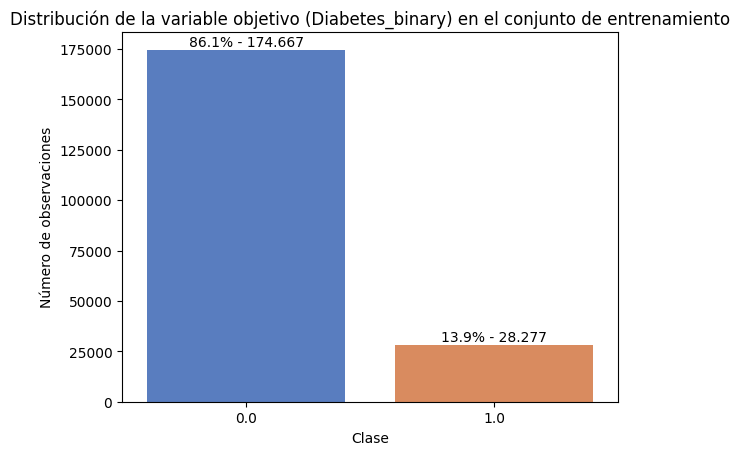

In [12]:
# Vamos a calcular y mostrar en una gráfica las proporciones de la variable objetivo "Diabetes_binay"
proporciones_abs = y_train.value_counts()
proporciones_pct = y_train.value_counts(normalize=True) * 100
print(f"Proporciones de cada clase en la variable objetivo: {proporciones_pct}")

""" Dibujamos un gráfico de barras con Seaborn que muestra la frecuencia de cada categoría de la columna "Diabetes_binary" el DataFrame X_train.
sns.countplot → función de Seaborn que cuenta automáticamente cuántas veces aparece cada valor en una variable categórica y lo representa en un gráfico de barras.

x="Diabetes_binary" → indica que la variable que se quiere graficar está en el eje X (las clases 0 y 1).

data=X_train → especifica el DataFrame de donde se extraen los datos.

palette="muted" → define la paleta de colores usada para las barras (en este caso tonos suaves).

ax = ... → guarda el objeto del gráfico en la variable ax, lo que permite luego añadir anotaciones, títulos, etiquetas, etc.
"""
ax = sns.countplot(x=y_train, palette="muted")  
# Añadir etiquetas de porcentaje sobre cada barra
# ax.patches: cada barra que se ha dibujado en el objeto ax (son dos una para cada valor distinto de la variable Diabetes_binary)
# proporciones_abs.index: etiquetas de las clases de la variable Diabetes_binary [0, 1]
for p, clase in zip(ax.patches, proporciones_abs.index):
    height = p.get_height()
    porcentaje = proporciones_pct[clase]   ## obtenemos la proporción de la clase que está seleccionada en el bucle for
    cantidad = f"{int(proporciones_abs[clase]):,}".replace(",", ".")
    
    ax.annotate(f'{porcentaje:.1f}% - {cantidad}', 
                (p.get_x() + p.get_width()/2., height), 
                ha='center', va='bottom', fontsize=10, color='black') # le añadimos el % de proporcionalidad que le corresponde
plt.title("Distribución de la variable objetivo (Diabetes_binary) en el conjunto de entrenamiento")
plt.xlabel("Clase")
plt.ylabel("Número de observaciones")
plt.show()

Con la imagen anterior podemos confirmar que el conjunto de datos está claramente desbalanceado con más de 170.000 encuestados de la clase negativa frente a poco más de 28.000 encuestados de la clase positiva (86,1% vs 13,9% ). Esto puede provocar que el modelo no aprenda a predecir de forma correcta la clase minoritaria (`Diabetes_binary = 1`), lo que implicaría que no se detectarían correctamente los casos de riesgo aunque la accuracy del modelo fuera alta, ya que al predecir correctamente los casos mayoritarios de la clase negativa el modelo ya tendría una alta exactitud, por lo tanto habrá que priorizar otras métricas como F1-Score intentando maximizarla. Recordemos que:

**F1-Score** =   2* (Precision * Recall) / (Precision + Recall)

    Precision = TP/(TP+FP)
    Recall = TP/(TP+FN)
        TP = True Positives (verdaderos positivos)
        FP = False Positives (falsos positivos)
        FN = False Negatives (falsos negativos) 
        
Nuestro objetivo principal durante el análisis exploratorio de los datos es detectar problemas que afecten a la clase minoritaria y a la capacidad del modelo de equilibrar precision y recall. Cuanto mayor sean precision y recall, mayor será F1-Score.

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id = "univariante" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: rgb(18, 223, 127); font-size: 1em; margin-right: 10px;">▍</span>
        <h4 style="margin: 0; font-size: 1em; font-weight: bold">
            3.2. Análisis univariante de las variables predictoras
        </h4>
    </div>
</div>
Analizamos la distribución de las variables predictoras del dataset, con este análisis se pretente detectar:

* **Escalas**: Diferencias drásticas en los rangos.
* **Valores extremos:** Diferencias grandes entre el 75% (`Q3`) y el máximo (`max`).
* **Asimetría:** Si la media es muy diferente de la mediana (`Q2`).

In [13]:
# Diccionario para mapear las etiquetas de las variables ordinales que agrupan distintos grupos de encuestados
mapeo_etiquetas = {
    #variables ordinales
    'GenHlth': {1: '1-Excelente', 2: '2-Muy buena', 3: '3-Buena', 4: '4-Regular', 5: '5-Mala'},
    'Education': {1: 'Sin estudios', 2: 'Primaria', 3: 'Secundaria Incomp.', 
                  4: 'Secundaria Comp.', 5: 'Universidad Incomp.', 6: 'Universidad Comp.'},
    'Age': {1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44', 6: '45-49', 
            7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69', 11: '70-74', 12: '75-79', 13: '80+'},
    'Income': {1: '<$10k', 2: '<$15k', 3: '<$20k', 4: '<$25k', 
               5: '<$35k', 6: '<$50k', 7: '<$75k', 8: '>$75k'},
    # Variables binarias
    'HighBP': {0: '0 - Tensión Normal', 1: '1 - Tensión Alta'},
    'HighChol': {0: '0 - Colesterol Normal', 1: '1 - Colesterol Alto'},
    'CholCheck': {0: '0 - No revisado', 1: '1 - Revisado (últ. 5 años)'},
    'Smoker': {0: '0 - No Fumador', 1: '1 - Fumador'},
    'Stroke': {0: '0 - Sin Derrame Cerebral', 1: '1 - Con Derrame Cerebral'},
    'HeartDiseaseorAttack': {0: '0 - Sano del corazón', 1: '1 - Infarto / Enferm. Card.'},
    'PhysActivity': {0: '0 - Sedentario', 1: '1 - Activo físicamente'},
    'Fruits': {0: '0 - No consume frutas', 1: '1 - Consume frutas'},
    'Veggies': {0: '0 - No consume verduras', 1: '1 - Consume verduras'},
    'HvyAlcoholConsump': {0: '0 - Bebedor moderado/nulo', 1: '1 - Bebedor Excesivo'},
    'AnyHealthcare': {0: '0 - Sin seguro médico', 1: '1 - Con seguro médico'},
    'NoDocbcCost': {0: '0 - Pudo pagar médico', 1: '1 - No pudo por coste'},
    'DiffWalk': {0: '0 - Sin dificultad', 1: '1 - Dificultad al caminar'},
    'Sex': {0: '0 - Mujer', 1: '1 - Hombre'}, 
}

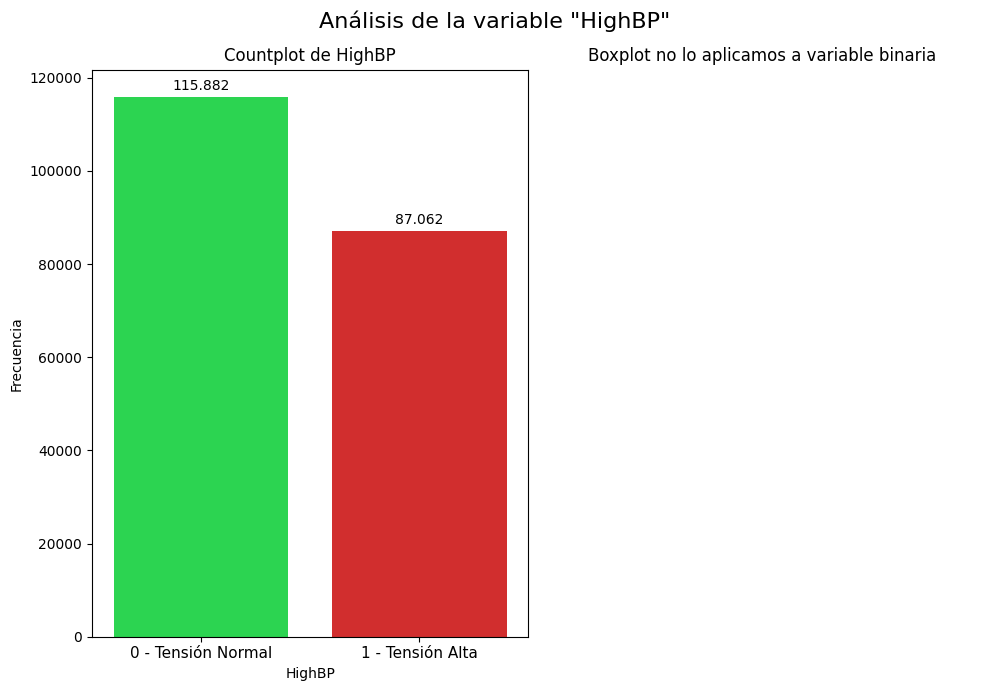

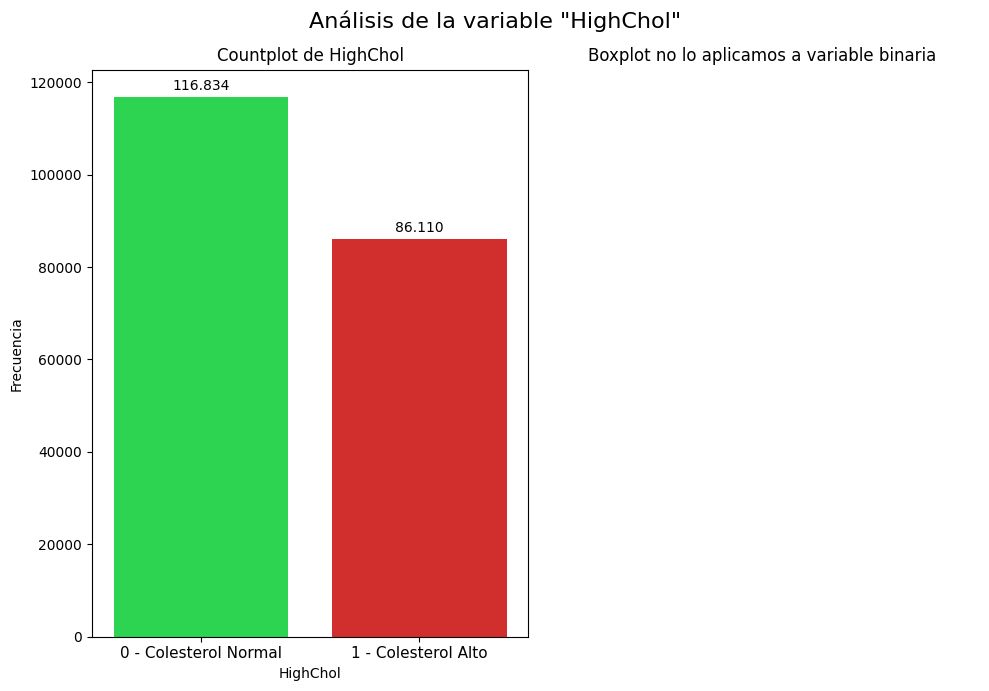

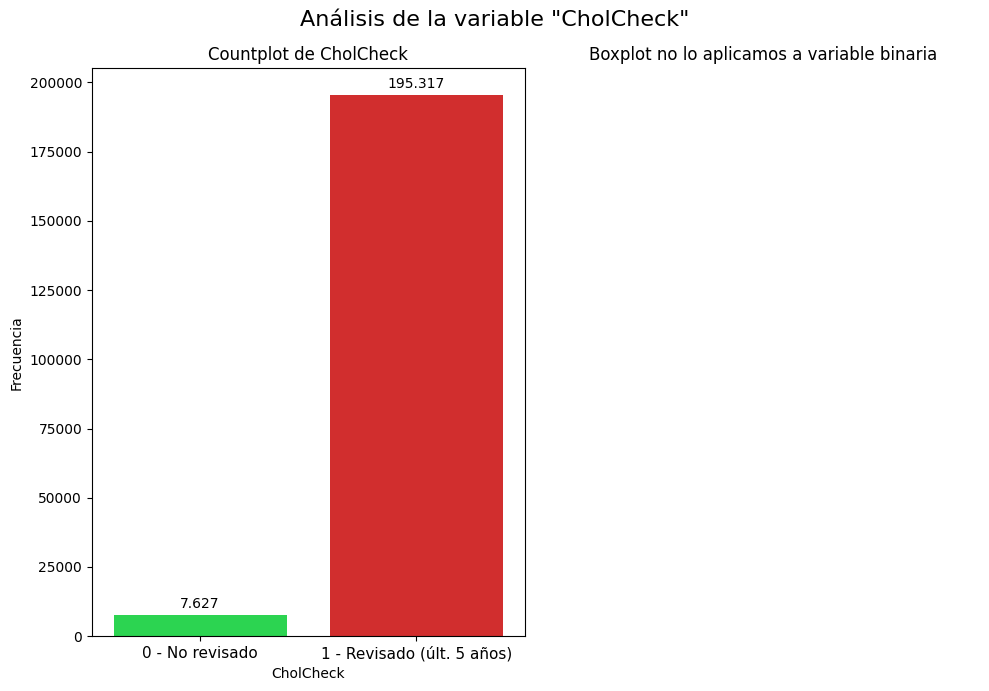

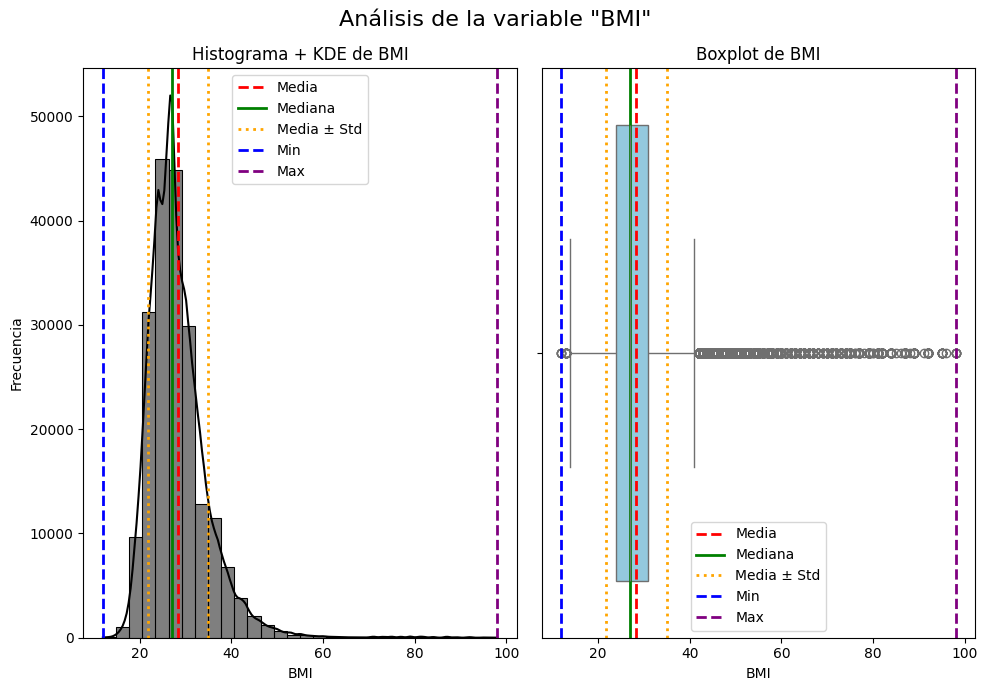

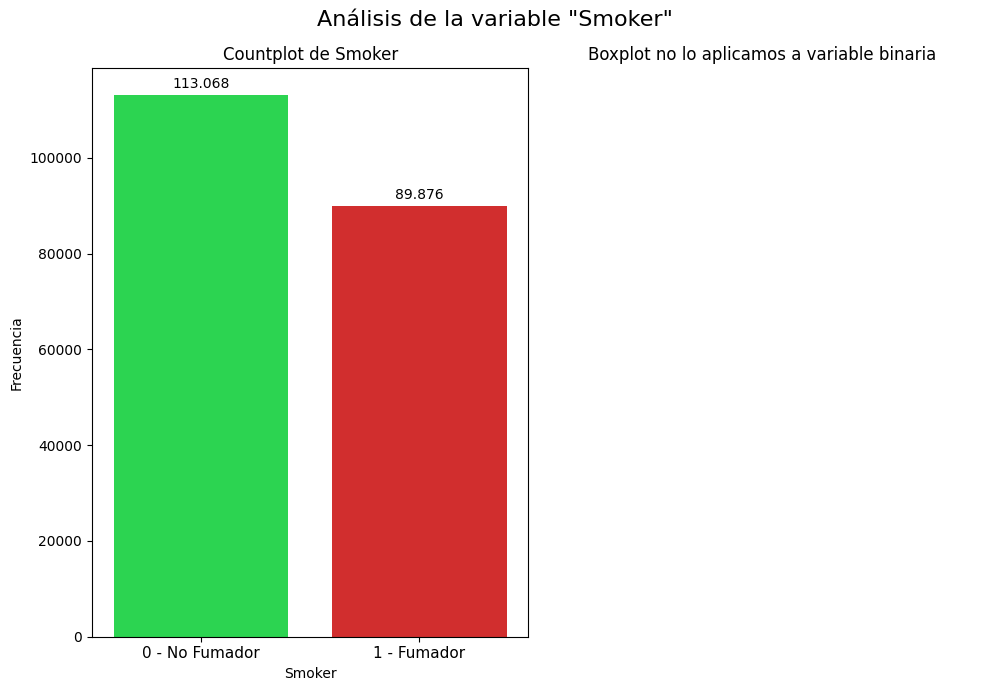

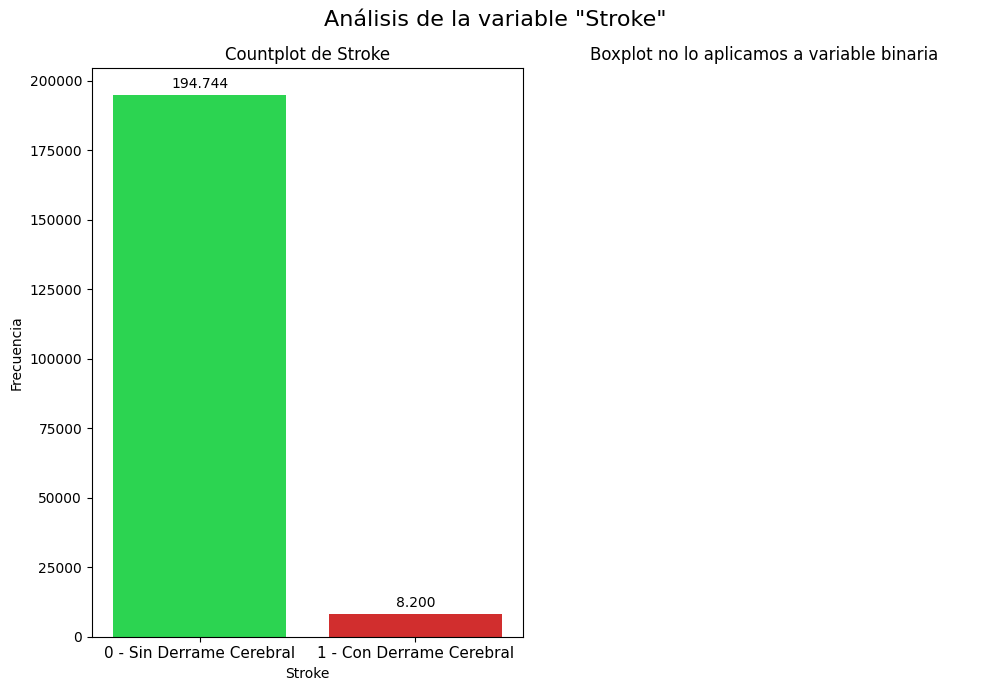

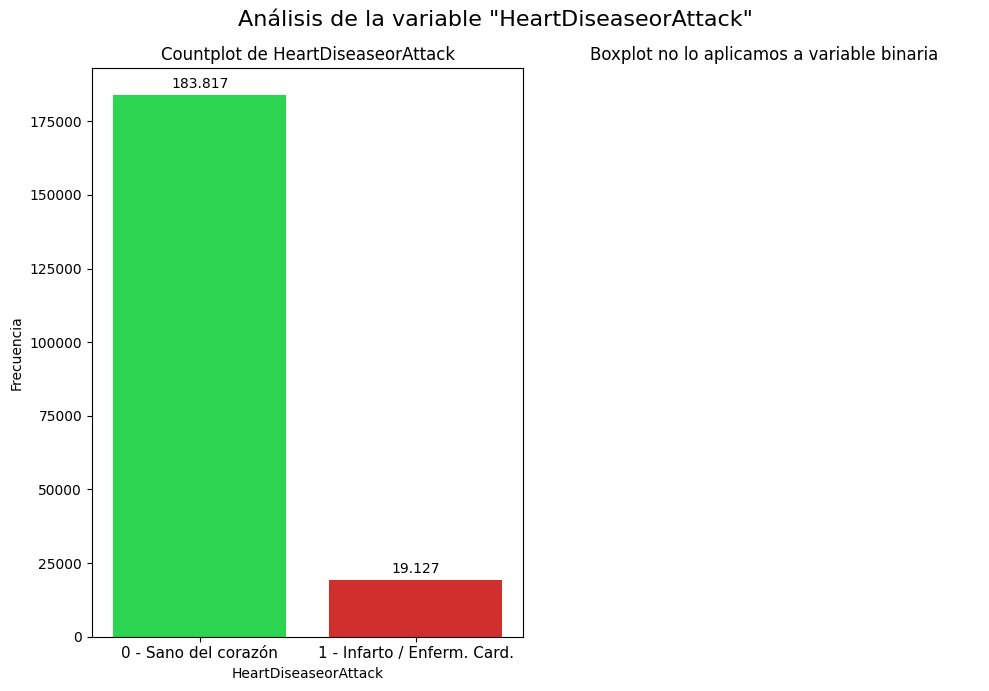

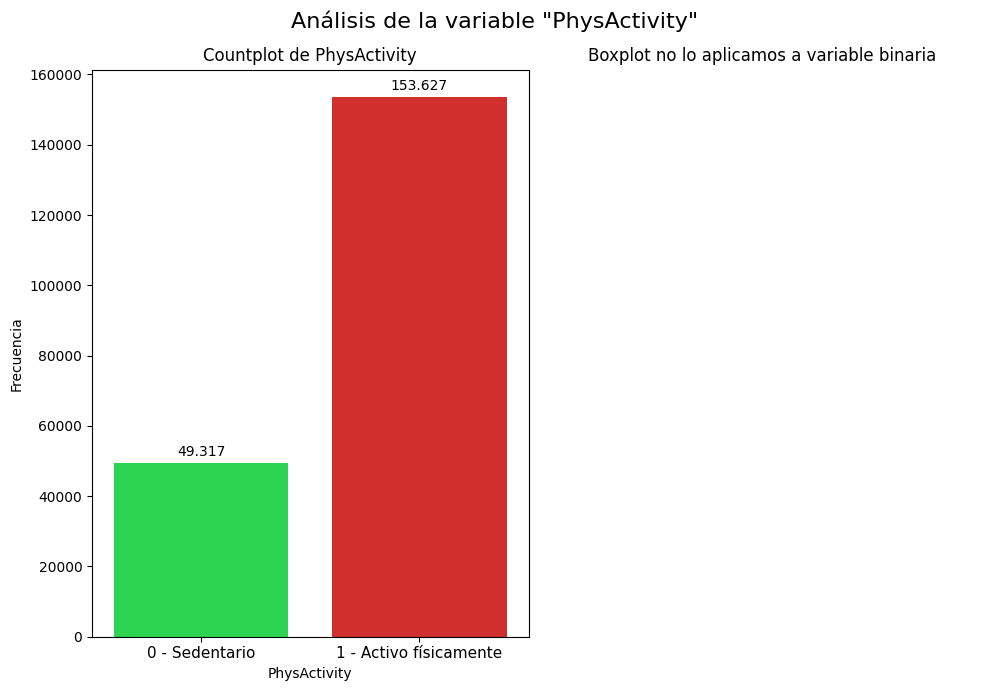

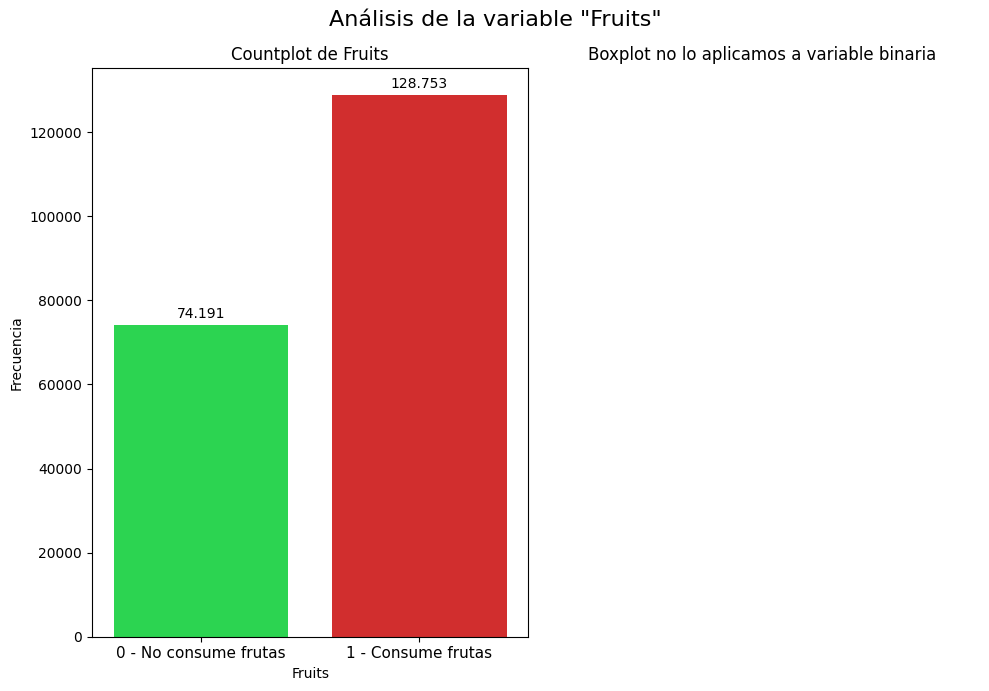

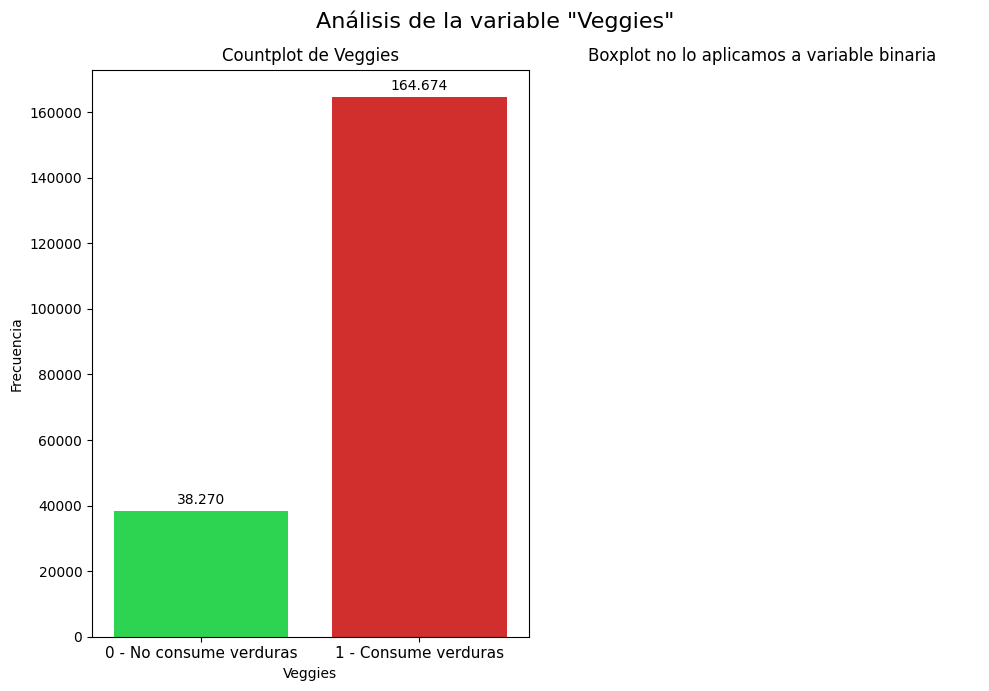

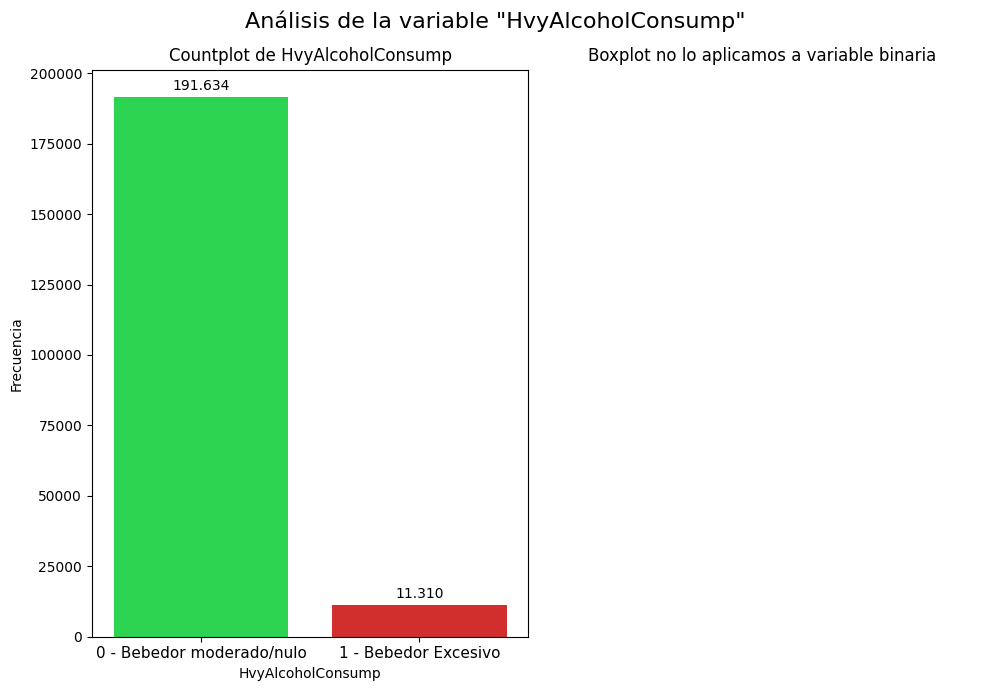

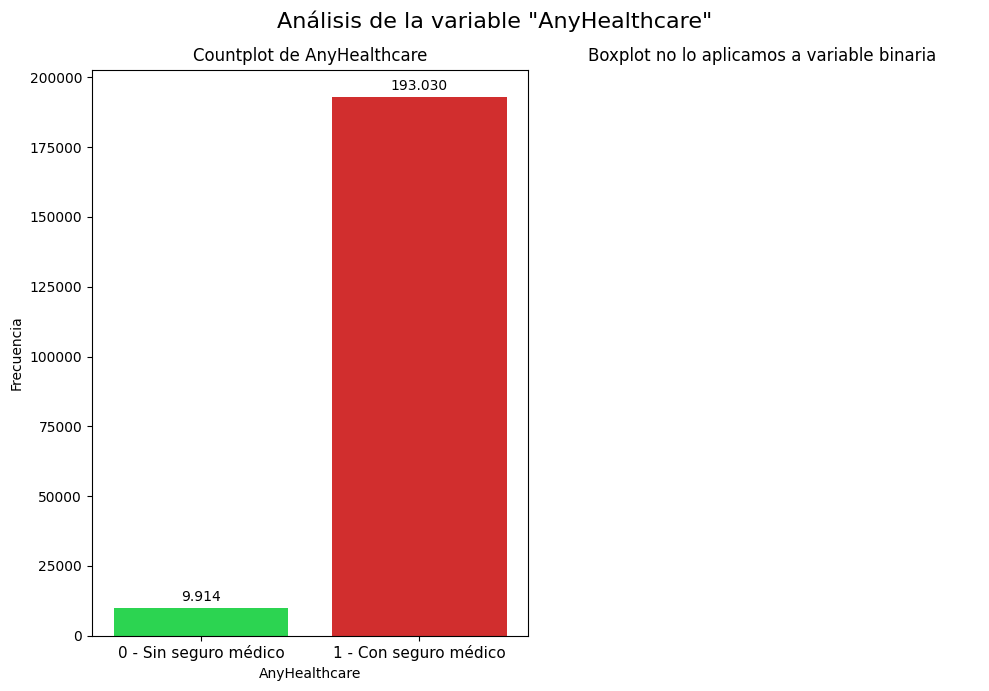

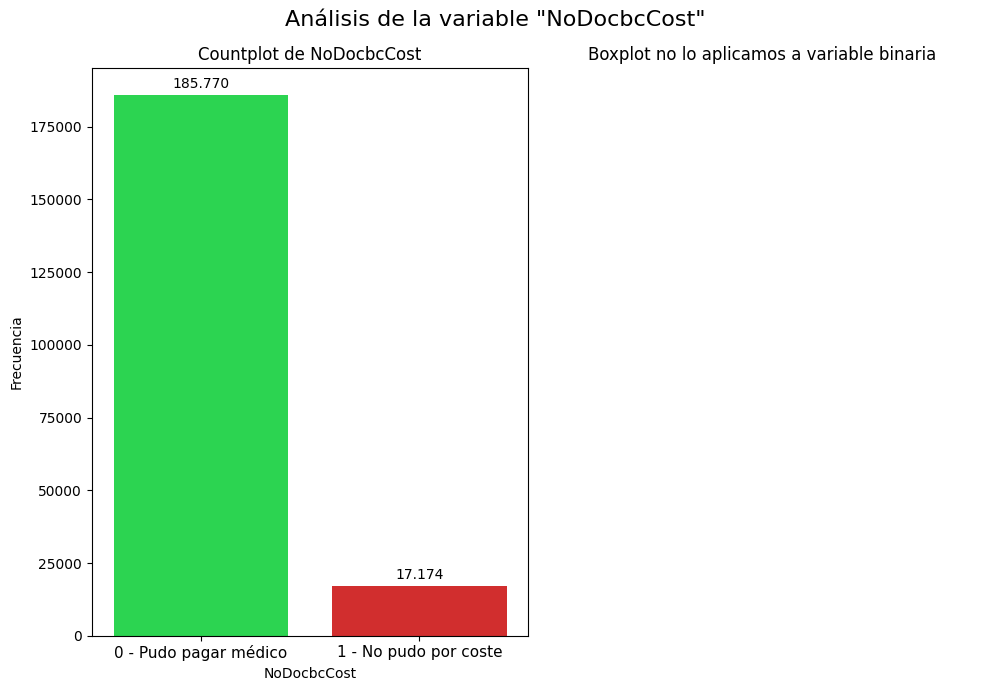

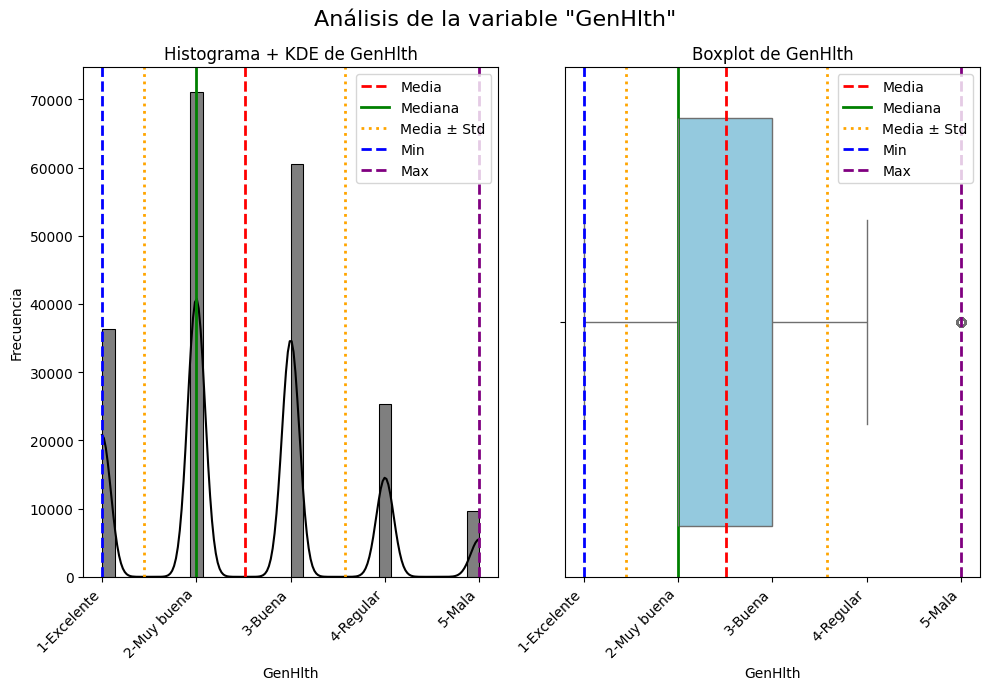

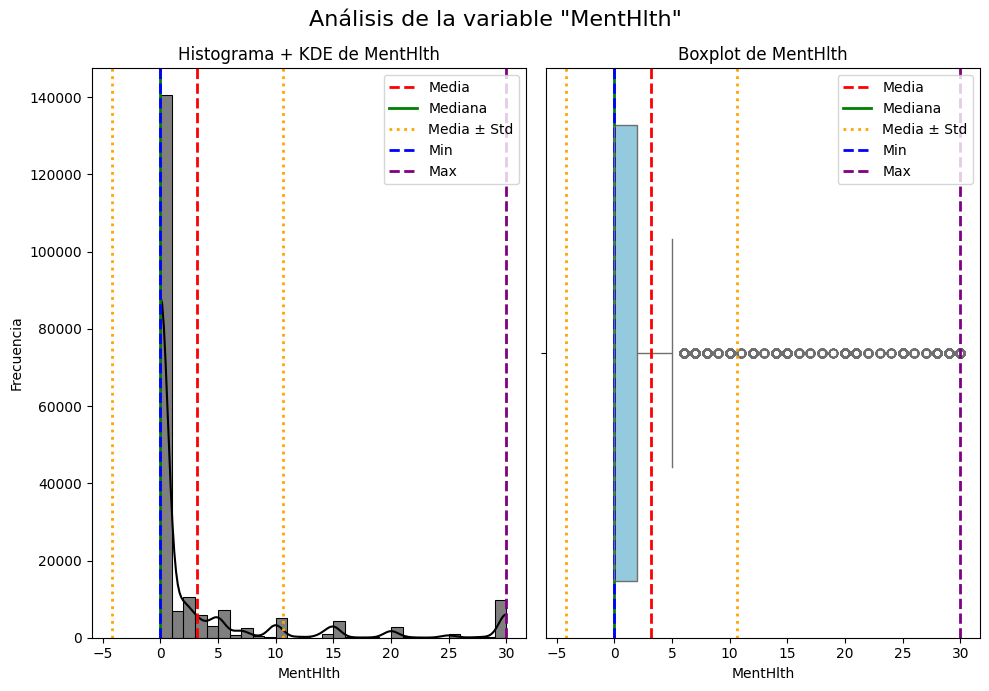

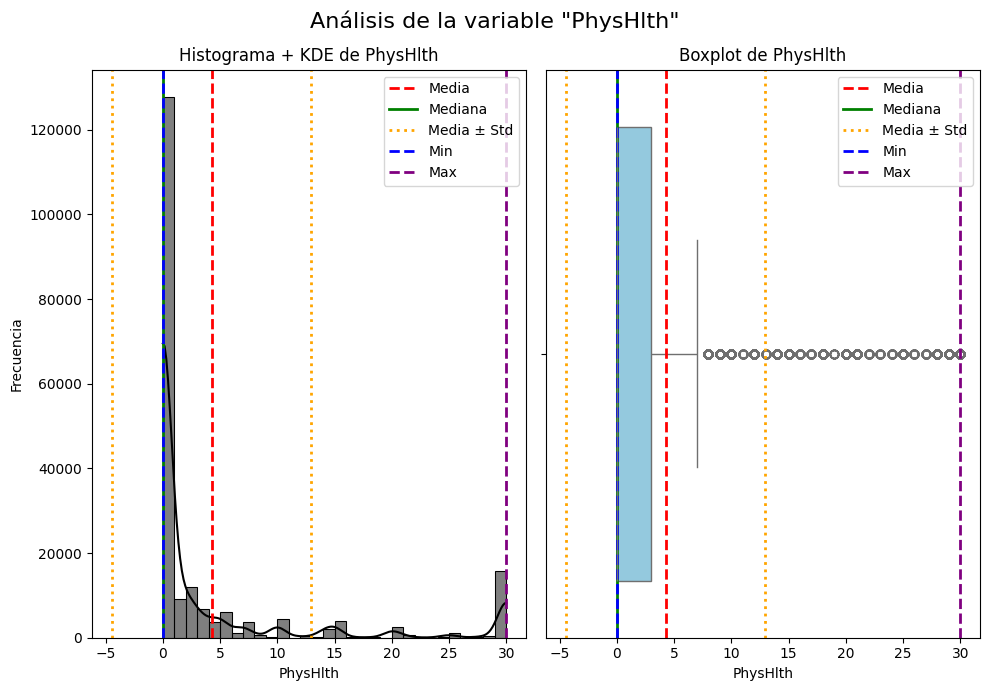

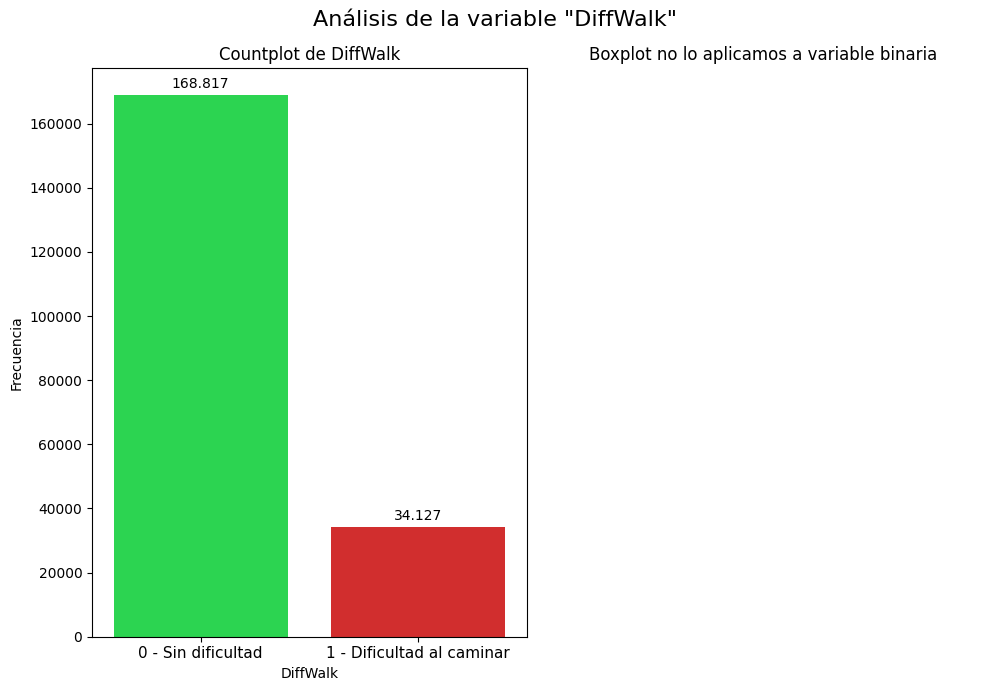

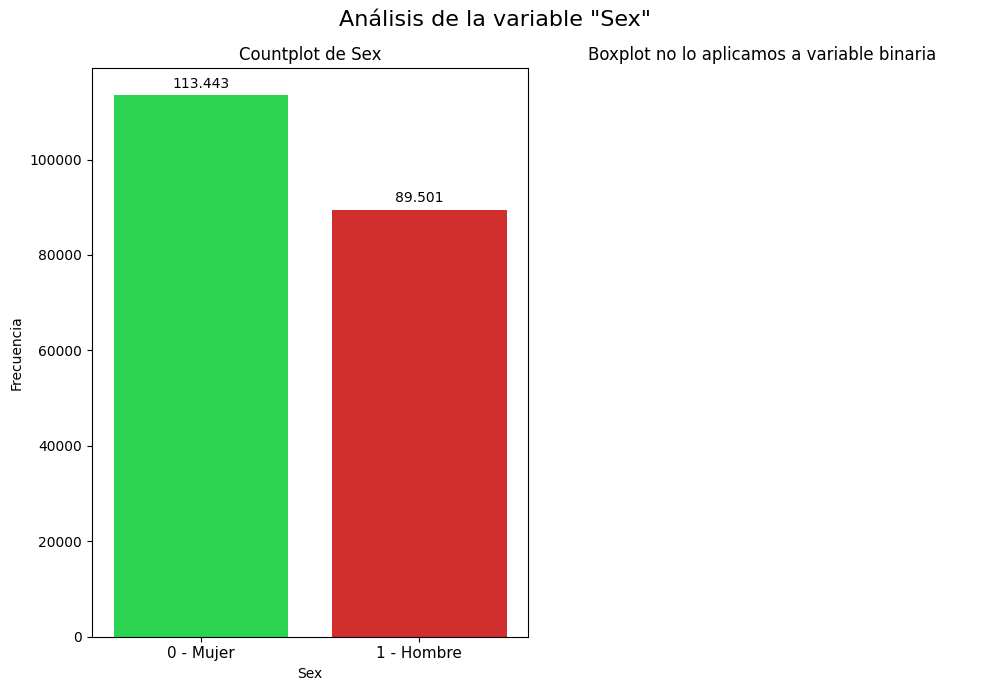

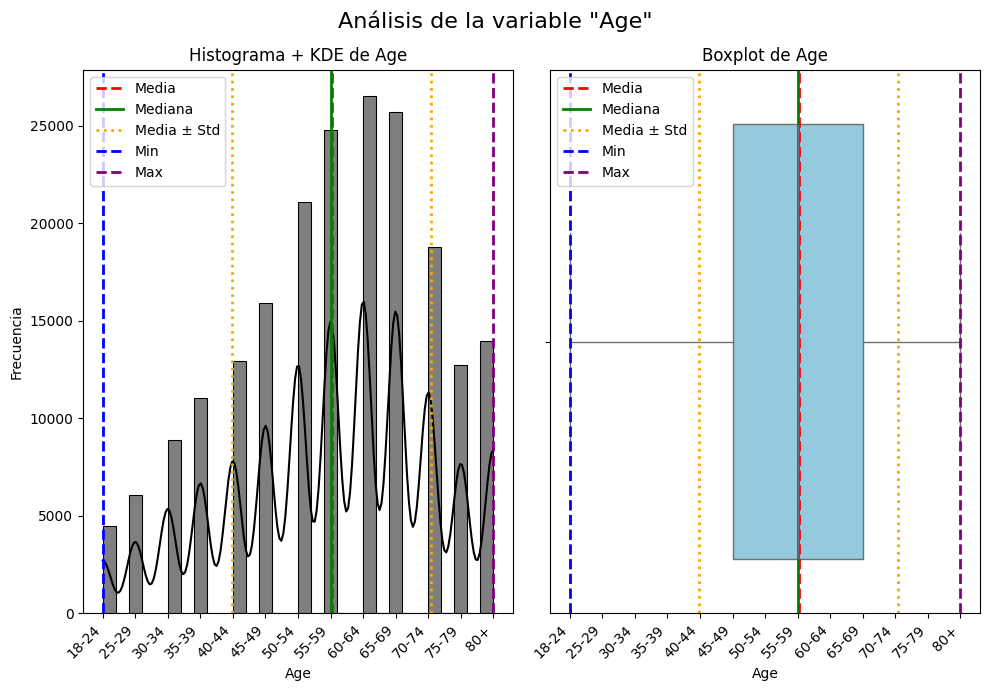

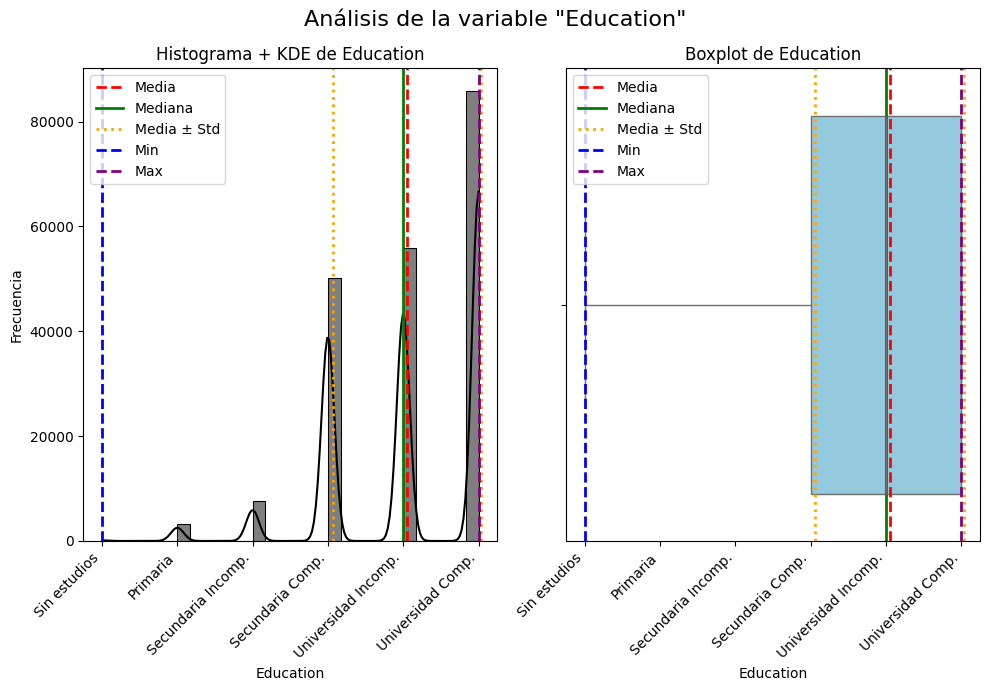

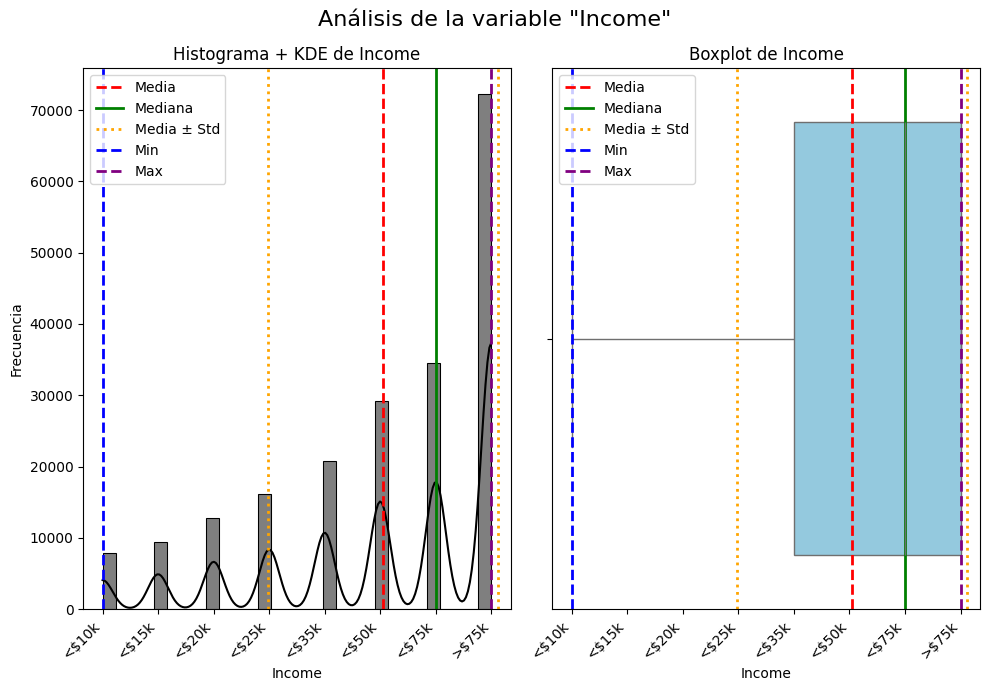

In [14]:
# Creamos una lista de las variables numéricas eliminando la variable objetivo
include = ["int", "float64"]  # tipos de datos a incluir
exclude = ['Diabetes_binary']
numerical_features = X_train.select_dtypes(include=include).columns.tolist()
numerical_features = [col for col in numerical_features if col not in exclude]
## Recorremos cada variable numérica predictora no binaria para visualizarla mediante histograma + curva KDE superpuesta para cada predictor numérico
# KDE representa una estimación suave y continua de la distribución de una variable numérica, calculando una función continua que aproxima la probabilidad
# los valors caiagan en cada zona del eje
# un diagrama KDE muestra: 
#   - La forma de la distribución (asimetría, colas largas, multimodalidad).
#   - La concentración de valores (picos donde hay más densidad).
#   - La dispersión (anchura de la curva).
# Para las variables binarias utilizaremos un CountPlot para ver la frecuencia de cada categoría

for col in numerical_features:

    es_binaria = X_train[col].nunique() == 2

    plt.figure(figsize=(10, 7))

    media = X_train[col].mean()
    mediana = X_train[col].median()
    std = X_train[col].std()
    min_val = X_train[col].min()
    max_val = X_train[col].max()

    # ---------------------------
    # SUBPLOT 1: DISTRIBUCIÓN
    # ---------------------------
    plt.subplot(1, 2, 1)

    if es_binaria:
        ax = sns.countplot(x=X_train[col], palette=["#10f041", "#ec1313"])
        for container in ax.containers:
            # Sacamos la altura (el número) de cada barra y sustituimos la "," por el "." de millares
            etiquetas = [f"{int(barra.get_height()):,}".replace(",", ".") for barra in container]
            # Le pegamos esas etiquetas formateadas al contenedor
            ax.bar_label(container, labels=etiquetas, padding=3)
        if col in mapeo_etiquetas:
            valores_actuales = [float(t.get_text()) for t in ax.get_xticklabels()]
            nuevas_etiquetas = [mapeo_etiquetas[col].get(val, str(val)) for val in valores_actuales]
            ax.set_xticklabels(nuevas_etiquetas, fontsize=11)
        plt.title(f"Countplot de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")

    else:
        sns.histplot(X_train[col], kde=True, bins=30, color="black")
        plt.title(f"Histograma + KDE de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.axvline(media, color="red", linestyle="--", linewidth=2, label="Media")
        plt.axvline(mediana, color="green", linestyle="-", linewidth=2, label="Mediana")
        plt.axvline(media - std, color="orange", linestyle=":", linewidth=2, label="Media ± Std")
        plt.axvline(media + std, color="orange", linestyle=":", linewidth=2) # Sin label para que no salga doble
        plt.axvline(min_val, color="blue", linestyle="--", linewidth=2, label="Min")
        plt.axvline(max_val, color="purple", linestyle="--", linewidth=2, label="Max")
        if col in mapeo_etiquetas:
            ticks = list(mapeo_etiquetas[col].keys())     # Extrae [1, 2, 3, 4...]
            labels = list(mapeo_etiquetas[col].values())  # Extrae ['18-24', '25-29'...]
            plt.xticks(ticks=ticks, labels=labels, rotation=45, ha='right', fontsize=10)
        
        plt.legend() # Esto muestra el cuadro de la leyenda

    # ---------------------------
    # SUBPLOT 2: BOXPLOT (solo si NO es binaria)
    # ---------------------------
    plt.subplot(1, 2, 2)

    if not es_binaria:
        sns.boxplot(x=X_train[col], color="skyblue")
        plt.title(f"Boxplot de {col}")
        plt.xlabel(col)
        plt.axvline(media, color="red", linestyle="--", linewidth=2, label="Media")
        plt.axvline(mediana, color="green", linestyle="-", linewidth=2, label="Mediana")
        plt.axvline(media - std, color="orange", linestyle=":", linewidth=2, label="Media ± Std")
        plt.axvline(media + std, color="orange", linestyle=":", linewidth=2)
        plt.axvline(min_val, color="blue", linestyle="--", linewidth=2, label="Min")
        plt.axvline(max_val, color="purple", linestyle="--", linewidth=2, label="Max")
        if col in mapeo_etiquetas:
            ticks = list(mapeo_etiquetas[col].keys())     # Extrae [1, 2, 3, 4...]
            labels = list(mapeo_etiquetas[col].values())  # Extrae ['18-24', '25-29'...]
            plt.xticks(ticks=ticks, labels=labels, rotation=45, ha='right', fontsize=10)
        plt.legend() # Muestra la leyenda en el boxplot

    else:
        # Dejar el cuadro vacío
        plt.axis('off')
        plt.title(f"Boxplot no lo aplicamos a variable binaria")

    plt.suptitle(f'Análisis de la variable "{col}"', fontsize=16)
    plt.tight_layout()
    plt.show()

Una vez graficadas y analizadas las distribuciones de las variables, podemos resumir que nuestro dataset se compone de distintos grupos de variables:
* **Variables con asimetría negativa**: Las gráficas confirman una fuerte asimetría negativa para algunas variables:
    * La variables demográficas `Education` (Educación) e `Income` (Ingresos), comparten las dos un mismo patrón de asimétria negativa, ya que los datos se ve que se acumulan en la parte derecha de la gráfica. La inmensa mayoría de la muestra de encuestados tiene estudios universitarios (nivel 6) y pertenece a la franja de ingresos más alta (nivel 8), lo que nos indica que nuestros datos estarán sesgado hacia personas con alto nivel educativo y altos ingresos.
    * `Edad`, aunque la asimetría es menos patente que en el caso anterior, parece que la representación de los grupos de edad es más alta en edades maduras, grupos 8, 9 y 10. 
    La distribución que sigue la muestra no representa a una población general estandar, los valores parecen indicar que la encuenta fue contestada mayormente por personas de un grado socio económico alto y, además, pertenecientes a un grupo de edad maduro. 
    La linea KDE nos muestra que no hay una linea contínua, por lo que tratar estas variables como numéricas continuas no parece ser lo más correcto, y habría que transformarlas a variables categóricas u ordinales.
* **Variables con asimetría positiva**: Son variables donde la mayoría de los datos se aglomeran a la izquierda y dejan una larga cola hacia la derecha:
    * Es el caso de `MentHlth` (Salud Mental) y `PhysHlth` (Salud Física), que tienen practicamente la misma distribución de sus datos, la inmensa mayoría de los encuestados de la muestra reporta 0 días de mala salud mental y física, aunque resulta curioso que en ambos casos, hay un pequeño pico en el valor 30, que serían aquellos encuestados que refieren que todos los días del mes han tenido mala salud mental o física. Si pensamos en una persona con un dolor crónico en el que tiene dolor todos los días, son personas con alto riesto de padecer una enfermedad mental, al igual que cuando uno se siente bien sin dolor, con buena salud, la probabilidad de padecer una enfermedad mental es menor, o al revés, cuando una persona tiene gravez problemas de salud mental, suelen somatizarse con dolor físico y debilidad,  lo que nos indica la fuerte correlación que existe entre la salud física y mental, lo que podría explicar la semejanza quexiste entre la distribución de sus datos. Seguramente cuando realicemos la matriz de correlación, podremos visualizar de forma clara esta colinealidad. Al estar tan inflado el contador del valor 0, se haría necesario que como técnica de preprocesado se aplicara agrupación en categorías (binning) de ambas variables antes de pasarlas al modelo, disminuyendo la cardinalidad de la variable y agrupando los valores en rangos discretos.
    * `BMI`(Índice de Masa Corporal), sería otro caso de asimetria positiva, la media (línea roja) se desplaz a la derecha de la mediana (línea verde) debido a la gran cantidad de outliers que hay en la distribución de los encuestados. Esta varible necesitará ser escalada durante el preprocesamiento para que estos valores extremos no dominen el modelo, se podría usar la técnica RobustScaler que ignora los valores extremos al escalar.
    * La variable `GenHlth`(Salud General percibida), se confirma la asimétria con la visualización de la media y la mediana, la media se situa a la derecha de la mediana, lo que confirma de forma matemática la asimería de los datos. Ademñas, al observar la curva KDE, se ve que los datos que contiene la variable son claramente ordinales, lo que no permitirá aplicarle en pasos posteriores One-Hot Encoding con un orden lógico claro 1 es Excelente y 5 es Pobre, algo que facilitará que un modelo pueda entender que a mayor número, peor salud. Destacar también que el diagrama de caja (boxplot), clasifica el valor 5 (Salud Pobre) como un valor atípico (outlier). Por lo que mantener la naturaleza ordinal de esta variable permitirá a los algoritmos capturar una fuerte señal de alarma, ya que previsiblemente los rangos superiores de la variable, como son el valor 4 y 5, sean discriminadores para la clase positiva de diabetes.
* **Variables con varianza casi nula**: son variables donde casi todos los encuestados tienen el mismo valor, lo que aporta muy poca información predictiva para poder separar las clases. Es el caso de las siguientes variables:
    * `CholCheck`, `Stroke`, `HvyAlcoholConsump`, `AnyHealthcare`, `NoDocbcCost`: todas esas variables tienen una varianza cercana a 0, lo que aporta muy poca capacidad de discriminación a la hora de clasificar una muestra concreta, ya que casi todo el dataset comparte el mismo valor para la variable: casi todos tienen seguro, casi todos se hicieron un chequeo del colesterol, casi nadie bebe en exceso... 

* **Variable equilibradas**: son variables que representan una distribución proporcional entre clase, tienen mayor varianza y apoyarán al modelo en sus predicciones:
    * `Smoker` (Tabaquismo), `HighBP` (Tensión Alta) y `HighChol` (Colesterol Alto): se puede apreciar que visualmente tienen una proporción del 60/40 de distribución entre las clases. Estas variables representan 3 facrores de riesgo fundamentales para muchas enfermedades cardiovasculares y metabolicas, al estar equilibradas en el dataset, proporcionará al modelo suficientes ejemplos que puedean combinarse para aprender como interactúan entre si en la predicción de la diabetes.
    * `Sex` (sexo): también representa una proporción equilibrada entre clases, lo que permitirá que el modelo no tenga un sesgo de representación entre ambos sexos.


**Limitaciones Muestrales: Sesgo de Representación Socioeconómica**
* Es necesario destacar una limitación inherente a la naturaleza de los datos recopilados (encuesta BRFSS 2015). El análisis de frecuencias absolutas revela un claro sesgo de representación muestral hacia los estratos socioeconómicos superiores. El volumen de registros pertenecientes a individuos con ingresos superiores a 75.000$ y educación universitaria es desproporcionadamente mayor que el de las clases con menores recursos.

Este desbalanceo representacional implica que el algoritmo dispondrá de una mayor cantidad de observaciones para modelar los patrones metabólicos de las clases medias y altas, reduciendo potencialmente su capacidad de generalización en poblaciones en situación de vulnerabilidad extrema. 
Es necsario reconocer y reflejar este sesgo de representación para garantizar una interpretación ética de las predicciones del modelo y delimitar su ámbito de aplicación clínica seguro.

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: rgb(18, 223, 127); font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
            3.3. Correlaciones
        </h3>
    </div>
</div>
Con el análisis de correlación entre variables, podemos observar y medir la fuerza y dirección de la relación entre dos o más variables.
Podremos seleccionar variables relevantes, detectar multicolinealidad (cuando dos variables tienen correlación > 0.8) puede ser redundante incluir ambas en el modelo.

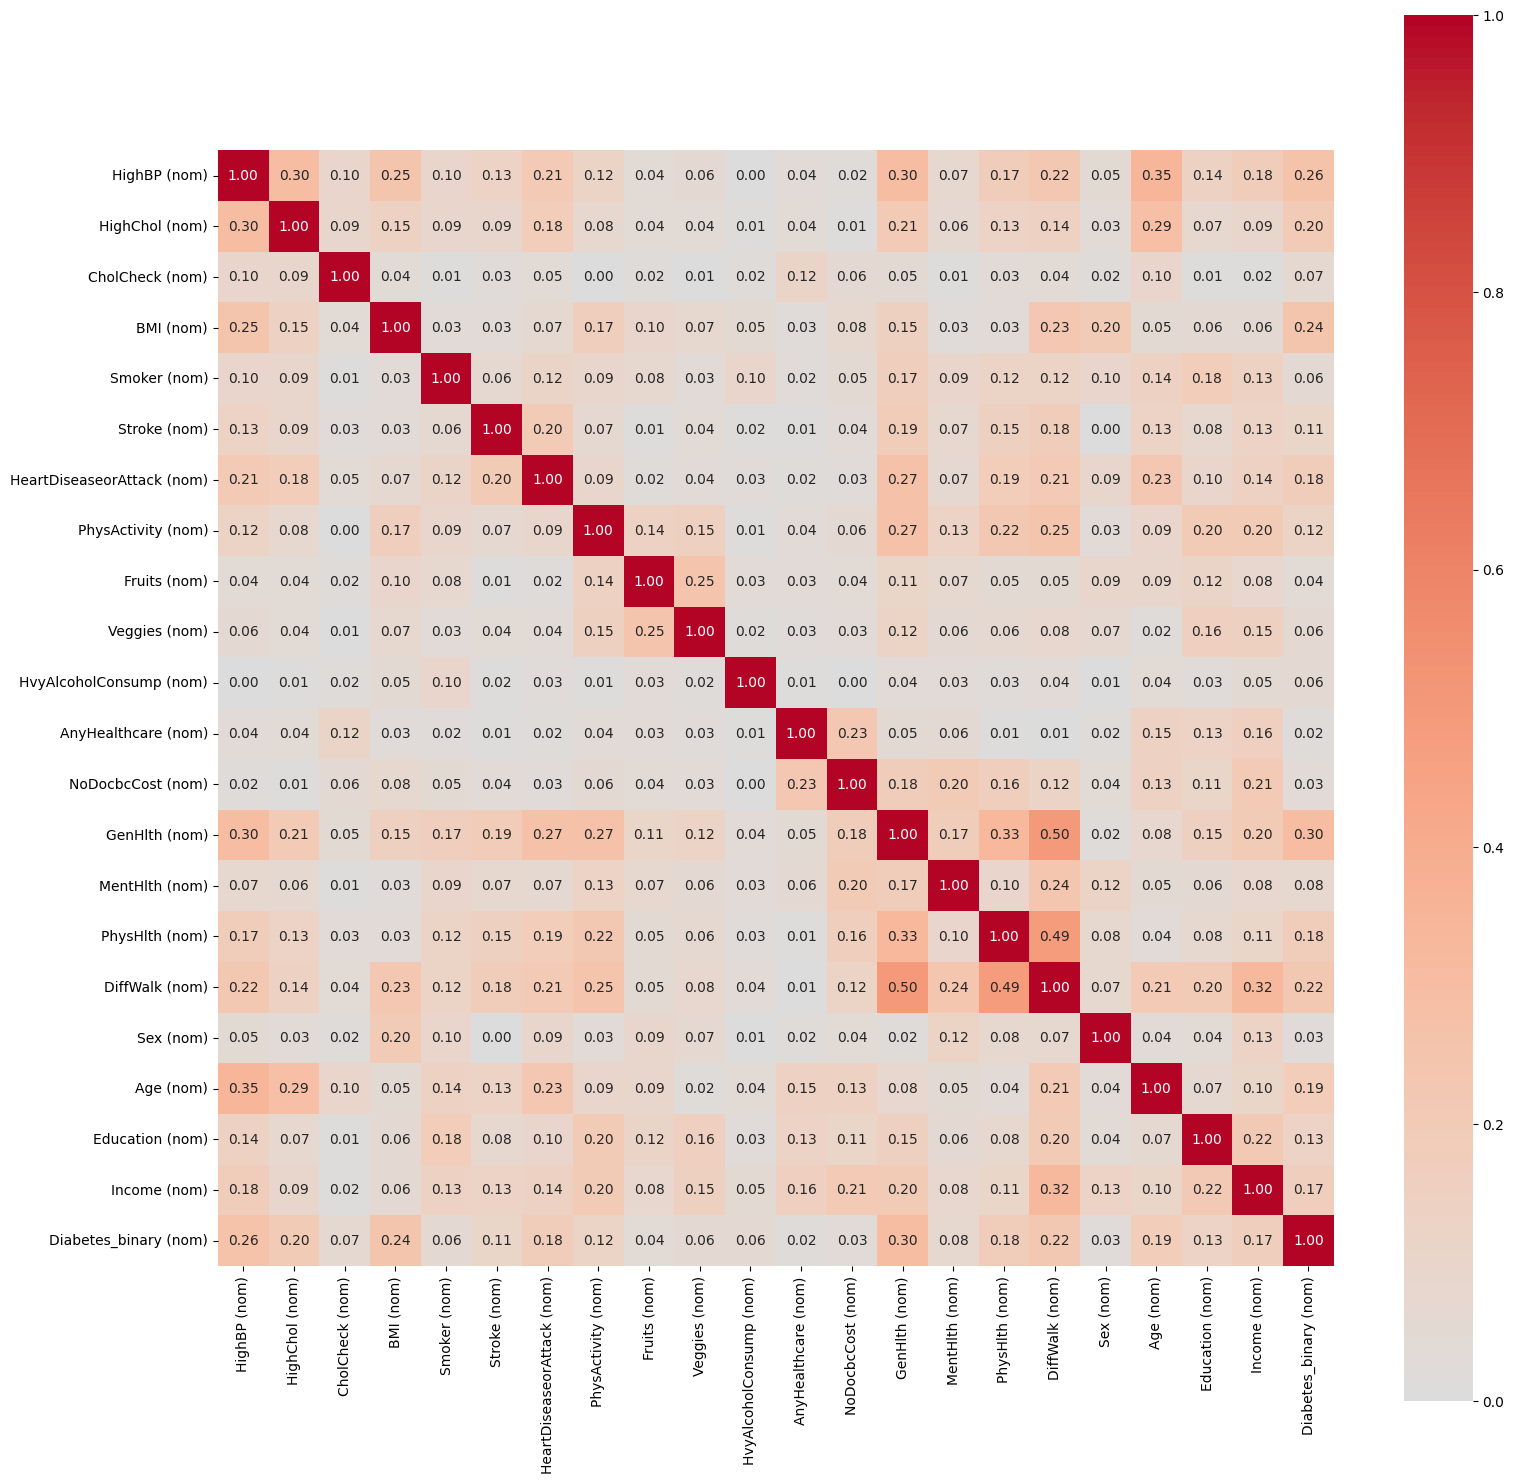

In [15]:

# --- Matriz de correlación mixta con Dython ---
# Unimos los conjuntos de train para evaluar la correlación entre todas las variables incluida la variable objetivo
df_train_completo = pd.concat([X_train, y_train], axis=1)
matriz_asociaciones = associations(df_train_completo,
                     nominal_columns='all',    # detecta categóricas automáticamente
                     mark_columns=True,        # marca cuáles son categóricas
                     plot=True,                # dibuja el heatmap
                     cmap='coolwarm',          # asignamos paleta de color
                     figsize=(18, 18)          # aumentamos tamaño para una mejor visualización
                    )



Al tener un dataset en el que se mezclan variables continuas con variables categóricas y ordinales, se ha generado una matriz de correlación basada en la V de Cramér y la U de Theilm,  ya que pandas.corr() utiliza la correlación de Pearson que asume continuidad y lienalidad de las variable, que no es nuestro caso, por lo que perderíamos información en relaciones complejas o no lineales presentes en las variables categóricas.
Al utilizar Dython logramos que crear una matriz de asociaciones entre variables de distinta tipología a la numérica continua:
* Si tiene que evaluar dos variables numéricas, usa Pearson.
* Si cruza dos variables categóricas, usa Cramér (evaluando la independencia entre dos variables nominales u ordinal, su valor oscila entre $0$ (independencia total) y $1$ (asociación perfecta). Al ser simétrica, el grado de asociación de $X$ hacia $Y$ es idéntico al de $Y$ hacia $X$) o usa Theil ( utilizando el concepto de entropía. Mide qué proporción de la incertidumbre de una variable $Y$ puede ser explicada o reducida si conocemos el estado de la variable $X$. Al fundamentarse en la entropía condicional, es asimétrica lo que indica que la información que $X$ aporta sobre $Y$ es total ($1.0$), pero la que $Y$ aporta sobre $X$ es parcial o nula.
* Si cruza una variable continua con una categórica, usa Correlation Ratio (se utilizará cuando se cruza una variable continua (como el BMI) con una categórica (como Diabetes_binary). Mide la dispersión de las medias de la variable continua dentro de cada categoría definida por la variable nominal, evaluando relaciones que no son estrictamente lineales.)

El análisis de la variable objetivo (Diabetes_binary) revela asociaciones fuertes con variables como la Salud General Percibida (GenHlth: 0.30), seguido de la Hipertensión (HighBP: 0.26), el Índice de Masa Corporal (BMI: 0.24), la dificultad de movilidad (DiffWalk: 0.22) y el colesterol algo (0,20).

A nivel de variables independientes, el mapa de calor confirma algunas de las hipótesis que se han realizado al analizar las gráficas anteriormente, ya que vemos que hay una asociación fuerte entre la edad y la hipertensión (0.35), así como entre esta última y el colesterol alto (0.30), evidenciando el perfil del Síndrome Metabólico.  
Sin embargo, se detecta una alta multicolinealidad en el bloque de formado por las variables DiffWalk, PhysHlth y GenHlth que muestran unos índices de asociación cruzada que alcanzan hasta el 0.50. Esta nos muestra que tenemos redundancia de información en estas 3 variables y que puede ser un escenario ideal para la aplicación de ensambles basados en árboles de decisión, que son muy robustos ante la colinealidad.

Nos llama la atención la baja asociación (0.10) entre las variables de salud física (PhysHlth) y salud mental (MentHlth). Durante el análisis de las gráficas de ambas variables, se podían observar distribuciones prácticamente idénticas, por lo que nos resultó intuitivo pensar que existiría una fuerte colinealidad entre ambas. Sin embargo, en la matriz de asociación se demuestra que la similitud gráfica no implica coocurrencia, indicando que la probabilidad conjunta de padecer simultáneamente problemas físicos y mentales severos es baja en este conjunto de datos. Es decir, que parece ser que los individuos que reportan valores extremos en PhysHlth no son, en su mayoría, los mismos que reportan valores extremos en MentHlth. POr lo tanto, podemos incluir ambas variables en el modelo predictivo, ya que, lejos de ser redundantes, aportan señales independientes sobre el estado de salud del encuestado.

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
    </div>
</div>
Correlaciones solo con la variable objetivo  
A continuación, visualizamos solo la relación de las variables predictoras con la variable objetivo, para tener de forma más clara y visual qué variables tienen más peso sobre el objetivo a predecir.

Recordemos que correlación mide asociación y no causalidad.

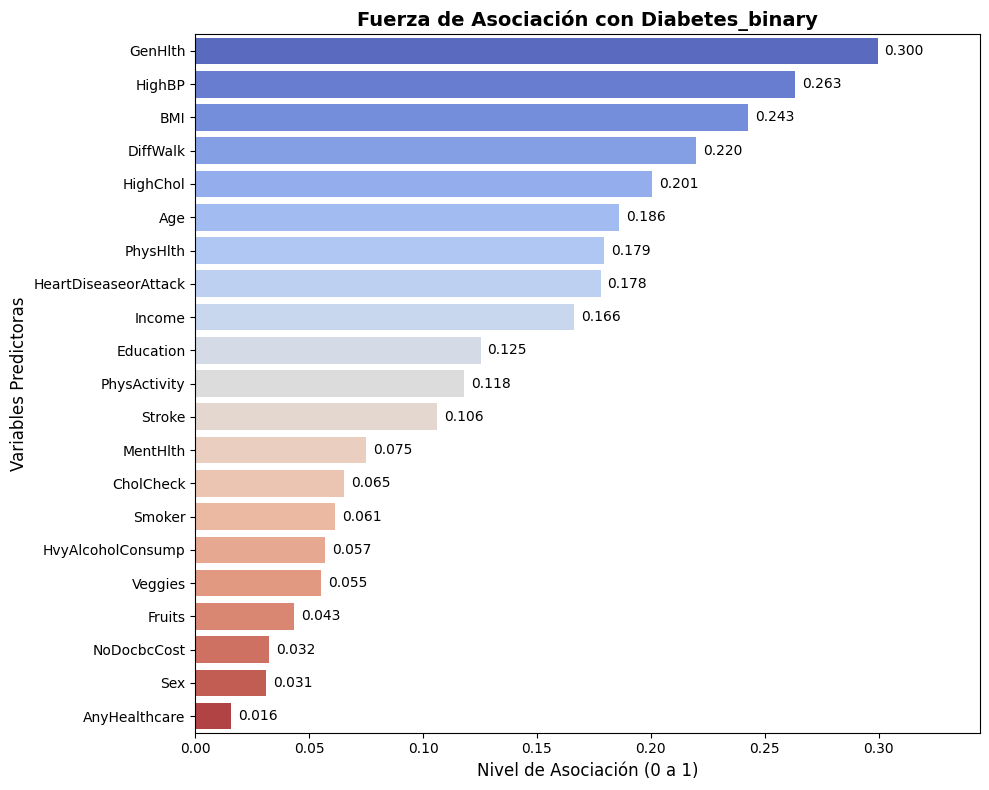

In [16]:
# Extraemos la matriz de números que ha calculado Dython
matriz_correlacion =matriz_asociaciones['corr']
# Usamos el nombre exacto que le ha puesto Dython
nombre_columna = 'Diabetes_binary (nom)'

# Aislamos la columna y borramos la fila homónima (para no ver el 1.0)
correlacion_objetivo = matriz_correlacion[[nombre_columna]].drop(nombre_columna)

# Ordenamos de mayor a menor para que en la gráfica estén ordenadas las barras por fuerza de asociación con la variable objetivo
correlacion_objetivo = correlacion_objetivo.sort_values(by=nombre_columna, ascending=False)

# Limpiamos el sufijo ' (nom)' del índice para que la gráfica no quede con el sufijo añadido por Dython en la matriz de correlación
correlacion_objetivo.index = correlacion_objetivo.index.str.replace(' \(nom\)', '', regex=True)

# Graficamos con barras horizontal
plt.figure(figsize=(10, 8))
ax = sns.barplot(x=correlacion_objetivo[nombre_columna], 
                 y=correlacion_objetivo.index, 
                 palette='coolwarm')

# Añadimos los números exactos a la derecha de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5)

# Detalles estéticos
plt.title('Fuerza de Asociación con Diabetes_binary', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Asociación (0 a 1)', fontsize=12)
plt.ylabel('Variables Predictoras', fontsize=12)

# Damos margen a la derecha para que los números respiren
plt.xlim(0, correlacion_objetivo[nombre_columna].max() * 1.15) 

plt.tight_layout()
plt.show()

Con esta gráfica, obtenemos una visualización clara y concisa de las variables predictorias que más fuerza tienen sobre la variable objetivo y que el modelo tomará en cuenta para tomar sus deciosiones.
* **GenHlth** (0.300): La percepción general de salud es la variable que claramente tiene más fuerza sobre la predicción.
* **HighBP** (0.263) y **HighChol** (0.201): El Síndrome Metabólico como habíamos detectado anteriormente también se asocia de forma fuerte con la variable obetivo.
* **BMI** (0.243): El índice de masa corporal confirma un estatus de factor de riesgo.
* **DiffWalk** (0.220): La dificultad para caminar actúa como un gran indicador de complicaciones físicas avanzadas.

Esta gráfica también nos muestra otras variables que tienen una correlación mínima con la variable objetivo, mostrando valores casi nulos, por lo que es posible que solo aporten ruido al modelo, de momento las mantenemos para las siguientes pasos.


<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id = "bivariante" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color:rgb(18, 223, 127); font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
            3.3. Análisis bivariante de las variables predictoras con la variable objetivo
        </h3>
    </div>
</div>
Analizamos la distribución de las variables predictoras del dataset con respecto a la variable objetivo, graficando la distribución de cada variable distribuida según si presentan diabetes o no.
Para hacer este análisis de forma correcta, vamos a diferenciar entre variables ordinales o binarias que graficaremos con una diagrama de barras y variables continúas como es el caso de la variable BMI que utilizaremos una gráfica con la curva KDE..

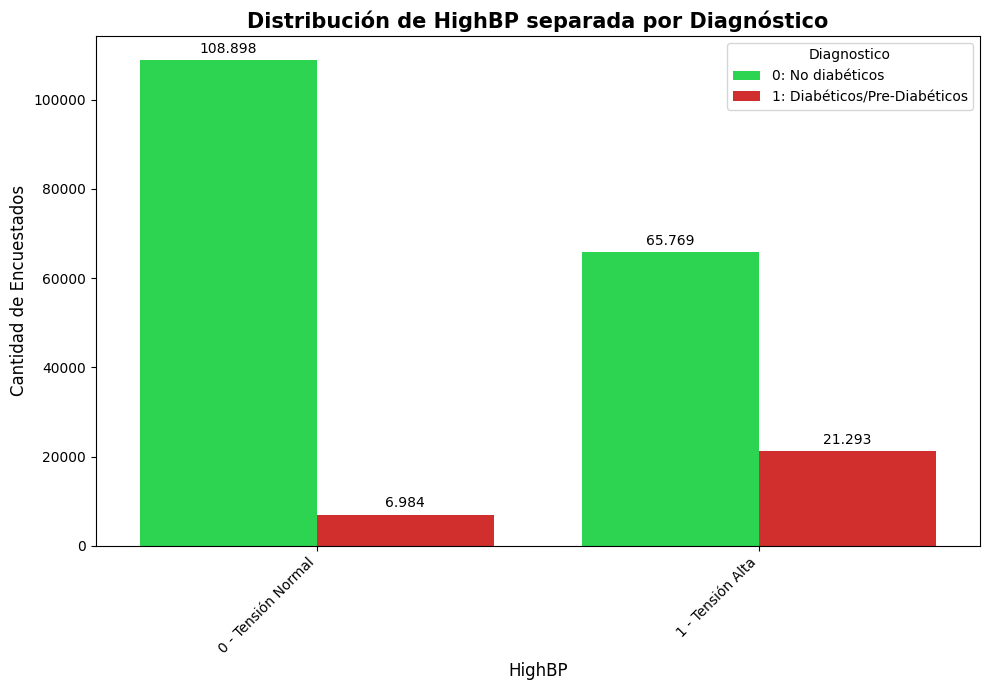

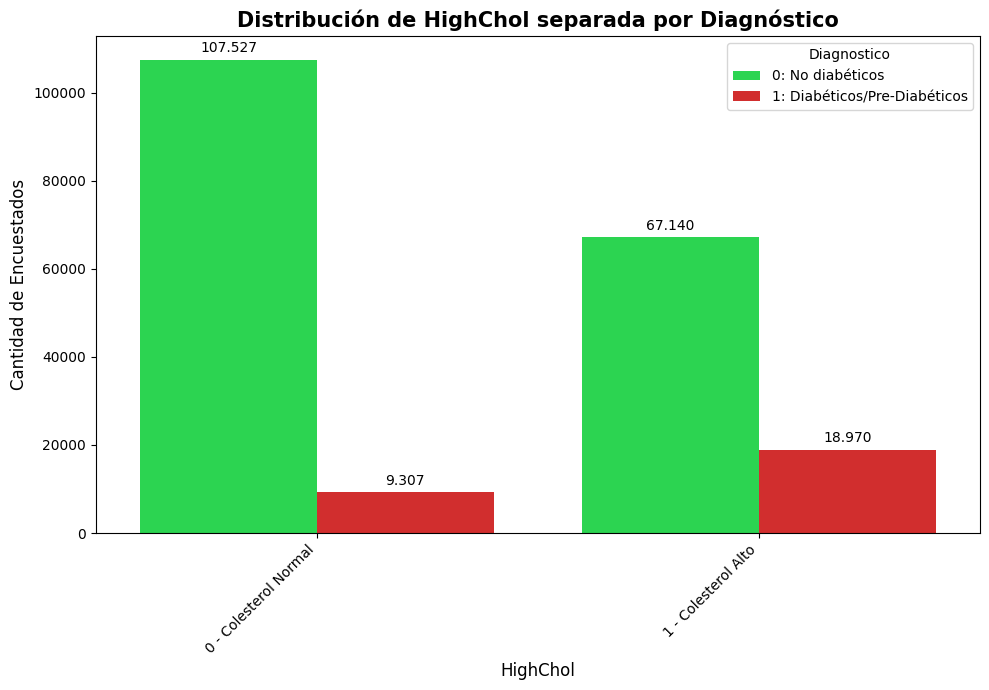

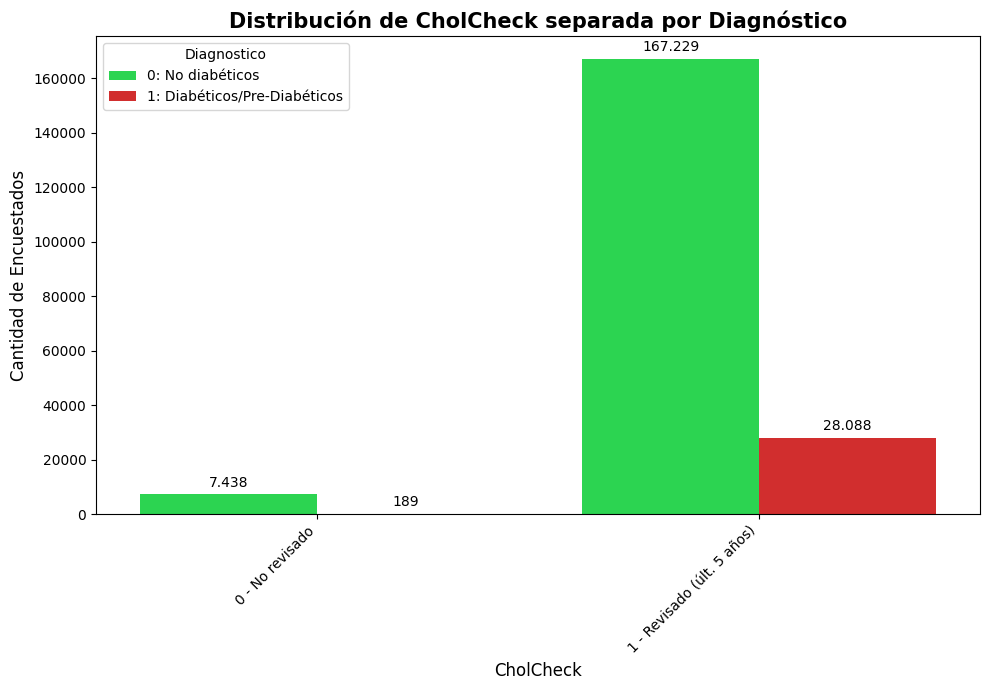

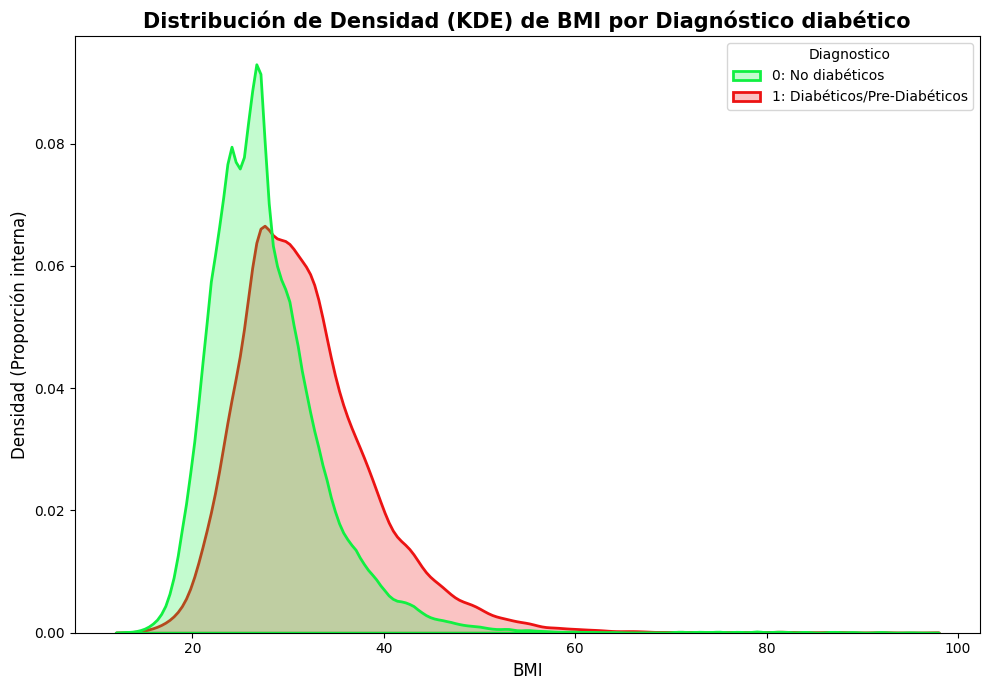

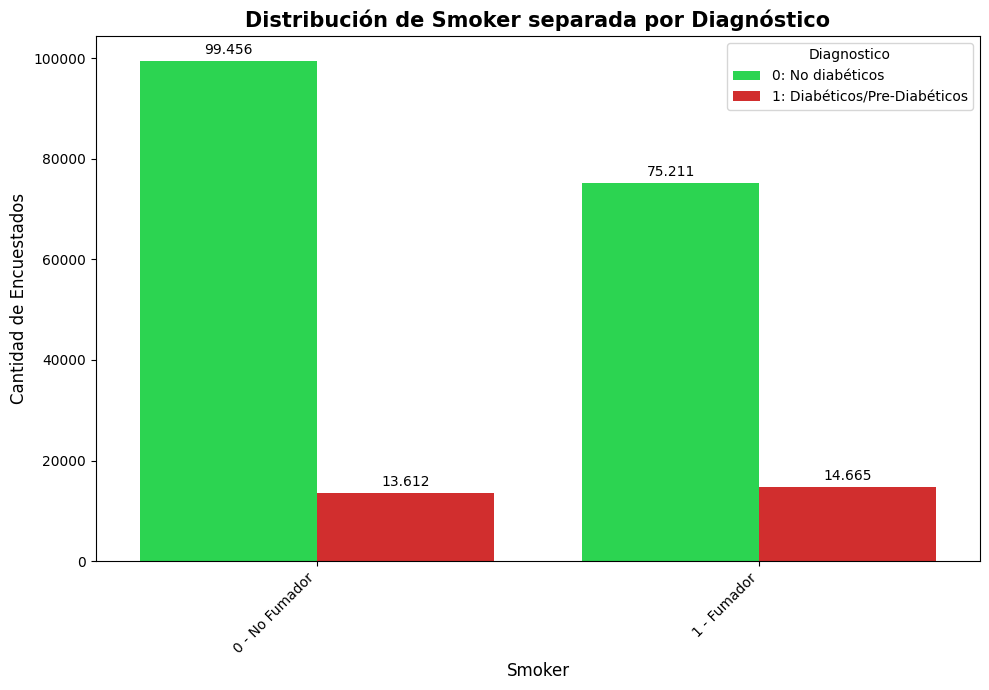

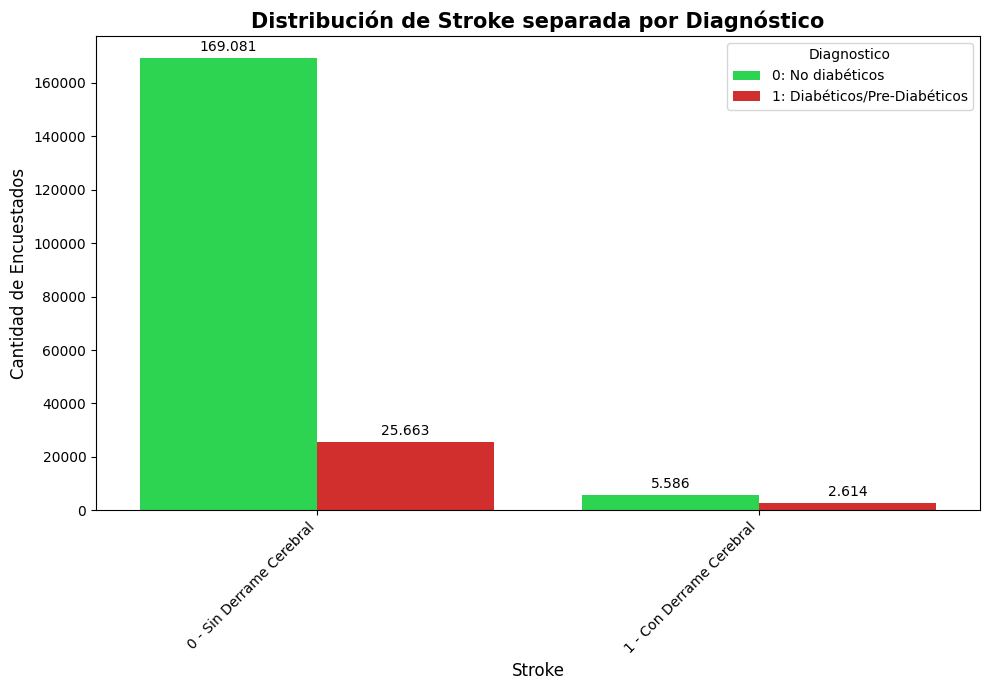

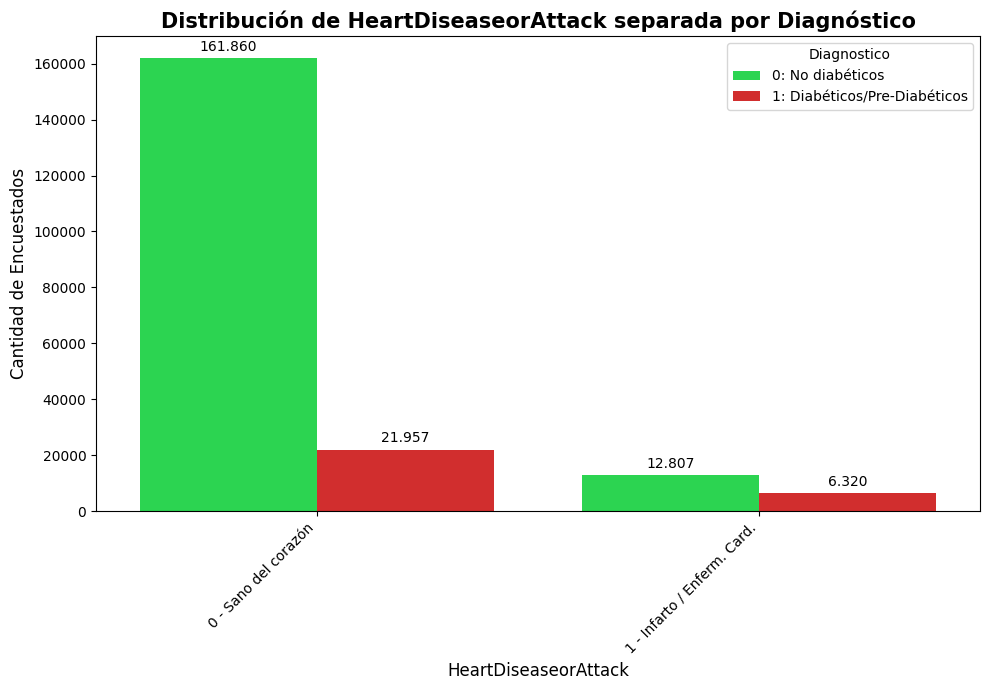

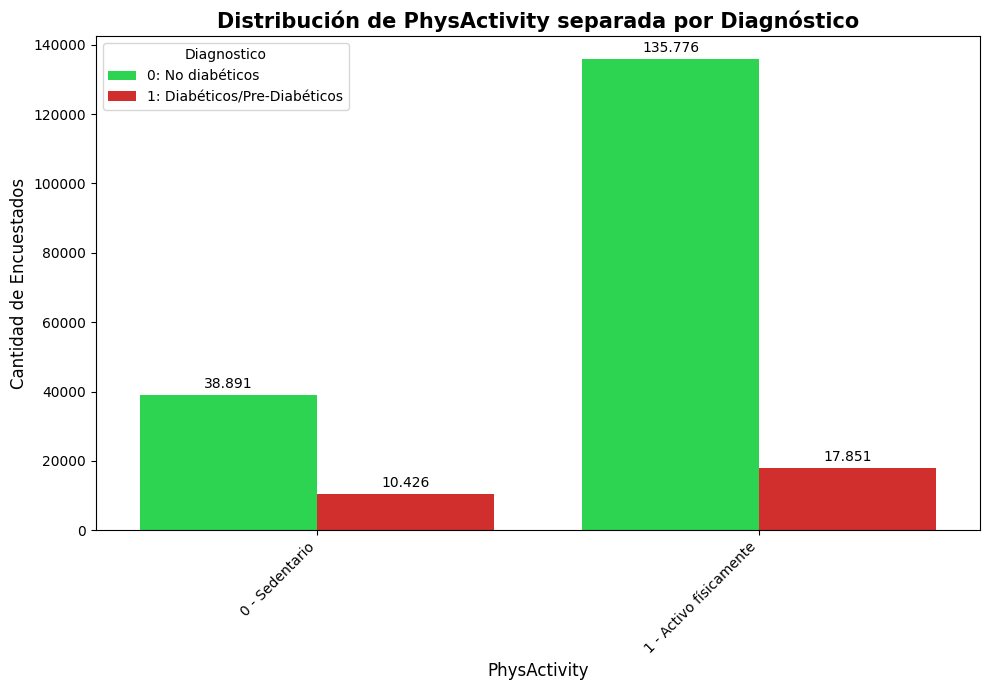

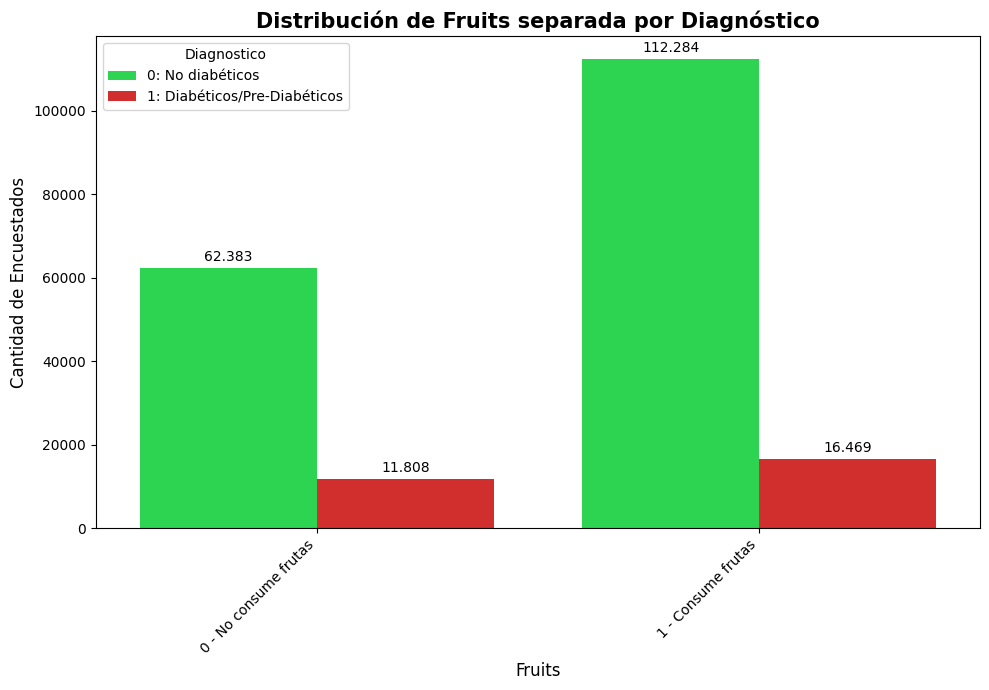

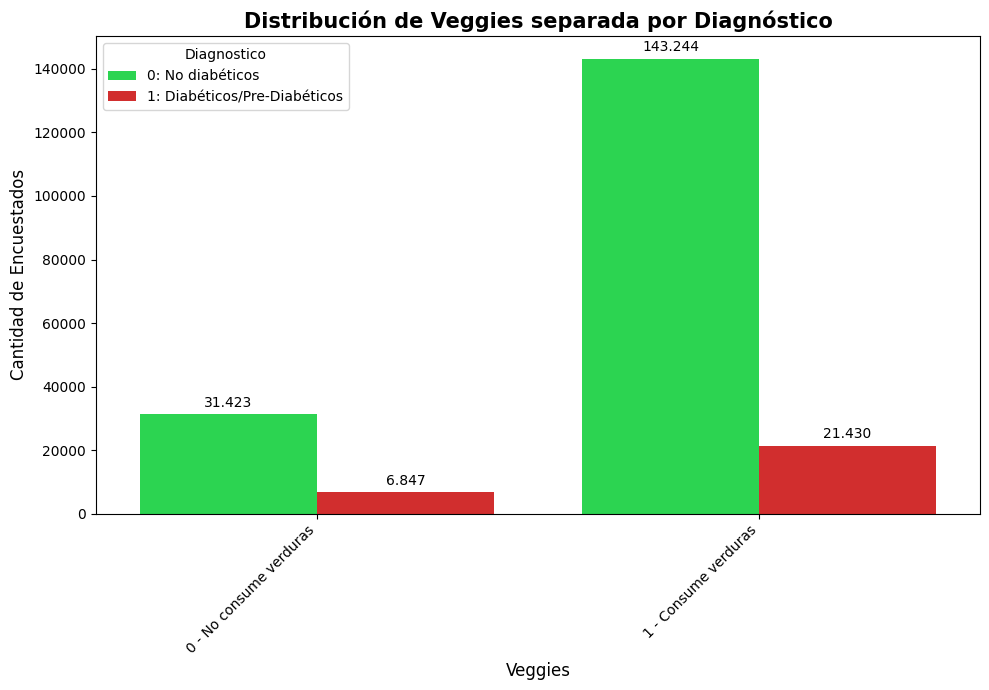

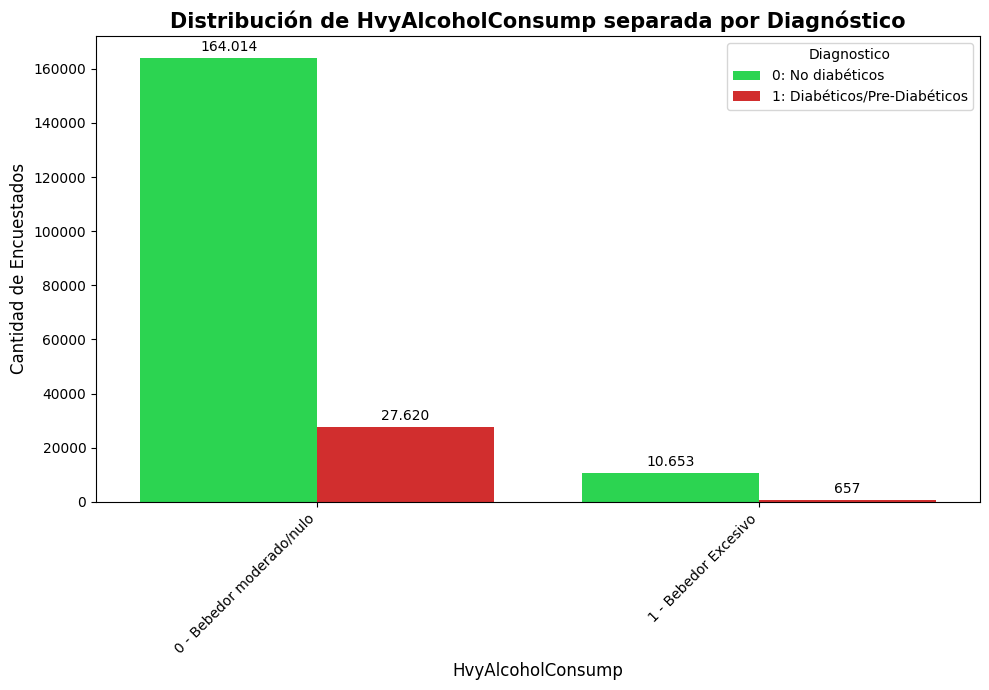

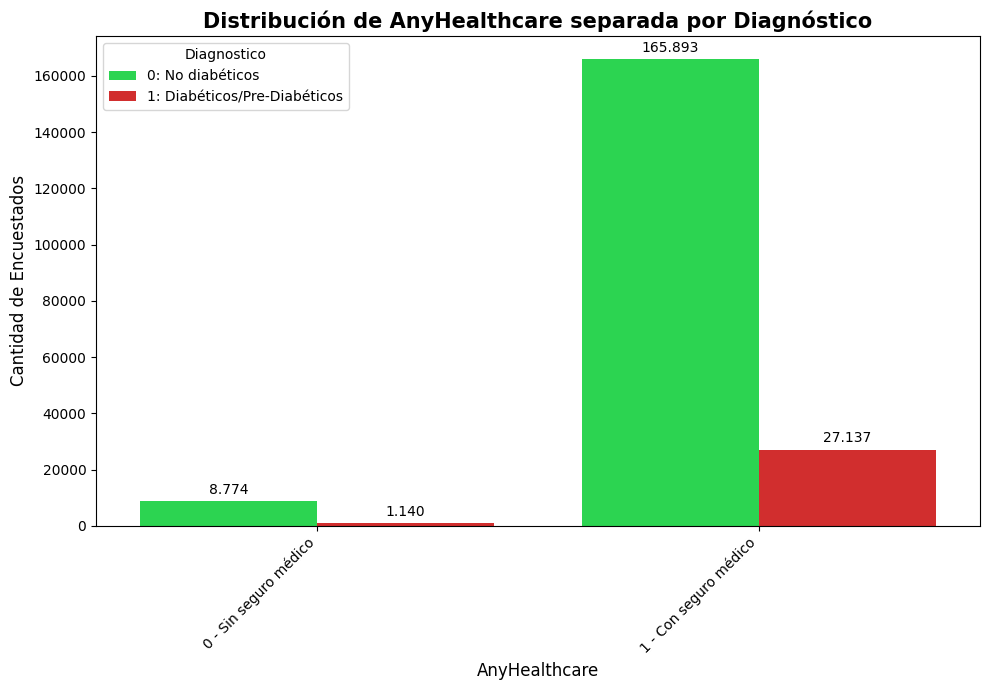

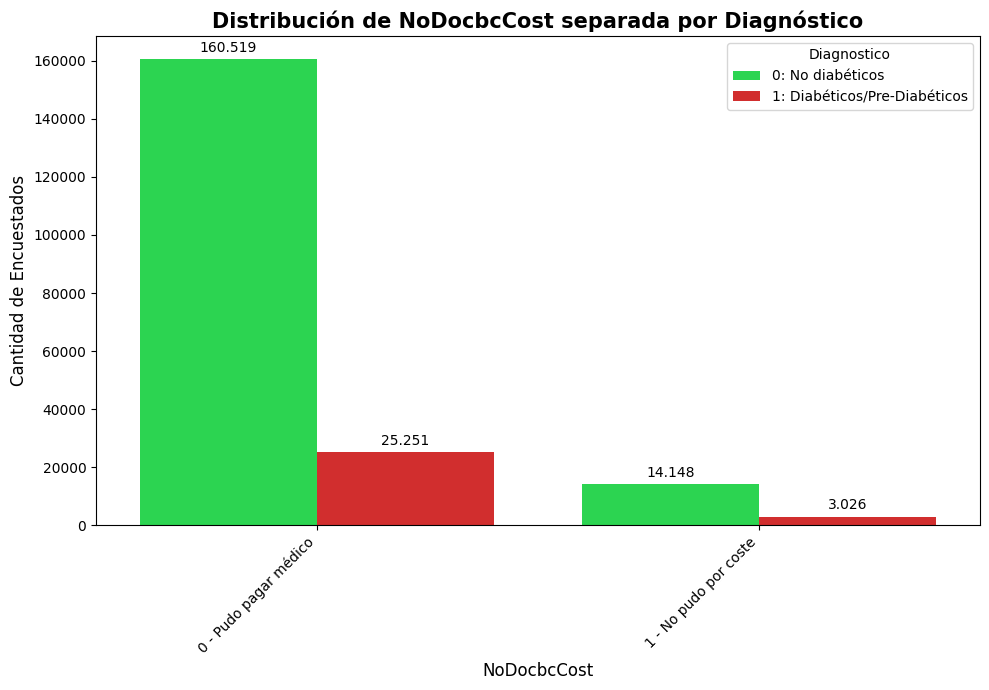

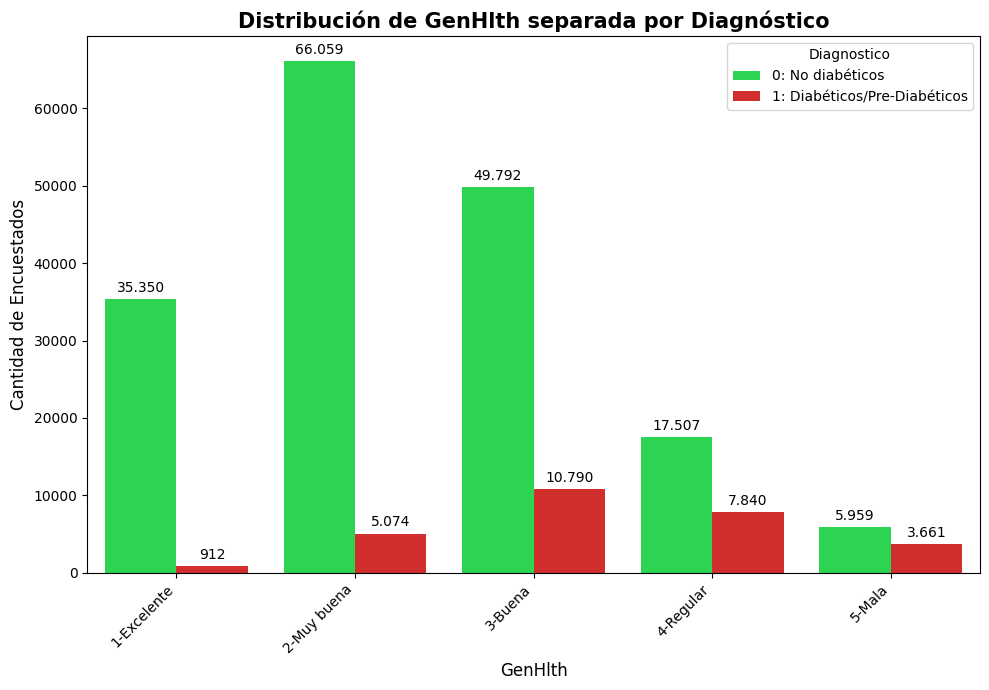

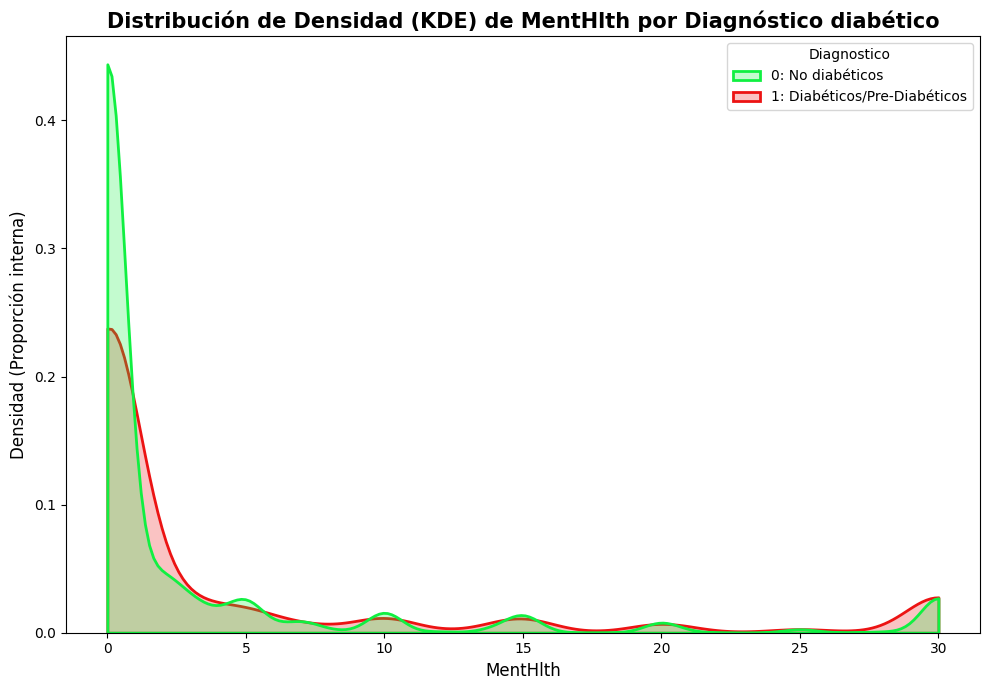

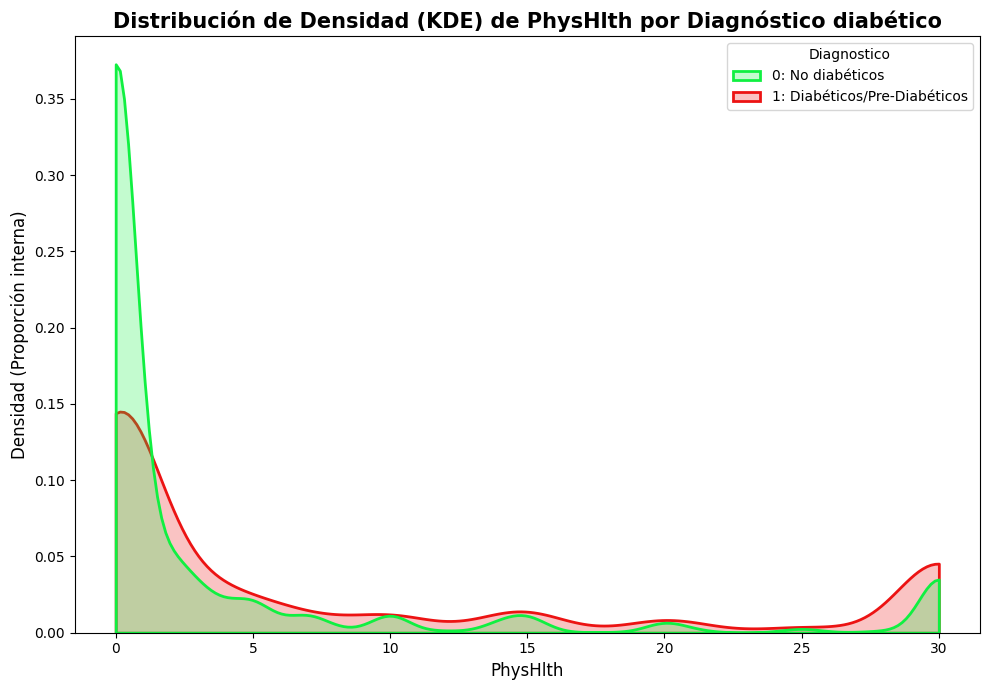

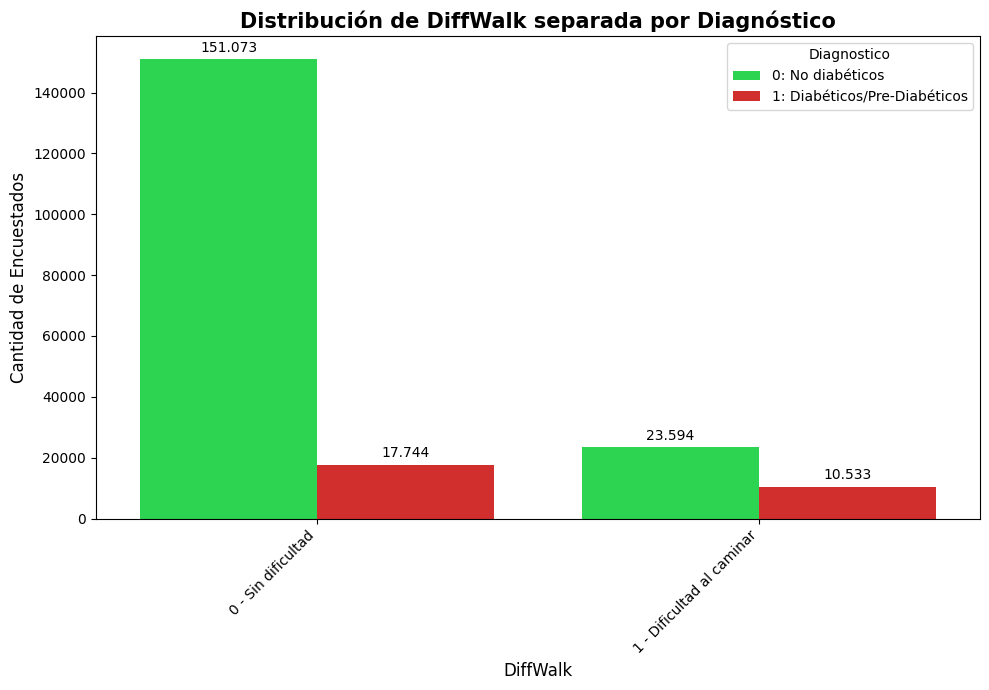

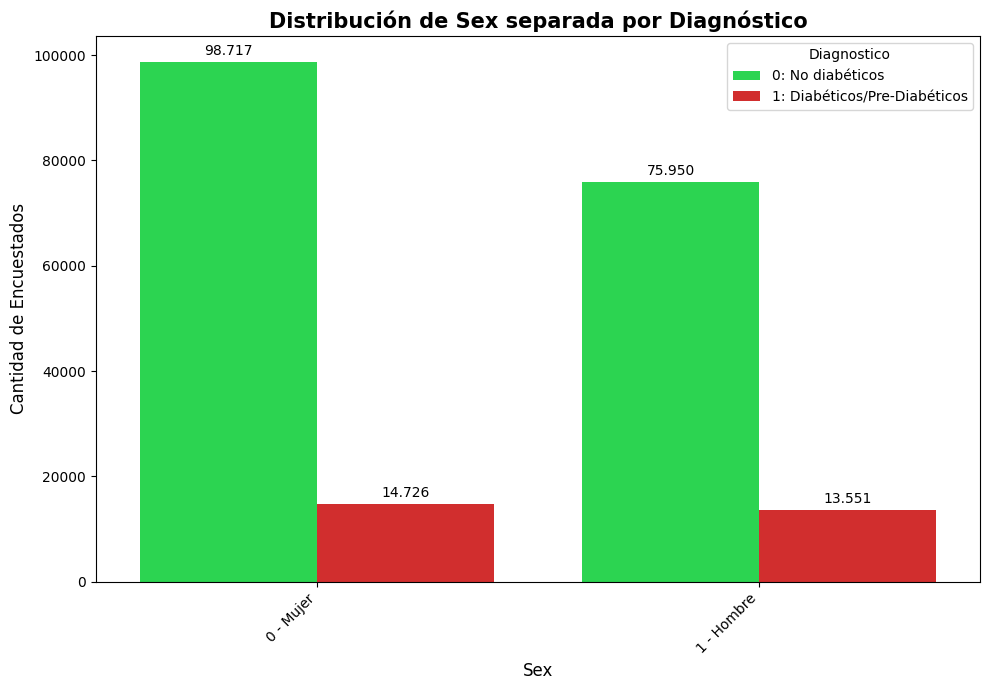

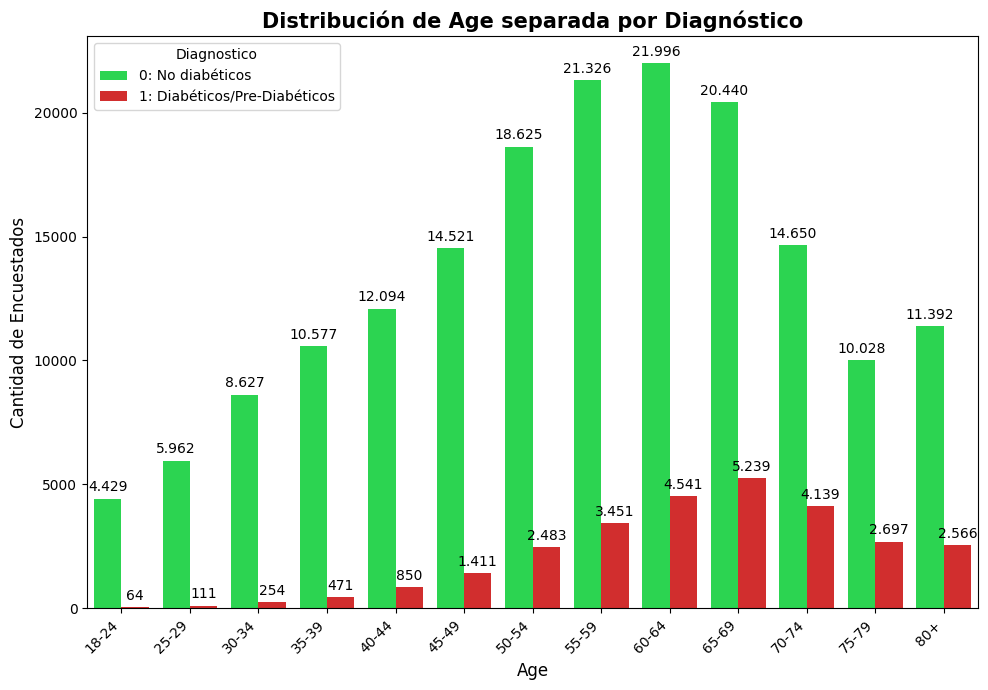

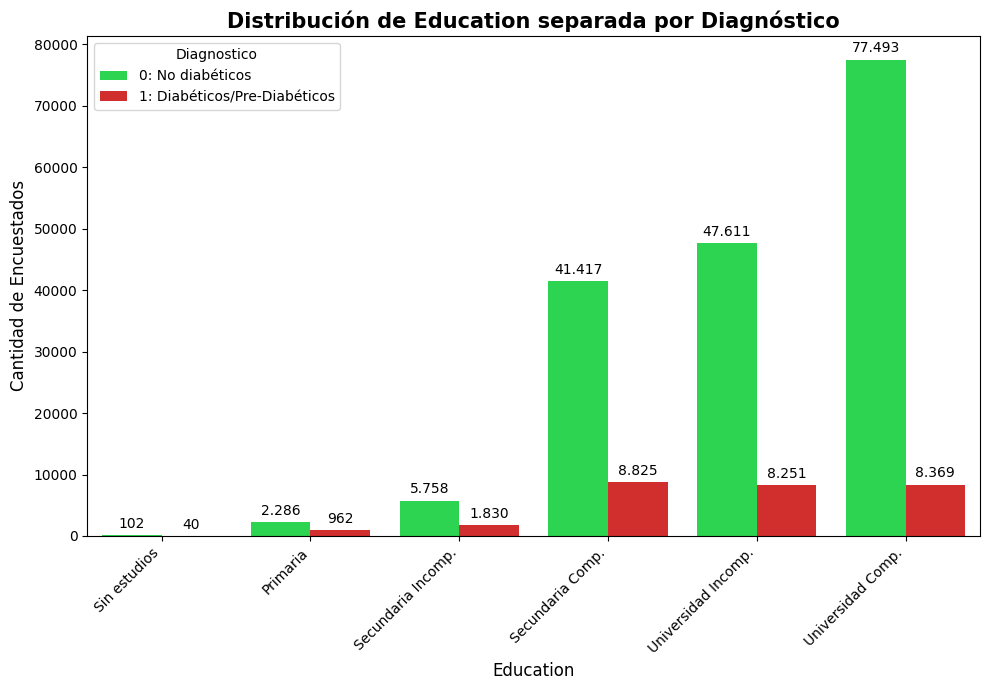

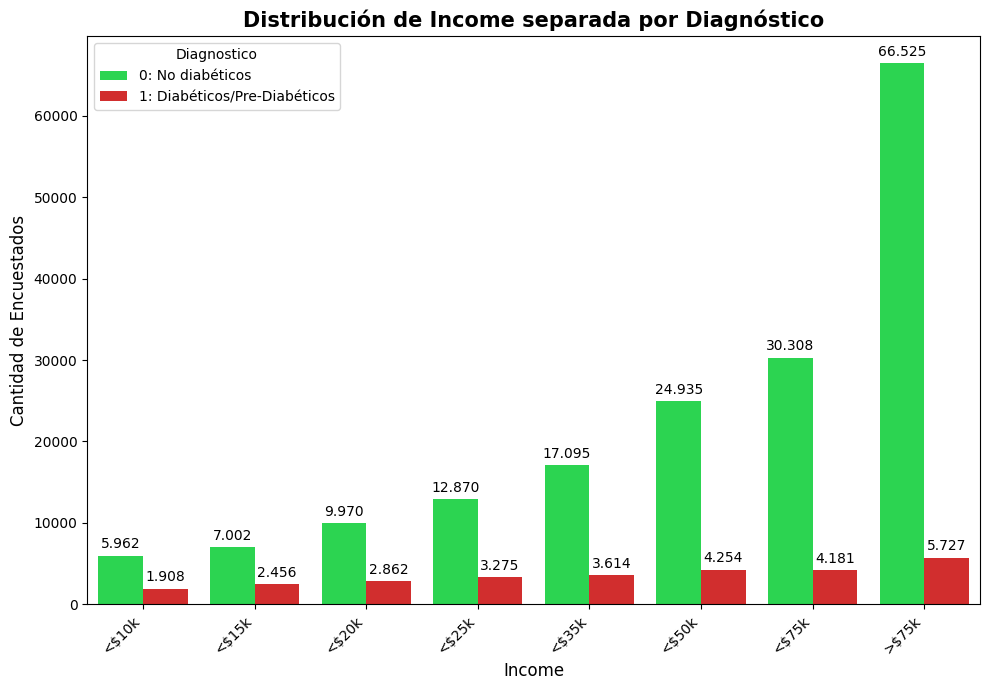

In [17]:

df_train_completo['Diagnostico'] = df_train_completo['Diabetes_binary'].map({
    0: '0: No diabéticos', 
    1: '1: Diabéticos/Pre-Diabéticos'
})
orden_leyenda = ['0: No diabéticos', '1: Diabéticos/Pre-Diabéticos']
for col in numerical_features:
    plt.figure(figsize=(10, 7))
    
    # Si la variable tiene 15 valores únicos o menos, la tratamos como categórica/ordinal
    # (Age tiene 13, GenHlth 5, las binarias 2. Solo BMI tiene más de 15)
    if df_train_completo[col].nunique() <= 15:
        # Gráfico de barras agrupado por clase (Sano = Verde, Diabético = Rojo)
        ax = sns.countplot(data=df_train_completo, 
                           x=col, 
                           hue='Diagnostico', 
                           hue_order=orden_leyenda, # Forzamos el orden (0=Verde, 1=Rojo)
                           palette=["#10f041", "#ec1313"])
        
        plt.title(f'Distribución de {col} separada por Diagnóstico', fontsize=15, fontweight='bold')
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Cantidad de Encuestados', fontsize=12)

        # Sustituimos valores de las variables ordinales que contienen 0, 1, 2 para identificar las agrupaciones por las etiquetas descriptivas
        # Para ello comprobamos si la columna se encuentra en el diccionadio de mapeo
        if col in mapeo_etiquetas:
            # Extraemos los números actuales que tiene la gráfica (ej: 1.0, 2.0...)
            valores_actuales = [float(t.get_text()) for t in ax.get_xticklabels()]
            # Buscamos su traducción en nuestro diccionario
            nuevas_etiquetas = [mapeo_etiquetas[col].get(val, str(val)) for val in valores_actuales]
            # Aplicamos las nuevas etiquetas y las rotamos 45 grados para que se lean bien en la gráfica
            ax.set_xticklabels(nuevas_etiquetas, rotation=45, ha='right', fontsize=10)
        # Indicamos los números de encuestados que forman el bloque de cada barra 
        for container in ax.containers:
            # Si la barra no tiene altura (0), no ponemos texto
            etiquetas = [f"{int(barra.get_height()):,}".replace(",", ".") if barra.get_height() > 0 else "" for barra in container]
            ax.bar_label(container, labels=etiquetas, padding=3, fontsize=10)
    else:
        # Para variables continuas (como BMI), usamos curvas KDE superpuestas
        # common_norm=False hace que la curva roja (minoría) no se vea aplastada por la verde (mayoría)
        # Obtenemos el rango de la variable para acotar la curva KDE para que no salga del mismo
        min_real = df_train_completo[col].min()
        max_real = df_train_completo[col].max()
        sns.kdeplot(data=df_train_completo, 
                    x=col, 
                    hue='Diagnostico', 
                    hue_order=orden_leyenda, # Forzamos el orden (0=Verde, 1=Rojo)
                    fill=True, 
                    palette=["#10f041", "#ec1313"],
                    linewidth=2,
                    common_norm=False, 
                    clip=(min_real, max_real)
                )
               
        plt.title(f'Distribución de Densidad (KDE) de {col} por Diagnóstico diabético', fontsize=15, fontweight='bold')
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Densidad (Proporción interna)', fontsize=12)
    
    plt.tight_layout()
    plt.show()

**Análisis de las gráficas de variables continuas:**
* `BMI`: La estimación de densidad de kernel (KDE) estratificada para el Índice de Masa Corporal (BMI) muestra que la moda (que es el pico de máxima densidad) es prácticamente idéntica para ambas clases, situándose en un rango de sobrepeso (BMI ~27). Sin embargo, también se observa que la curva para los encuestados diagnosticados con diabetes o pre-diabetes, tiene una asimetría positiva, lo que nos explica que la distribución de los pacientes diabéticos presenta una 'cola derecha' notablemente más pesada y aplanada. A medida que el BMI supera el umbral marcado para determinar si una persona tiene obesidad (BMI > 30), el área bajo la curva de la clase positiva envuelve y supera ampliamente a la de la clase negativa. Esto indica a los algoritmos predictivos que, si bien un BMI medio no es un clasificador definitivo, los valores extremos en el extremo superior son fuertes predictores de la enfermedad
* `PhysHlth` y `MentHlth`, el análisis del estado de salud mensual demuestra que la salud física, muestra una mayor población de encuestados diabéticos cuando el dolor es crónico (tiene dolor todo los días del ultimo mes...), en cambio en salud mental, las distribuciones de los encuestados son muy parecidas entre las dos clases.

**Análisis de las variables que contienen datos socioeconómicos y demográficos:**

* Se observa una correlación inversa entre el estatus socioeconómico y el padecimiento de la enfermedad diabética: a mayor nivel educativo `Education`('Universidad Comp.') y mayores ingresos `Income`('>$75k') se una proporción condicional de encuestados diabetéticos significativamente menor, por lo que parece que este estatus social y económoico, actua como escudo protector metabólico. Estos resultados parecen indicar que el nivel adquisitivo y educativo actúan como potentes factores protectores, por lo que estes estatus parece facilitar el acceso a un estilo de vida preventivo y a recursos sanitarios de calidad.
* Por otro lado, la distribución de la edad `Age` manifiesta aún más la naturaleza del dataset, alineándose con la epidemiología clásica de la Diabetes Mellitus Tipo 2. La incidencia de la clase positiva es residual en los grupos más jóvenes, experimentando un crecimiento exponencial a partir de los 45 años y alcanzando una proporción mayor de pacientes diabéticos en el segmento de 65 a 69 años. Este comportamiento es coherente con la etiología de la Diabetes Tipo 2, caracterizada por ser una patología metabólica de desarrollo tardío y acumulativo.
* La variable que informa el género del encuestado, `Sex`, muestra una distribución proporcional prácticamente simétrica entre clases, algo que justificaría su baja fuerza de asociación predictiva (0.031) detectada anteriomente en la matriz de correlación.

**Análisis de las variables que contienen datos sobre hábitos de vida y percepción de la salud:**

* El análisis bivariante de los determinantes de estilo de vida revela patrones tanto de riesgo y como de protección fuertemente marcados. La percepción general de salud (GenHlth) destaca como el predictor más robusto, a medida que la salud percibida empeora, la proporción de la barra de encuestados diábeticos se dispara. Al llegar a "5-Mala", la proporción muestra que prácticamente un 40% del grupo tiene enfermedad diabñetica. Los pacientes, normalmente, saben cuando están enfermos, la diábetes se acompaña de otros problemas secundarios lo que da al enfermo una percepción negativa de su propio estado de saludo.

* En cuanto a la variable `PhysActivity`, muestra que el grupo de encuestados sedentarios, duplica proporcionalmente el riesgo de pertenecer a la clase diabética frente a los individuos físcamente activos (~21% vs ~11%), lo que puede consolidar como factor de riesgo primario, que podría venir apoyado de forma secundario por la ausencia de consumo de frutas y verduras, `Fruits` y `Veggies`. Estas dos variables visualmente tienen un comportamiento casi idéntico, los encuestados que no consumen frutas ni verduras presentan una barra roja proporcionalmente más alta. Son factores protectores, aunque visualmente su impacto es más suave que el del ejercicio físico.

* Debemos destacar un nuevo fenómeno de sesgo clínico en el consumo excesivo de alcohol `HvyAlcoholConsump`. A simple vista, podría parecer que beber en exceso protege contra la diabetes, hay poquísimos diabéticos bebedores en exceso: solo 657, esto es algo que se denomina Causalidad Inversa o Sick-quitter effect, es un sesgo clásico en epidemiología, que puede ser interpretado como cuando una persona es diagnostica de diabetes o pre-diabetes, el propio diagnóstico de la enfermedad conlleva prescripciones médicas que suprimen el hábito de consumo de alcohol en la clase positiva. habrá que ser cauto con la interpretación de esta variable, para no inferir correlaciones que realmente no existe ninguna relación real de causa y efecto entre ellas.

* El Tabaco `Smoker`,  la diferencia visual de proporciones entre fumadores y no fumadores no es tan abismal como se podría esperar. Es un factor de riesgo (la barra roja es proporcionalmente mayor en los fumadores), pero no es el principal motor de la enfermedad.

* Chequeo de Colesterol `CholCheck`, muestra que la mayoría de la población entrevistada se ha revisado el colesterol en los últimos 12 meses. En el pequeño grupo de "No revisado", apenas hay diabéticos, consecuencia directa de los controles médicos rutinarios que deben realizarse las personas diabéticas.

**Anáslisis de la variables que contienen Indicadores Clínicos:**
* El Síndrome Metabólico: Tensión y Colesterol `HighBP` y `HighChol`, son factores fundamentales del mismo.
Las gráfica de la variable `HighBP` muestra que en en el grupo con tensión normal, la barra roja es pequeñísima (6.984 vs 108.898). Sin embargo, al pasar al grupo con tensión alta, la barra roja explota hasta los 21.293 casos. Lo que nos indica, que el riesgo de enfermedad diabética se amplifica muchisimo con problemas de hipertensión.

* La gráfica de `HighChol` muestra un patrón idéntico al de la tensión. La diabetes, la hipertensión y la hiperlipidemia comparten las mismas causas subyacentes (obesidad, sedentarismo, mala dieta).

* Complicaciones Cardiovasculares Graves `HeartDiseaseorAttack`y `Stroke`: la mayoría de la población encuestada está en la barra "0 - Sano". Sin embargo, si nos fijamos solo en la columna de los que sí han sufrido un infarto o un derrame cerebral, la proporción de la barra roja crece. Estas variables actúan como indicadores de daño orgánico acumulado (complicaciones macrovasculares).

* Dificultad para caminar `DiffWalk`: en el análisis de Dython esta variable sacó una nota muy alta (0.220), analizando la columna "1 - Dificultad al caminar", la barra verde cae (de 151k a 23k), pero la roja se mantiene muy robusta (de 17k baja solo a 10k), lo que significa que casi 1 de cada 3 personas con problemas de movilidad tiene diabetes, capturando así las complicaciones microvasculares de la enfermedad, como la neuropatía diabética (pie diabético, pérdida de sensibilidad), problemas de visión severos... Esta variable captura indirectamente el impacto incapacitante de las complicaciones diabéticas avanzadas (como la neuropatía periférica) y el sedentarismo extremo, consolidando a esta variable como uno de los discriminadores más potentes del modelo predictivo.


En estas gráficas se manifiesta de forma más visual el **sesgo de representación** comentado anteriormente, el análisis de las variables Education, Age y Income evidencian una sobrerrepresentación muy significativa en los ciertos estratos: 
* La inmensa mayoría de la muestra se concentra en los niveles más altos de educación, destacando por encima de todos ellos, el grupo con "Universidad Completada" con más de 85,000 encuestados totales, al igual que sucede en el estudio de los ingresos, en el que destacan los encuestados con un salario superior a los $75,000 anuales. Estos grupos en la práctica, es muy posible que tengan un mejor acceso a sanidad preventiva y mejor nutrición que personas de otros estratos sociales...
* En cuanto a la distribución de la variable que contiene el grupo de edad de los encuestados, también se detecta que el mayor número de encuentados se encuentra entre las edades 55 a 69 años, existiendo un deficit de datos para la detección de diabetes en adultos más jóvenes de entre 18 y 34 años.

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id = "preprocesamiento" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: #00b31bff; font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
            4. Preprocesamiento
        </h3>
    </div>
</div>
Durante la etapa del preprocesamiento de los datos, se realizarán sobre el dataset de entrenamiento las transformaciones necesarias para evitar el máximo ruido en los datos y optimizar la ocupación en memoria y  el tiempo de procesado de los mismos.<br>

- `Variables binarias (0/1)`: Diabetes_binary, HighBP, HighChol, CholCheck, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, DiffWalk, Sex.
- `Variables ordinales`: GenHlth (1–5), Age (1–13), Education (1–6), Income (1–8), MentHlth (0-30), PhysHlth (0-30).
- `Variables continuas`: BMI


#### Codificación de variables
* **Education**(1–6), **GenHlth** (1–5), **Income**(1–8), **Age** (1–13), **PhysHlth** (0-30), **MentHlth** (0-30): Son variables que tienen un orden (ej: `1` < `2` < `3` < `4`< `5` < `6`). No necesitan **`OrdinalEncoder`** porque ya de por si tienen un orden establecido entre ellas. Pero si necesitan escalado para que todos los grupos pesen lo  mismo.
* **HighBP**, **HighChol**, **HighBP**, **HighChol**, **CholCheck**, **Smoker**, **Stroke**, **HeartDiseaseorAttack**, **PhysActivity**, **Fruits**, **Veggies**, **HvyAlcoholConsump**, **AnyHealthcare**, **NoDocbcCost**, **Sex**, **DiffWalk**: Son variables binarias, solo tienen valores 0.0 y 1.0 para indicar No y Si.
* **BMI**,  : Variables numéricas continuas.

#### Definir las listas de variables
Creamos listas que agrupen las variables por el tipo exacto de preprocesamiento que van a recibir. 
* `features_binary`: variables categóricas con un orden binario compartido 0 y 1.
* `feature_standarScaler`: variables que necesitan que sus rangos se igualen antes de que el modelo aprenda de ellas pero que no tienen valores extremos.
* `feature_robustScaler`: variables que necesita que sus rangos se igualen antes de que el modelo aprenda de ellas que tienen valores extremos.


<div class="alert alert-block alert-warning">
Es importante destacar que el dataset seleccionado (diabetes_binary_health_indicators_BRFSS2015.csv) es una versión refinada del estudio original BRFSS 2015 del CDC. En el proceso de curación original del autor, se aplicó un filtrado de valores nulos implícitos. Específicamente, se eliminaron todos los registros que contenían respuestas de tipo 'Don't know / Not sure' (código 7) y 'Refused' (código 9), las cuales están presentes en la encuesta primaria. Esta decisión garantiza que las variables dicotómicas y ordinales utilizadas en este proyecto sean puras y no contengan ruido estadístico derivado de la falta de respuesta, resultando en un conjunto de 253.680 observaciones con integridad de datos completa.

Aunque el análisis exploratorio inicial en el conjunto de entrenamiento no ha revelado la presencia de valores faltantes o valores faltantes ocultos (tipo unknown o un valor por ejemplo que no esté en el rango de nuestra variables ordinales categóricas que indica que es un valor no contestado, por ejemplo 14 para la edad o 7 o 9 para la educación), por el proceso de curación previa realizado,  se ha optado por un diseño de preprocesamiento defensivo. 
Siguiendo las buenas prácticas de ingeniería de características, se han añadido objetos para imputar valores nulos en todos los flujos del transformador. De este modo, se garantiza la resiliencia del modelo ante posibles inconsistencias en la entrada de datos futuros en entorno de producción, utilizando la mediana para variables continuas/ordinales y la moda para variables binarias.
</div>


<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id = "tratarBalanceo" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: rgb(18, 223, 127); font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
            4.1. Tratamiento clase objetivo desbalanceada
        </h3>
    </div>
</div>

En el dataset seleccionado, hemos descubierto durante el EDA que las clases de la variable objetivo estás desbalanceads, hay muchísimos más registros de "Sanos" que de "Diabéticos" (86% vs 14%). 

Debemos aplicar alguna técnica para tratar este desbalanceo de clases antes de pasar al modelo.
El tratamiento sobre los datos se debe realizar sobre el conjunto de entrenamiento antes de la normalización de variables durante el preprocesamiento para preservar la integridad de las relaciones espaciales entre los datos originales del CDC. Esto garantiza que la generación de casos sintéticos de diabetes, se base en distribuciones reales de salud, minimizando la introducción de ruido estadístico que podría comprometer la transparencia del modelo.

Entre las técnica existentes tenemos:
* **SMOTE** y **SMOTENC**: s sobremuestrea para equilibrar las clases, SMOTENC tiene en cuenta los variables que contengan valores ordinales. Los datos generados, son datos sintéticos, inventados, que pueden no estar ajustados a la realidad, combinando valores que en una situación real no podrían darse, lo que puede dar luegar a generación de ruido para el modelo.
* **Random Under-Sampling (Submuestreo)**: elimina registros de personas sanas hasta que ambos grupos sean iguales. El modelo entraría con datos reales del dataset, pero perdemos información de miles de encuestas con datos reales
* **NearMiss (Under-sampling inteligente)**: es una versión avanzada de submuestreo, que en vez de borrar al azar, eliminaría aquellos que están más cerca de la frontera de decisión, para ayudar al modelo a aprender las diferencias sutiles entre los casos. Se puede seleccionar una de las 3 versiones que ofrece:
    * `NearMiss-1` (Basado en la cercanía promedio a los más cercanos): Selecciona ejemplos de la clase mayoritaria cuya distancia media a los $k$ ejemplos más cercanos de la clase minoritaria sea la menor. Se quedaría con las muestras del grupo mayoritario, los "sanos" que están más pegados a los "diabéticos". Muy sensible a outliers (puntos aislados).
    * `NearMiss-2` (Basado en la cercanía promedio a los más lejanos): Selecciona ejemplos de la clase mayoritaria cuya distancia media a los $k$ ejemplos más lejanos de la clase minoritaria sea la menor.  Busca los ejemplos de la calse mayoritaria, los "sanos",  que están en medio de la clase minoritaria. Puede ignorar la frontera real de los datos.
    * `NearMiss-3` (Basado en la vecindad local): Funciona en dos pasos: primero, para cada ejemplo de la clase minoritaria, identifica sus $M$ vecinos más cercanos de la clase mayoritaria. Luego, se queda con aquellos que tienen la distancia media más alta hacia sus propios vecinos. Garantiza que cada ejemplo de la clase minoritaria esté "rodeado" por algunos ejemplos de la clase mayoritaria.Es muy útil para limpiar el ruido y centrarse en la zona donde las clases se solapan más.
* **Ajuste de Pesos de Clase (hiperparámetros que tienen algunos modelos de tipo class_weight='balanced')**: se mantiene la inforamción original y se añade este parámetro al modelo que se va a entrenar, el problema es que notodos los algoritmos tienen este hiperparámetro, pero entre los algoritmos que lo tienen tenemos: RandomForest y LogisticRegression.
* `Algoritmos` que ya vienen `preparados` para tratar datos desbalanceados como sería `BalancedRandomForestClassifier` de la libreria imblearn.

Para continuar con la labor académica de la práctica, vamos a todas las técnicas enumedas para el pretratamiento del conjunto de datos de entrenamiento, obteniendo así varios conjuntos que con los que se entrenarán los algoritmos de clasificación que se elijan,  para una vez entrenados y evaluados, elegir la combinación de modelo y conjunto de datos que mejores resultados obtenga una vez se evalúen las métricas de rendimiento.

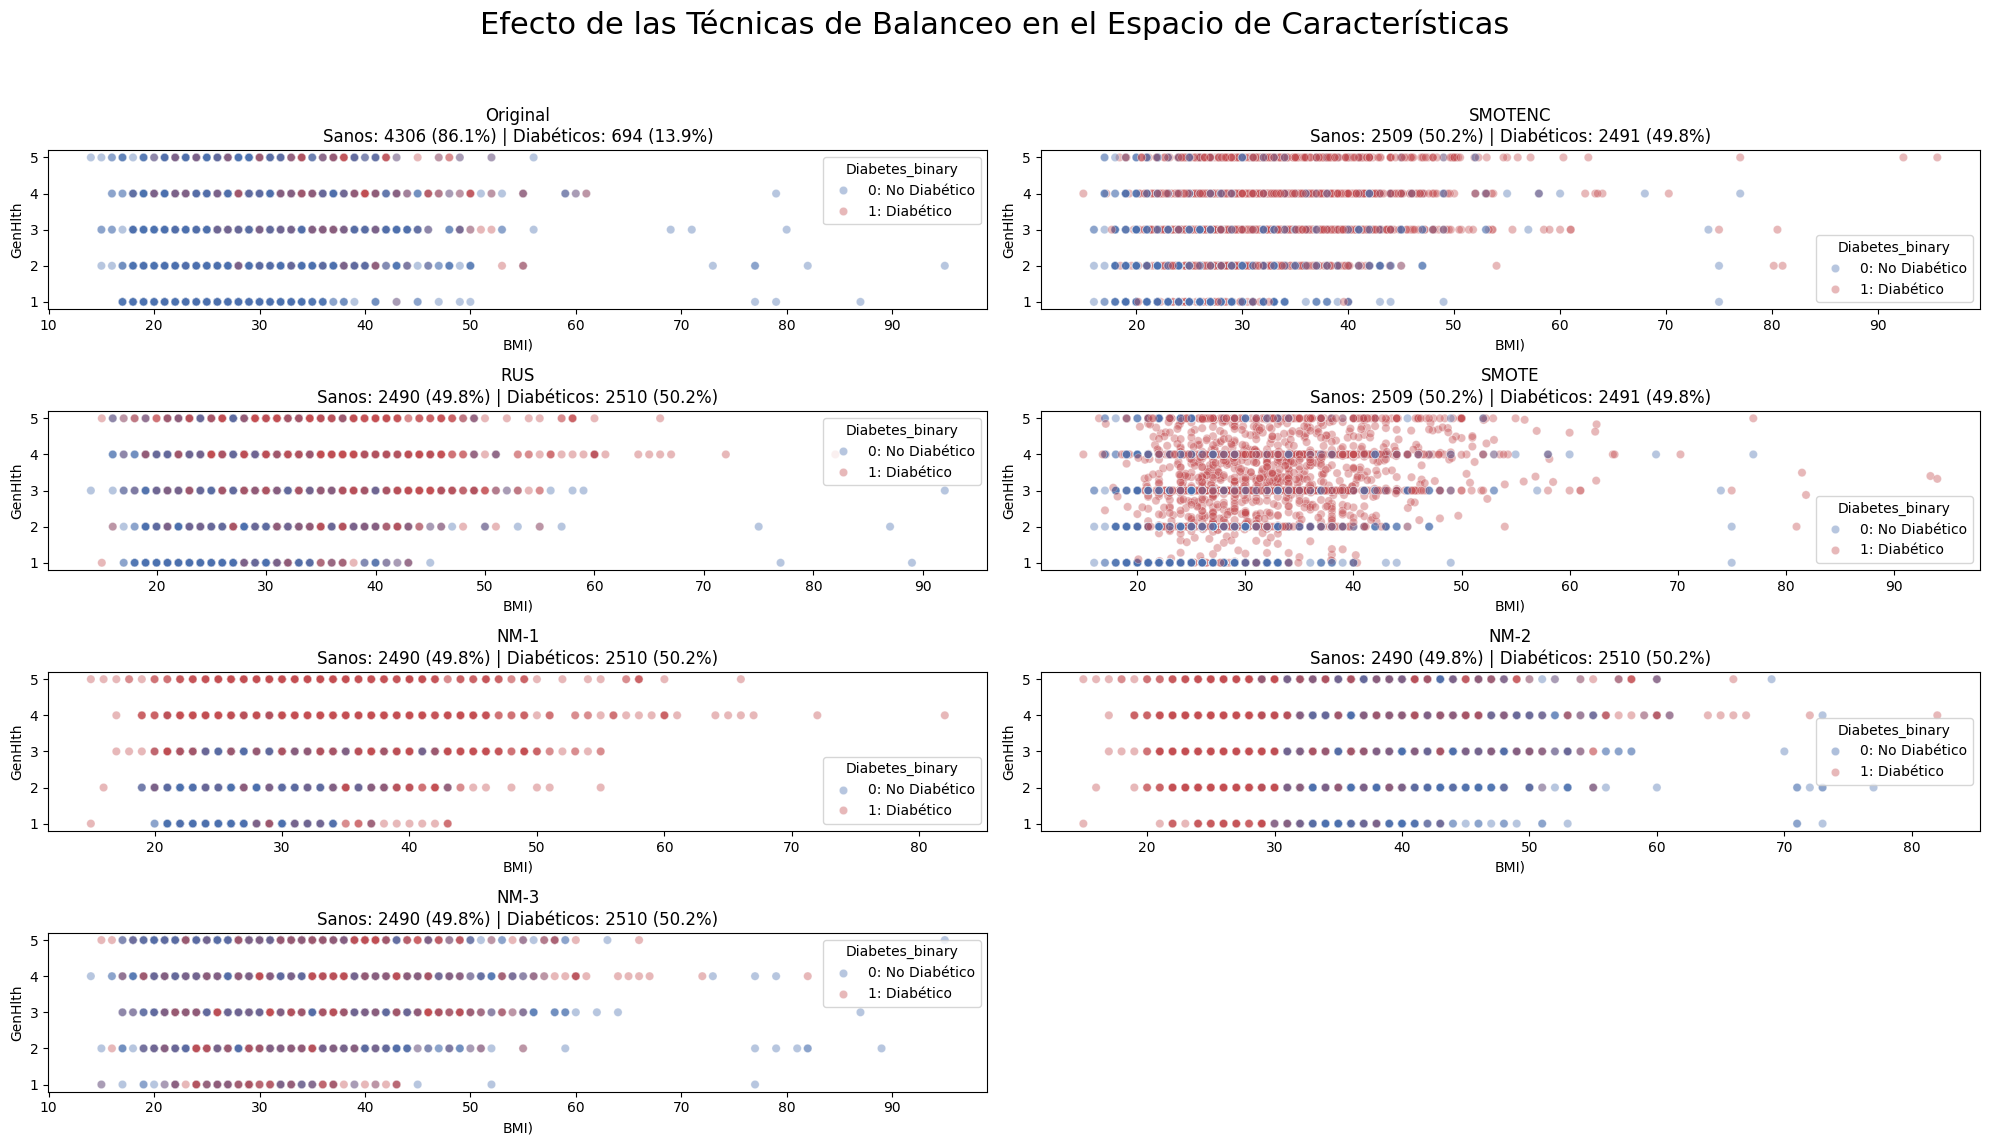

In [ ]:
# Obtener los indices de las variables categóricas y ordinales para SMOTENC, en nuestro dataset son todas menos BMI que es continua
cols_continuas = ['BMI']
indices_categoricos = [X_train.columns.get_loc(col) for col in X_train.columns if col not in cols_continuas]

tecnicas = {
    "Original": None,
    "SMOTENC": SMOTENC(random_state=random_state, categorical_features=indices_categoricos),
    "RUS": RandomUnderSampler(random_state=random_state),
    "SMOTE": SMOTE(random_state=random_state),
    "NM-1": NearMiss(version=1),
    "NM-2": NearMiss(version=2),
    "NM-3": NearMiss(version=3)
}

train_sets = {
    'Original': {'X': X_train, 'y': y_train}
}

# Configuración de la gráfica
fig, axes = plt.subplots(4, 2, figsize=(20, 12))  # dibujamos una matriz de 4 filas * 2 columnas para incluir cada gráfica de cada conjunto de datos creado con las técnicas de balanceo
axes = axes.flatten()  # Convertimos la matriz en un array de 8 elementos para recorrerlos con un solo índice.
fig.suptitle('Efecto de las Técnicas de Balanceo en el Espacio de Características', fontsize=22)

# Iteramos y graficamos
for i, (nombre, instancia) in enumerate(tecnicas.items()):
    ax = axes[i]  # Seleccionamos el elemento del array donde se va a dibujar el gráfico
    # Comprobamos si la instancia del conjunto es "None", por que en ese caso es el original y no hay que hacer nada para él.
    if instancia is not None:
        # Aplicamos la técnica sobre el conjunto de datos de entrenamiento..
        # para que no de un problema con SMOTENC que necesita un array de Numpy y no un dataframe de pandas, como hemos configurado que la salida
        # de sckit-learn sea siempre un pandas dataframe, para este momento, lo configuramos para que sea un array de Numpy
        
        if nombre == "SMOTENC": # Cambia a "default" SOLO para esta línea, luego vuelve a "pandas"
            with config_context(transform_output="default"):
                X_res, y_res = instancia.fit_resample(X_train, y_train)
            # Convertimos el resultado de nuevo a un dataframe para que todos los métodos guarden el mismo formato.
            X_res = pd.DataFrame(X_res, columns=X_train.columns)
            y_res = pd.Series(y_res, name=y_train.name)
        else:
            X_res, y_res = instancia.fit_resample(X_train, y_train)  
        # Guardamos el conjunto en el diccionario
        train_sets[nombre] = {'X': X_res, 'y': y_res}
    else:
        # Para el original, tomamos una muestra representativa, pero no guardamos porque lo guardamos  en el histórico antes del bucle for
        X_res = X_train.copy()
        y_res = y_train.copy()

    # Creamos el DF de visualización con un subconjunto de 5000 muestras del total del conjunto para no saturar el gráfico con las 250.000 muestras del original y mapeamos los nombres
    df_visualizacion = X_res.assign(Diabetes_binary = y_res).sample(min(5000, len(X_res)), random_state=random_state)
    # Mapeamos de 0/1 a texto para clarificar la gráfica, ya que si no, la leyenda no se muestra de forma visualmente clara si no con 0.0 y 1.0
    df_visualizacion['Diabetes_binary'] = df_visualizacion['Diabetes_binary'].map({0.0: '0: No Diabético', 1.0: '1: Diabético'})
    # Graficamos en 2D, escogemos dos de las variables que más importancia tenían sobre la variable objetivo BMI y GenHlth
    sns.scatterplot(
        data=df_visualizacion, 
        x='BMI', 
        y='GenHlth', 
        hue='Diabetes_binary', 
        alpha=0.4,
        palette={'0: No Diabético': '#4c72b0', '1: Diabético': '#c44e52'}, 
        ax=ax
    )

    #Contamos las etiquetass para indicar en el título de la gráfica el número de etiquetas de cada clase y comprobar el balanceo
    num_sanos = (df_visualizacion['Diabetes_binary'] == '0: No Diabético').sum()
    num_diabeticos = (df_visualizacion['Diabetes_binary'] == '1: Diabético').sum()
    total_muestra = len(df_visualizacion)
    # Calculamos porcentajes
    porcentaje_sanos = (num_sanos / total_muestra) * 100
    porcentaje_diab = (num_diabeticos / total_muestra) * 100

    ax.set_title(
        f"{nombre}\n"
        f"Sanos: {num_sanos} ({porcentaje_sanos:.1f}%) | "
        f"Diabéticos: {num_diabeticos} ({porcentaje_diab:.1f}%)",
        fontsize=12
    )
    ax.set_xlabel('BMI)')
    ax.set_ylabel('GenHlth')

# Eliminamos los axes que no tengan datos para que no pinte una gráfica vacía.
for ax in axes:
    if not ax.has_data():
       plt.delaxes(ax)      
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()




In [54]:
# Vamos a guardar los conjuntos de datos procesados
columnas = X_train.columns
for nombre, datos in train_sets.items():
    X_temp = datos.get('X')
    y_temp = datos.get('y')
    # Limpiamos el nombre para el archivo a guardar (quitamos espacios y paréntesis)
    nombre_archivo = nombre.replace(" ", "_").replace("(", "").replace(")", "").lower()
        
    # Unimos X e y para tener el dataset completo, verificamos si ya tenemos un dataframe o un array de numpy (dependiendo de lo que devuelva la técnica del 
    # tratamiento de desbalanceo)
    if isinstance(X_temp, np.ndarray):
        df_temp = pd.DataFrame(X_temp, columns=columnas)
    else:
        df_temp = X_temp.copy()
    y_values = y_temp.values if hasattr(y_temp, 'values') else y_temp
    df_temp['Diabetes_binary'] = y_values
    
    # Guardamos en formato CSV
    df_temp.to_csv(f'data/data_processed/{nombre_archivo}.csv', index=False)
    
    print(f"Guardado archivo: {nombre}")

Guardado archivo: Original
Guardado archivo: SMOTENC
Guardado archivo: RUS
Guardado archivo: SMOTE
Guardado archivo: NM-1
Guardado archivo: NM-2
Guardado archivo: NM-3


**Conclusiones sobre las gráficas** 

En las gráficas podemos observar el salto que hay entre la distribución en clases del dataset original y una vez aplicadas las técnicas de balanceo sobre el mismo, se consigue que haya una representación similar de ambos grupos en el dataset, excepto en las técnicas SMOTE y SMOTENC, en el resto de técnicas el porcentaje de encuestados diabéticos en minimamente mayor, lo contrarío a lo que ocurre en la distribución del dataset original.

Se observa una estructura de franjas horizontales en la visualización de `GenHlth` debido a su naturaleza ordinal original, recordemos que los valores que contenía originalmente eran 1, 2, 3, 4 y 5. En la técnicas que no generan muestras sintéticas, si no que reducen el conjunto original para igualar las dos clases, se aprecia que se sigue la misma distribución de valores, pero en la gráfica en la que se muestran los datos generados con **`SMOTE`** para balancear las muestras, al utilizar como algoritmo vecinos cercanos (k-NN), genera instancias sintéticas que ocupan el espacio entre las categorías originales, es decir, al "inventar" encuestados diabéticos para balancer el dataset, genera valores de GenHlth y BMI que no existían en el dataset original, no respetando los valores que puede contener dicha variable, en cambio con **`SMOTENC`**, podemos ver que si se han respetado el conjunto de valores que puede contener la variable `GenHlth`. Por este motivo, **`SMOTE`** debería descartarse como técnica para el tratamiento del desbalance de la variable objetivo, ya que no respeta los posibles valores de las variables ordinales.

En la gráfica con la técnica **`Random Under-Sampling (RUS)`**, podemos observar que hay muchos menos instancias de encuestados sanos, pero se mantiene su representación en todas las barras de GenHlth y cubren todo el rango de BMI también. RUS, lo que hace es borrar encuestados sanos al azar, sin asumir nada ni calcular distancias, por lo que es muy posible que se hayan eliminado casos que estén cerca de la frontera de decisión vitales para la robustez del modelo.


En cuanto a las distintas versiones de **`NearMiss`**, podemos observar diferencias entre ellos:
* `NM-1`: se han seleccionado instancias de encuestados sanos que estén cerca de pacientes diagnosticados, se puede ver con repecto a la gráfica del dataset original, que en un espacio donde antes había muchos encuestados sanos, ya no está así, esto es porque NM-1 solo se queda con aquellos encuestados sanos que estén cerca de los que no lo están. Llama la atención la escasez de encuestados sanos en las barras del 4 y del 5, esto es porque al tener que eliminar muchos encuentados sanos para balancear el dataset, detecta que hay muchos más encuestados sanos cerca de encuestados diabéticos en otros valores de las variables, y se queda con esos para el conjunto final.
* `NM-2`: se observa que las instancias asociadas a los encuestados sanos, se agrupan en el centro y se rodean de instancias de encuestados diabéticos, esto es por que NM-2, busca las instancias de los encuestados sanos en los que la distancia media a los encuestados diabéticos más lejanos, sea la menor. Llama la atención que con esta técnica, en la muestra graficada, no ha desaparecido la representación de los dos grupos en todas las barras como ha pasado con NM-1, la explicación es que el promedio de sus distancias a los diabéticos más lejanos no es tan grande, por los que NM-2 no los elimina del dataset que está creando. 
* `NM-3`: parece que hay una representación de las instancias más dispersa, esta versión de la técnica lo que hace es para cada encuestad diabético, selecciona los vecinos sanos más cercanos. En esta versión vemos que hay una representación de encuestados sanos y diabéticos en todas las barras, algo que nos garantizaría un aprendizaje más robusto y menos sesgado del modelo.


En cualquier caso, la eliminación de datos del conjunto original, representa pérdida de representativad de muchas muestras de pacientes sanos que puede llevar al modelo una pérdida de robustez en la fase de inferencia, al existir la posibilida de recibir combinaciones de valores de pacientes sanos que no haya podido aprender en la fase de entrenamiento.

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id = "preprocesamiento" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: rgb(18, 223, 127); font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
            4.2. Pipeline de preprocesamiento
        </h3>
    </div>
</div>

Para cada lista de atributos, definimos un `Pipeline` de `scikit-learn` que contenga *toda* la secuencia de pasos para tratar el conjunto de variables que forman la lista..

Usaremos **`make_pipeline`** por simplicidad. Con esta función no tenemos  que nombrar cada paso y hace el código más limpio.

#### Definir las listas de variables
Creamos listas que agrupen las variables por el tipo exacto de preprocesamiento que van a recibir. 
* `features_binary`: variables categóricas con un orden binario compartido 0 y 1.
* `feature_standarScaler`: variables que necesitan que sus rangos se igualen antes de que el modelo aprenda de ellas pero que no tienen valores extremos.
* `feature_robustScaler`: variables que necesita que sus rangos se igualen antes de que el modelo aprenda de ellas que tienen valores extremos.

Se toma la decisión de eliminar la variable `AnyHealthCare` y `CholCheck` del conjunto de variables predictoras del dataset de entrenamiento puesto que su correlación con la variable objetivo es prácticamente nula, porque no hay representación suficiendo de personas sin seguro de salud o sin haber chequeado el colesterol en los últimos 5 años, lo que impide que esta variable sea informativa en la predicción, esto nos  implica que la variable tiene una varianza bajísima. Los modelos aprenden de la diferencia; si casi no hay diferencia entre los sujetos en esa variable, el modelo no puede extraer una regla útil.

Con respecto a `BMI`, tiene valores extremos como 98, se le va a poner un techo de 60 porque sigue siendo obesidad mórbida y no es valor tan extremo con 98 que es algo inusual, por lo que evitamos de esta forma que el modelo cree reglas específicas con valores que no suelen ser frecuentes.

<div class="alert alert-block alert-warning">
Aunque nuestro análisis en <tt>X_train</tt> no haya detectado valores perdidos en todos los atributos, es una <b>buena práctica de producción</b> incluir un imputador en <i>todos</i> los <tt>Pipeline</tt>. Esto hace que sea robusto. Si en el futuro recibimos un nuevo conjunto de datos de entrada (para predicción) que <i>sí</i> contenga un valor nulo en algún atributo, nuestro <tt>Pipeline</tt> no fallará; simplemente lo imputará y continuará el proceso.
</div>

In [19]:
# Esta función limitará el valor máximo de BMI a 60, se aplicará dentro del transformer de la variable.
def bmi_clipper_function(X):
    return np.clip(X, a_min=None, a_max=60)

In [20]:
# Eliminar variables sin varianza útil AnyHealthcare y CholCheck
drop_columns = ['AnyHealthcare', 'CholCheck']

# Creamos listas que agrupen las variables por el tipo exacto de preprocesamiento que van a recibir. 
# Identificamos las columnas que solo tienen 0.0 y 1.0 y no incluimos en la lista ni AnyHealthcare, ni CholCheck, lo que hará que
# se eliminen del dataset generado tras el preprocesamiento.
features_binary = [
    col for col in X_train.columns 
    if col not in drop_columns and set(X_train[col].dropna().unique()) == {0.0, 1.0} 
]
feature_standarScaler = ['GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
feature_robustScaler = ['BMI']

# Imprimimos
print(f"Variables binarias (0/1) detectadas: {features_binary}")
print(f"Variables que necesitan escalado standard: {feature_standarScaler}")
print(f"Variables que necesitan escalado robusto: {feature_robustScaler}")


Variables binarias (0/1) detectadas: ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'NoDocbcCost', 'DiffWalk', 'Sex']
Variables que necesitan escalado standard: ['GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
Variables que necesitan escalado robusto: ['BMI']


In [21]:
# Construimos los pipelines de preprocesamiento
# Pipeline de preprocesamiento para variables que necesitan un escalador que trate mejor los outliers

strategy = "median"  # Imputación de valores faltantes por la mediana
imputer = SimpleImputer(strategy=strategy)
transformer = FunctionTransformer(bmi_clipper_function, validate=False)
scaler = RobustScaler()
robust_scaler_transformer = make_pipeline(imputer, transformer, scaler)

# Pipeline de preprocesamiento para variables que necesitan un escalado estandard
strategy = "median"  # Imputación de valores faltantes por la mediana
imputer = SimpleImputer(strategy=strategy)
transformer = PowerTransformer(method="yeo-johnson")
scaler = StandardScaler()
standard_scaler_transformer = make_pipeline(imputer, transformer, scaler)

# Pipeline de preprocesamiento para variables binarias
strategy = "most_frequent"  # Imputación de valores faltantes por la moda
imputer = SimpleImputer(strategy=strategy)
binary_transformer = make_pipeline(imputer)

##### Construir el `ColumnTransformer`

Construimos un único `ColumnTransformer`, para ello, uaremos `make_column_transformer` por su simplicidad.

Añadiremos dos argumentos clave al final:
* `remainder = "drop"`: Esto es crucial **y el valor por defecto**. Le dice al transformador que elimine automáticamente cualquier columna que no hayamos mencionado explícitamente en nuestras listas (así es como nos deshacemos de las columnas que hemos decidido eliminar `'AnyHealthcare', 'CholCheck'`).
* `verbose_feature_names_out = "False"`: Un truco de legibilidad. Evita que `scikit-learn` añada prefijos largos a nuestras nuevas columnas, dándonos nombres limpios.

In [ ]:
# ColumnTransformer único
preprocessor = make_column_transformer(
    # Variables con necesidad de escalado robusto
    (robust_scaler_transformer, feature_robustScaler),
    
    # Variables con necesidad de escalado estandard
    (standard_scaler_transformer, feature_standarScaler),

    # Variables banarias
    (binary_transformer, features_binary),
        
    remainder="drop",  # descartar columnas no especificadas en el preprocesamiento con esto eliminamos las columnas AnyHealthcare y CholCheck
    verbose_feature_names_out=False  # le decimos al transformer que no cambie el nombre de las columnas para que en la visualización tengamos los nombres originales
)



##### Visualización del resultado

El `preprocessor` que acabamos de crear es solo el plan que se debe seguir en el entrenamiento del modelo.

Para ver qué produce, vamos a hacer exactamente lo que el `Pipeline` final hará internamente: llamaremos a `.fit_transform()` **solo sobre `X_train`**.

Esto hará dos cosas:
1.  **`fit` (Aprender):** Aprenderá las medianas, las modas, las medias y desviaciones estándar, y los parámetros de la transformación de potencia, *todo* desde `X_train`.
2.  **`transform` (Aplicar):** Aplicará todas las transformaciones.

El resultado será un conjunto de datos con el que los modelos seleccionados aprenderán las combinaciones de los datos de entrada para inferir a qué clase pertenecen.

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id = "preprocesamiento" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: #00b31bff; font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
            5. Entrenamiento varios modelos
        </h3>
    </div>
</div>
El dataset es un dataset con muchas variables binarias y ordinales, y solo una variable continua, se trata de un dataset desbalanceado y con sesgo de representación en grupos de estrato social y económico bajo, además no existen relaciones lineales entre las variables, por lo que es mejor que descartamos modelos lineales puros o que dependan de una distribución normal o que sufran con variables binarias (SVM Linear, KNN, Regresión logística), por lo que los mejores modelos para nuestro dataset serían: <br>

* `XGBoost / LightGBM / CatBoost`: son modelos Gradient Boosting basados en árboles, que manejan bien variables binarias y capturan realaciones no lineales entre variables, funcionan bien con pocas variables numéricas y permiten balanceo de clases, fairness-aware y son robustos a outliers, permiten ajuste del umbral de decisión. No son fairness-aware  por si mismos, pero pueden integrarse con reweighing en prepocesado y post procesado con Calibrated Equalized Odds. <br>
* `Random Forest`: es bueno con variables binarias, con la no linealidad y cuando hay ruido, trata bien el desbalanceo cuando usa  class_weight='balanced_subsample', aunque no es tan preciso como los algoritmos de Gradient Boosting. Al usar el hiperparámetro 'class_weight', se consigue que el algoritmo calcule en cada árbol los pesos de clase basados en la distribución de clases dentro de su propia muestra bootstrap, no en el dataset completo (esto sería con class_weight='balanced'):
    - Si una clase aparece poco en la muestra de un árbol, ese árbol le dará más peso.
    - Si aparece mucho, le dará menos peso.<br>
* `Regresión logística (con regularización L1 y L2)`: es un modelo muy interpretable, fácil de optimizar y de combinar con técnicas de fairness-aware. también cuenta con un hiperpárametro que le ayuda tratar con el desbalanceo de la clase: class_weight='balanced'. Lo que hace es:
    - Calcular pesos inversamente proporcionales a la frecuencia de cada clase.
    - La clase minoritaria recibe más peso.
    - La clase mayoritaria recibe menos peso.
Esto ayuda a que el modelo deje de ignorar la clase minoritaria, mejore su recall y reduzca el sesgo hacia la clase mayoritaria.<br>
* `Ridge Classifier`: aunque es un modelo lineal y que convierte el problema de clasifición en un problema de regresión lineal minimizando la pérdida cuadrática, y donde la salida no es una probabilidad si la clase a la que predicha. Aplica penalización L2, que tiende a repartir el peso entre variables correlacionadas, lo que puede producir modelos más estables y menos sensibles a pequeñas variaciones en los datos. Además, tiene parámetro para tratar el desbalanceo de clases, class_weight='balanced', que evita que el modelo se incline hacia la clase dominante, dándole más peso a la clase minoritaria. Es un modelo rápido y al ser lineal, más fácilmente interpretable que el resto<br>

Cada uno de los modelos será entrenado mediante un proceso de RandomSearchCV con validación cruzada de 5 folds sobre cada uno de los conjuntos de datos obtenidos en después de aplicar las técnicas para tratar el desbalanceo, excepto para SMOTE, que se descarta por la generación de instancias sintéticas con valores fuera de los valores permitidos en las variables ordinales. Un validación cruzada implica que cada configuración de parámetros será probada y validada 7 veces sobre subconjuntos distintos de datos, asegurando que la capacidad predictiva del modelo es generalizable y robusta.

Utilizamos RandomizedSearchCV disminuimos el número de combinaciones a probar del espacio de parámetros, ya que solo prueba n combinaciones aleatorias, a diferencia de GridSearchCV que las probaría todas. Con 7 modelos y 6 conjuntos de datos, podríamos estar hablando de miles de combinaciones para entrenar, en cambio con RandomizedSearchCV, reducimos ese número dependiendo del parámetro n-iter que le indiquemos.<br>
RandomizedSearchCV es además permite usar distribuciones continuas en lugar de listas discretas, lo que explora mejor el espacio:<br>
    params = {<br>
        'learning_rate': uniform(0.01, 0.3),  # cualquier valor entre 0.01 y 0.31<br>
        'max_depth': randint(3, 10),          # entero entre 3 y 9<br>
        'subsample': uniform(0.6, 0.4)        # cualquier valor entre 0.6 y 1.0<br>
    }<br>

* `randint`: Elige un número entero al azar (ideal para número de árboles o profundidad).
* `uniform`: Elige un decimal al azar en un rango lineal (ideal para porcentajes como subsample).
* `loguniform`: Elige un decimal en escala logarítmica (ideal para C o learning_rate, donde hay mucha diferencia de impacto entre 0.01 y 0.1).

Como XGBoost no tiene un hiperparámetro que balancee los pesos de forma automática, vamos a incluir en el bucle una comprobación para que cuando el modelo sea XGboost adapte el parámetro scale_pos_weight, al valor que le corresponda.

 BASELINE (DUMMY MODEL) - Average Precision (AP) : 0.1396


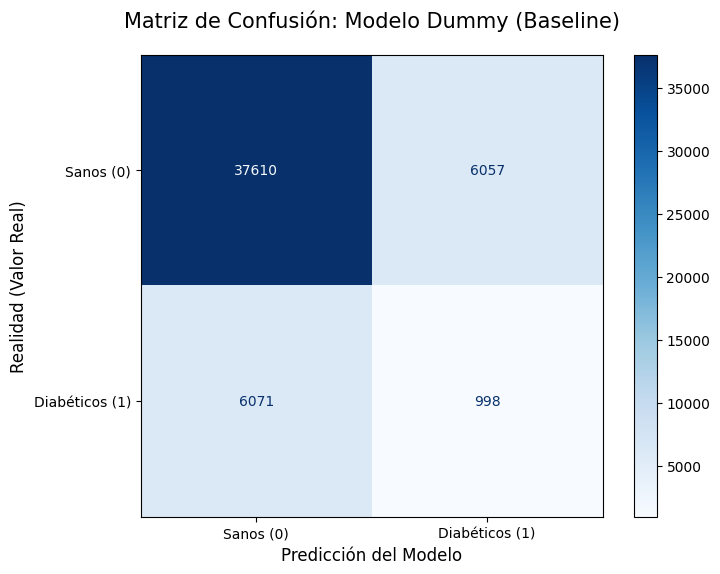

['model/dummy_classifier_baseline.pkl']

In [67]:
# Lo primero que vamos a hacer es entrenar nuestros conjuntos con un modelo Dummy  que no aprende.
# Creamos el modelo Dummy
# Utilizamos como estrategia 'stratified' para generar predicciones manteniendo la distribución de clases del entrenamiento
dummy = DummyClassifier(strategy='stratified', random_state=random_state)

# El modelo Dummy no necesita preprocesamiento complejo, pero lo pasamos por el pipeline
# para ser consistentes con el resto de las pruebas que vamos a hacer 
pipeline_dummy = make_pipeline(preprocessor, dummy)

# Entrenamos el preprocesor y el modelo
pipeline_dummy.fit(X_train, y_train)

# Evaluamos
y_dummy = pipeline_dummy.predict(X_test)
ap_dummy = average_precision_score(y_test, y_dummy)
print(f" BASELINE (DUMMY MODEL) - Average Precision (AP) : {ap_dummy:.4f}")

# Cálculo de la Matriz de Confusión
cm_dummy = confusion_matrix(y_test, y_dummy)
fig, ax = plt.subplots(figsize=(8, 6))

# Configuramos el display
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dummy, display_labels=['Sanos (0)', 'Diabéticos (1)'])
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

# Titulo
plt.title('Matriz de Confusión: Modelo Dummy (Baseline)', fontsize=15, pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Valor Real)', fontsize=12)

# Guardar la imagen
plt.show()

# Guardamos el modelo dummy
joblib.dump(pipeline_dummy, 'model/dummy_classifier_baseline.pkl')




Entrenando: Logistic Regression con dataset: Original (Desbalanceado)
Finalizado Logistic Regression | AP: 0.4124 | Train: 1m 0s | Pred: 0.0064s


Entrenando: Ridge Classifier con dataset: Original (Desbalanceado)
Finalizado Ridge Classifier | AP: 0.4129 | Train: 0m 0s | Pred: 0.0060s


Entrenando: XGBoost con dataset: Original (Desbalanceado)
Finalizado XGBoost | AP: 0.4361 | Train: 3m 0s | Pred: 0.0962s


Entrenando: Light Gradient Boosting Machine con dataset: Original (Desbalanceado)
Finalizado Light Gradient Boosting Machine | AP: 0.4336 | Train: 26m 0s | Pred: 0.1683s


Entrenando: CatBoost Classifier con dataset: Original (Desbalanceado)
Finalizado CatBoost Classifier | AP: 0.4373 | Train: 38m 0s | Pred: 0.0371s


Entrenando: BalancedRandomForestClassifier con dataset: Original (Desbalanceado)
Finalizado BalancedRandomForestClassifier | AP: 0.4297 | Train: 21m 2s | Pred: 2.1140s


Entrenando: Random Forest Classifier con dataset: Original (Desbalanceado)
Finalizado Random Fore

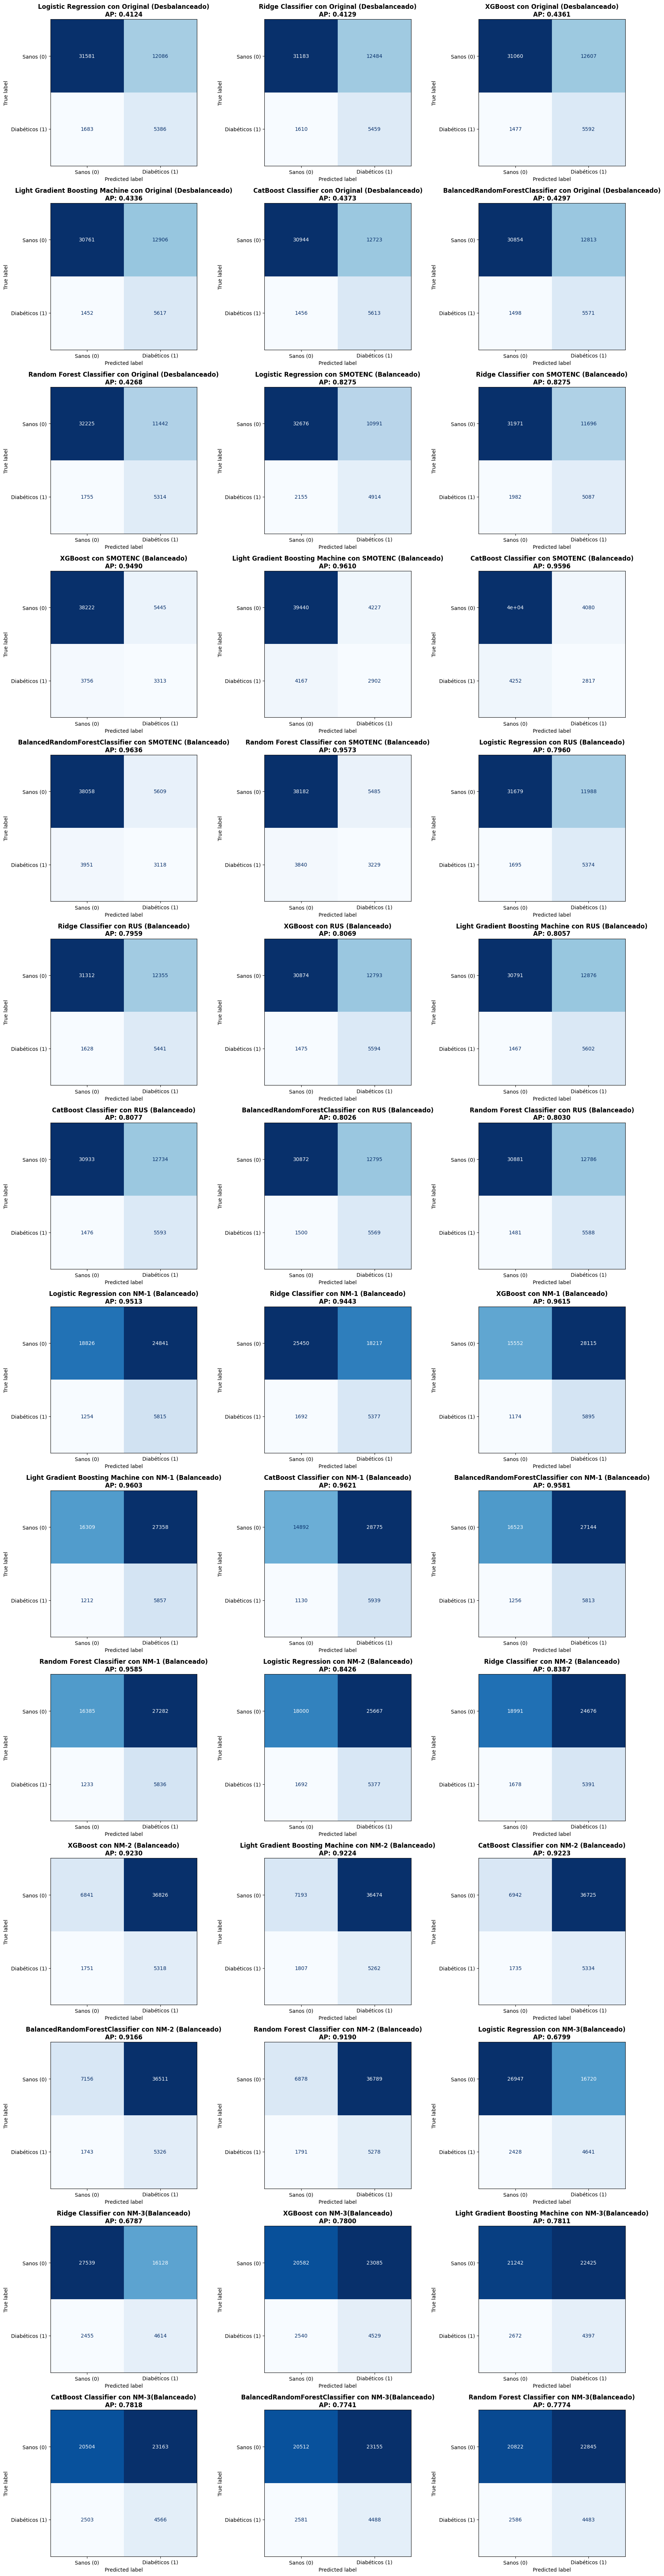

In [61]:

# Diccionario para guardar los modelos y resultados
mejores_modelos = {}

# Los conjuntos de entrenamiento, aún sin preprocesar se encuentran en las variable train_set obtenida del paso anterior, vamos a
# tratar entrenar cada modelo con cada uno de los algotimos seleccionados
datasets_a_evaluar = {
    "Original (Desbalanceado)": (X_train, y_train),
    "SMOTENC (Balanceado)": (train_sets['SMOTENC']['X'], train_sets['SMOTENC']['y']),
    "RUS (Balanceado)": (train_sets['RUS']['X'], train_sets['RUS']['y']),
    "NM-1 (Balanceado)": (train_sets['NM-1']['X'], train_sets['NM-1']['y']),
    "NM-2 (Balanceado)": (train_sets['NM-2']['X'], train_sets['NM-2']['y']),
    "NM-3(Balanceado)": (train_sets['NM-3']['X'], train_sets['NM-3']['y']),
}

# Parametros para cada modelo
param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga'),
        'params': {
            # loguniform ayuda a explorar mejor valores muy pequeños o muy grande
            'C': loguniform(1e-3, 1e2),
            'penalty': ['l1', 'l2']
        }
    },
    'Ridge Classifier': {
        'model': RidgeClassifier(class_weight='balanced'),
        'params': {
            'alpha': loguniform(1e-2, 1e2)
        }
    },
    'XGBoost': {
        'model':  xgb.XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='logloss', objective="binary:logistic"),
        'params': {
            'n_estimators': randint(100, 401),
            'max_depth': randint(3, 9),
            'learning_rate': loguniform(0.01, 0.2),
            # uniform: Elige un decimal al azar en un rango lineal.
            'subsample': uniform(0.6, 0.4)      # uniform(loc, scale) -> de 0.6 a 1.0 (0.6 + 0.4)
        }
    },
    'Light Gradient Boosting Machine': {
        'model': LGBMClassifier(random_state=random_state, is_unbalance=True, verbosity=-1),
        'params': {
            'n_estimators': randint(100, 401),
            'num_leaves': randint(20, 150),
            'learning_rate': loguniform(0.01, 0.2),
            'boosting_type': ['gbdt', 'dart']
        }
    },
    'CatBoost Classifier': {
        'model': CatBoostClassifier(random_state=random_state, auto_class_weights='Balanced', verbose=0),
        'params': {
            'depth': randint(4, 9),
            'learning_rate': loguniform(0.01, 0.2),
            'l2_leaf_reg': randint(1, 10)
        }
    },
    'BalancedRandomForestClassifier': {
        # sampling_strategy='auto' --> Balancea automáticamente la clase mayoritaria en cada árbol, en cada árbol coge todos los pacientes diábeticos y 
        # elije el mismo número de pacientes sanos de forma aleatoria 
        # replacement=False --> submuestreo sin reemplazo, para que no repita la misma instancia de un paciente sano dos veces
        # 'max_features': ['sqrt', 'log2', None] --> define cuántas variables puede "mirar" el árbol cada vez qeu va a tomar la decisión de hacer un split
        # en un nodo. Al meter "None" como posible valor, le decimos que tiene que evaluar en cada nodo del árbol todas las variables que tiene el conjunto 
        # de datos antes de decidir, por dónde cortar, esto implica que cada árbol tiene acceso a toda la información, pero en contrapartida, se pierde 
        # la diversidad, por que podría elegir en cada árbol, las mismas variables y ser árboles casi idénticos. Cuando se usa 'sqrt' (raíz cuadrada) o 
        # 'log2', el algoritmo solo elige un grupo aletario de variables antes de crear una rama y decide por cual cortar de entre ellas, por eejmeplo, 
        # si hay 16 variables y elegimos 'sqrt' como método, el algoritmo solo podrá ver 4 variables aleatorias, lo que le obliba a ser creativo y a que
        # se construyan árboles diversos, además que le obliga a ver posible patrones en otras variables, porque no siempre las variables fuertes 
        # como BMI o MentHlth, pueden estar disponibles en el momento de tomar la decisión. 
        # La diversidad de los árboles es una herramienta fuerte para luchar contra el sobre ajuste.
        'model': BalancedRandomForestClassifier(random_state=random_state,sampling_strategy='auto', replacement=False, verbose=0), 
        'params': {
            'n_estimators': randint(100, 501),
            'max_depth': randint(10, 25),
            'min_samples_split': randint(2, 12),
            'max_features': ['sqrt', 'log2', None]  
        }
    },
    'Random Forest Classifier': {
        'model': RandomForestClassifier(class_weight='balanced_subsample', random_state=random_state),
        'params': {
            # randint: Elige un número entero al azar
            'n_estimators': randint(100, 501),
            'max_depth': randint(5, 25),
            'min_samples_split': randint(2, 12),
             'max_features': ['sqrt', 'log2', None]
        }
    },                                   
}

# Validación cruzada estratificada con 5 folds (sobre el conjunto de entrenamiento)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Lista para almacenar los mejores modelos y sus métricas
mejores_modelos_resultados = []

for nombre_ds, (X_tr, y_tr) in datasets_a_evaluar.items():
    # APLICAMOS PREPROCESSOR
    # Ajustamos el preprocesador al dataset de entrenamiento actual
    X_tr_procesado = preprocessor.fit_transform(X_tr)

    # aplicamos el transform del preprocesor al conjunto de test (usamos el X_test puro que separamos al principio)
    X_te_procesado = preprocessor.transform(X_test) 
    for nombre_modelo, config in param_grids.items():
        print(f"\n" + "="*50)
        print(f"\nEntrenando: {nombre_modelo} con dataset: {nombre_ds}")
        print("="*50)
        # Creamos el RandomizedSearchCV
        # 'n_iter=25' es un buen equilibrio entre tiempo y calidad
        # 'scoring' puede ser 'average_precision' o 'f1'
        randomSearch = RandomizedSearchCV(
            estimator=config['model'],
            param_distributions=config['params'],
            n_iter=25, 
            scoring='average_precision', 
            cv=cv,
            verbose=0,
            n_jobs=-1,
            random_state=random_state
        )
        if nombre_modelo == 'XGBoost' :
           # Calculamos el ratio de desbalanceo original
            ratio_peso = y_tr.value_counts()[0] / y_tr.value_counts()[1]    
            randomSearch.estimator.set_params(scale_pos_weight=ratio_peso)

        # vamos a calcular el tiempo que tarda en entrenar para tenerlo como una métrica de coste computacional
        inicio = time.time()
        # Ajustamos el modelo al dataset (X_tr_procesado, y_tr)
        randomSearch.fit(X_tr_procesado, y_tr)
        fin = time.time()
        training_time = fin - inicio   

        # Evaluamos al mejor modelo de cada algoritmo usando los datos de TEST que tenemos guardados
        mejor_modelo = randomSearch.best_estimator_

        # Extraemos los parámetros del modelo ganador para añdirle el ratio de peso usado en el caso de que se trate de XGBoost
        mejores_parametros = randomSearch.best_params_.copy()
        if nombre_modelo == 'XGBoost':
            # Sacamos el peso exacto que tiene el modelo final
            peso_usado = mejor_modelo.get_params().get('scale_pos_weight', 'No definido')
            mejores_parametros['scale_pos_weight (fijo)'] = peso_usado
        inicio = time.time()
        y_pred_best_model = mejor_modelo.predict(X_te_procesado)
        fin = time.time()
        predict_time = fin - inicio
        cm = confusion_matrix(y_test, y_pred_best_model)
        # Guardamos los resultados (incluyendo el ratio de peso para XGBoost)
        mejores_modelos_resultados.append({
            'Modelo': nombre_modelo,
            'Dataset': nombre_ds,
            'Mejor_Score_AP': randomSearch.best_score_,
            'Mejores_Params': mejores_parametros,
            'Estimator': randomSearch.best_estimator_,
            'ConfussionMatrix': cm,
            'Training_time': training_time,
            'predict_time': predict_time
        })
        training_minute = training_time // 60
        training_seconds = predict_time % 60
        print(f"Finalizado {nombre_modelo} | AP: {randomSearch.best_score_:.4f} | Train: {int(training_minute)}m {int(training_seconds)}s | Pred: {predict_time:.4f}s")
   

# Convertimos a DataFrame para comparar fácilmente
df_comparativa = pd.DataFrame(mejores_modelos_resultados).sort_values(by='Mejor_Score_AP', ascending=False)

tabla_resumen = df_comparativa.pivot(index='Modelo', columns='Dataset', values='Mejor_Score_AP')
print("\nResumen de Average Precision (Validación Cruzada):")
print(tabla_resumen.sort_values(by='Original (Desbalanceado)', ascending=False))

# Configuración del grid dinámica, depende del número de modelos, como hemos variado durante las pruebas,
# hemos visto como hacerlo dinámico con respecto a la lista de resultados.
# Obtenemos el tamaño de la lista de mejores modelos
n_modelos = len(mejores_modelos_resultados)
cols = 3  # Queremos 3 matrices por fila
rows = math.ceil(n_modelos / cols)  # Tantas filas como número de modelos entrenamos entre número de matrices por fila

# Definir la figura, le asignamos el alto a la figura de forma dinámica, dependiendo del número de filas que 
# necesitamos para pintar todas las cm de todos los modelos
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))    # 18 pulgadas de ancho y 5 pulgadas de altura por cada fila que vamos a pintar
axes = axes.flatten()  # Aplanamos para iterar con un solo índice [i]

print("\nGenerando matrices de confusión...")

# Bucle de dibujado
for i, res in enumerate(mejores_modelos_resultados):
    cm = res['ConfussionMatrix']
    nombre = res['Modelo']
    dataset = res['Dataset']
    ap_score = res['Mejor_Score_AP']
    
      
    # Dibujar en el subplot correspondiente
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=['Sanos (0)', 'Diabéticos (1)']
    )
    
    # Personalización del estilo
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"{nombre} con {dataset}\nAP: {ap_score:.4f}", fontsize=12, fontweight='bold')
    axes[i].grid(False) # Quitar líneas de grid sobre la matriz

# Limpieza: si sobran huecos en el grid, los borramos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar espaciado para que no se pisen los títulos
plt.tight_layout()
plt.show()


In [64]:
from sklearn.pipeline import clone

for resultado in mejores_modelos_resultados:
    nombre_mod = resultado['Modelo']
    nombre_ds = resultado['Dataset']
    
    # Recuperamos los datos de entrenamiento específicos para este modelo y entrenamos el preprocessor para este conjunto de datos
    X_train_especifico, y_train_especifico = datasets_a_evaluar[nombre_ds]
        
    # Creamos el Pipeline uniendo el preprocesador limpio y el mejor estimador encontrado
    pipeline_individual = make_pipeline(preprocessor, resultado['Estimator'])
    
    # ENTRENAMIENTO DEL PIPELINE COMPLETO
    # Aquí el preprocessor aprende las estadísticas de ESTE dataset específico
    # y el modelo se sincroniza con él.
    print(f"Sincronizando Pipeline: {nombre_mod} - {nombre_ds}...")
    pipeline_individual.fit(X_train_especifico, y_train_especifico)
    
    # Guardado
    nombre_archivo = f"{nombre_mod.lower()}_{nombre_ds.replace(' ', '_').lower()}.pkl"
    joblib.dump(pipeline_individual, f'model/{nombre_archivo}', compress=9)
    
    print(f"Guardado con éxito: {nombre_archivo}")
    

Sincronizando Pipeline: Logistic Regression - Original (Desbalanceado)...
Guardado con éxito: logistic regression_original_(desbalanceado).pkl
Sincronizando Pipeline: Ridge Classifier - Original (Desbalanceado)...
Guardado con éxito: ridge classifier_original_(desbalanceado).pkl
Sincronizando Pipeline: XGBoost - Original (Desbalanceado)...
Guardado con éxito: xgboost_original_(desbalanceado).pkl
Sincronizando Pipeline: Light Gradient Boosting Machine - Original (Desbalanceado)...
Guardado con éxito: light gradient boosting machine_original_(desbalanceado).pkl
Sincronizando Pipeline: CatBoost Classifier - Original (Desbalanceado)...
Guardado con éxito: catboost classifier_original_(desbalanceado).pkl
Sincronizando Pipeline: BalancedRandomForestClassifier - Original (Desbalanceado)...
Guardado con éxito: balancedrandomforestclassifier_original_(desbalanceado).pkl
Sincronizando Pipeline: Random Forest Classifier - Original (Desbalanceado)...
Guardado con éxito: random forest classifier_or

Aunque los modelos de ensamblado logran un rendimiento superior, el Ridge Classifier demuestra una eficiencia computacional extraordinaria, resolviendo el problema de optimización en menos de un segundo con una degradación de la métrica Average Precision muy contenida. Esto lo convierte en un candidato ideal si existieran restricciones extremas de hardware y si su su capacidad de generalización demuestran que es un modelo robusto.

La evaluación empírica revela el clásico 'trade-off' (compromiso) entre capacidad predictiva y coste computacional. Mientras que los modelos lineales (Ridge) ofrecen un entrenamiento casi instantáneo, arquitecturas de ensamblado avanzado como XGBoost logran incrementar notablemente la métrica Average Precision (0.4361), asumiendo un coste de entrenamiento superior (4 minutos). No obstante, el tiempo de inferencia de XGBoost (0.11s) certifica que, una vez desplegado en producción, el modelo cumple sobradamente con los requisitos de latencia para sistemas de apoyo al diagnóstico clínico en tiempo real.

De forma clara en los resultados anteriores vemos que aúnque la métrica de Average Precision es superior en entrenamiento para los modelos con el conjunto de datos de SMOTENC, al pasarlos a evalución se demuestra que lo que ha hecho el modelo es aprender patrones sintéticos que no se dan realmente en los datos, por eso falla de forma clara al predicir sobre el conjunto de test, detectando muchos menos encuestados enfermos que los modelos que lo hacen con el dataset original o con dataset sin muestras generadas de forma sintética, teniendo un claro problema de overfitting.

Los modelos con datos balanceados tienen una métrica de Average Precision mucho mayor que los modelos con el conjunto de datos original, esto es debido a que la métrica Average Precision (el área bajo la curva Precision-Recall) es extremadamente sensible al balance de clases. En el dataset Original, si los diabéticos eran el 14% de los encuestados, un modelo que predijera al azar tendría un AP de 0.14. Por tanto, obtener un 0.43 es un resultado bastante bueno, porque está muy por encima de su 'línea base' (0.14).. En los dataset balanceados, el cojunto de encuestados diabéticos, es ahora del 50%, por lo que si ahora el modelo tira una moneda al aire, tiene un AP del 0,5, lo que nos indica que la linea base ya ha subido artificialmente, por lo que no podemos comparar directamente el AP del conjunto original desbalanceado como el AP de los conjuntos balanceados, sin tener en cuenta los resultados en tiempo de evaluación sobre el conjunto de test.

Al evaluar las matrices de confusión podemos ver que los modelos entrenados con el conjunto de datos original predicen mejor en test los encuestados diabéticos y generan menos falsas alarmas al predecir encuestados sanos como diabéticos, lo que demuestra que son modelos más robustos que los entrenados con datos sintéticos como los generados por SMOTENC o los entrenados con conjuntos de datos balanceados eliminando datos de encuestados sanos como NearMiss en cualquiera de sus versiones.

Por ejemplo NM-1 con CatBoost, tiene la mejor tasa predicción de encuestados diabéticos, pero si miramos la celda de Falsos Positivos, es decir, pacientes sanos que dice que son diabéticos, hay 28.775 falsos positivos, es decir, que de cada 100 personas que el modelo etiqueta como diabéticos, 83 están sanas. Y aunque lo cierto es que en un ámbito sanitario lo ideal es tener la mayor sensibilidad posible sobre la clase que representa los pacientes enfermos, tampoco queremos colapsar el sistema pidiendo pruebas a personas que realmente están sanas, porque al final los médicos perderían la confianza en el modelo. Pasa prácticamente lo mismo con el resto de modelos con los dataset tratados con Near Miss en cualquiera de sus tres versiones, incluso en algunos casos, el Recall es más bajo, porque no predicen igual a los encuentados diabéticos.

El conjunto de datos en el que se ha tratado el desbalanceo que mejores resultados podemos observar en las matrices de confusión, es para el conjunto generado con RUS (Random Under-Sampling), por lo que en el siguiente paso, vamos a analizar resumido en una tabla, las métricas de rendimiento que podemos obtener dsed la matriz de confusión para cada uno de los modelos con ambos conjuntos, para poder compararlao de forma más clara, ya que como hemos comentado en el ámbito sanitario, no todos los errores tienen el mismo coste, un falso negativo es mucho más costoso para el sistema y para la persona,  que un falso positivo que se puede resolver posteriormente con algunas pruebas básias, pero si se le dice a una persona enferma que está sana, el coste de este error puede ser muy alto.El objetivo final será hallar el modelo que ofrezca el balance óptimo entre ambos tipos de errores.


In [37]:
# Lista de modelos que vamos a obtener los métricas para los dos conuntos de datos con mejores resultados
finalistas = [
    'Logistic Regression', 
    'Ridge Classifier', 
    'XGBoost', 
    'Light Gradient Boosting Machine', 
    'CatBoost Classifier',
    'BalancedRandomForestClassifier',
    'Random Forest Classifier'
]

resumen_resultados = []
for res in mejores_modelos_resultados:
    # Solo evaluamos los finalistas entrenados con el dataset Original
    if res['Modelo'] in finalistas and res['Dataset'] in ('Original (Desbalanceado)', 'RUS (Balanceado)'):
        # Como ya se ha realizado la predicción con el conjunto de test y los parámetros del mejor modelo obtenidos con RandomSearchCV y se ha guardado la cm
        # en el diccionario, a partir de la misma, obtenemos el cálculo de las métricas de Recall, especificidad y precisión
        cm = res['ConfussionMatrix']
        
        # Cálculos manuales basados en la matriz guardada
        tn, fp, fn, tp = cm.ravel()
        
        recall = tp / (tp + fn)  # De todos los diabéticos reales que hay en el estudio, qué % se detectó?
        especificidad = tn / (tn + fp) # De todas las personas sanas, qué % se detectó?
        precision = tp / (tp + fp)  # De todas las personas predichas como diabéticas, qué % era realmente diabético?
        f1 = 2 * (precision * recall) / (precision + recall)
        resumen_resultados.append({
            'Modelo': res['Modelo'],
            'Dataset': res['Dataset'],
            'Tiempo Entrenamiento (min)':  round(res['Training_time']/60,2),
            'Tiempo Predicción (sg)': round(res['predict_time'],4),
            'Diabéticos Detectados (TP)': tp,
            'Falsos Negativos (FN)': fn,
            'Falsas Alarmas (FP)': fp,
            'Recall (Sensibilidad)': round(recall, 4),
            'Precisión': round(precision, 4),
            'F1-Score': round (f1, 4),
            'AP (CV)': round(res['Mejor_Score_AP'], 4)
        })
df_resumen_final = pd.DataFrame(resumen_resultados).sort_values(by=['Recall (Sensibilidad)', 'Falsas Alarmas (FP)'], ascending=[False, True])
print("📊 COMPARATIVA CLÍNICA FINAL:")
display(df_resumen_final)

📊 COMPARATIVA CLÍNICA FINAL:


,Modelo,Dataset,Tiempo Entrenamiento (min),Tiempo Predicción (sg),Diabéticos Detectados (TP),Falsos Negativos (FN),Falsas Alarmas (FP),Recall (Sensibilidad),Precisión,F1-Score,AP (CV)
3,Light Gradient Boosting Machine,Original (Desbalanceado),36.95,0.1888,5617,1452,12906,0.7946,0.3032,0.4390,0.4336
4,CatBoost Classifier,Original (Desbalanceado),47.74,0.0324,5613,1456,12723,0.7940,0.3061,0.4419,0.4373
10,Light Gradient Boosting Machine,RUS (Balanceado),6.65,0.1166,5602,1467,12876,0.7925,0.3032,0.4386,0.8057
9,XGBoost,RUS (Balanceado),0.99,0.1095,5594,1475,12793,0.7913,0.3042,0.4395,0.8069
11,CatBoost Classifier,RUS (Balanceado),15.90,0.0283,5593,1476,12734,0.7912,0.3052,0.4405,0.8077
2,XGBoost,Original (Desbalanceado),4.45,0.1116,5592,1477,12607,0.7911,0.3073,0.4426,0.4361
13,Random Forest Classifier,RUS (Balanceado),10.13,1.6457,5588,1481,12786,0.7905,0.3041,0.4393,0.8030
5,BalancedRandomForestClassifier,Original (Desbalanceado),23.76,2.3433,5571,1498,12813,0.7881,0.3030,0.4377,0.4297
12,BalancedRandomForestClassifier,RUS (Balanceado),17.39,2.2463,5569,1500,12795,0.7878,0.3033,0.4379,0.8026
1,Ridge Classifier,Original (Desbalanceado),0.15,0.0074,5459,1610,12484,0.7722,0.3042,0.4365,0.4129


Como podemos observar, los modelos ganadores para los dos conjuntos de datos en cuanto a métricas de sensibilidad y precisión, son los modelos boosting, LightGBM, CatBoost y XGBoost, además podemos observar la gran difenrencia de coste computacional que hay entre el conjunto de datos original y el conjunto de datos tratado con RUS:
* `LGBM`: pasa de casi 37 minutos con el dataset original a casi 7 minutos con dataset tratado con RUS, un 82% más rápido.
* `CatBoost`: Pasa de casi 48 minutos con el dataset original a casi 16 minutos, lo que supone una reducción del 66%.
* `XGBoost`: Pasa de 4.45 minutos a casi 1 minuto, en este caso no es una reducción tan llamativa, porque ya de por si XGBoost resulta ser el modelo computacionalmente más competitivo también con el dataset original.

Revisando las métricas de los 3 modelos, no supone en ningún caso una pérdida de Recall o de Precisión llamativa, puesto que estamos hablando de valores para ambas métricas prácticamente iguales en todos lo casos, varíando casi imperceptiblemente.

La incorporación de las métricas de eficiencia a nivel computacional incluyendo los tiempos de entrenamiento y de inferencia (predicción), nos ayuda a resolver el empate técnico que vemos en la capacidad predictiva medida en las métricas tabuladas. Al evaluar la relación entre rendimiento y coste, los modelos XGBoost destacan sobre el resto.

Tenemos XGBoost entrenado sobre el conjunto Original, que se alza como el modelo más equilibrado clínicamente, ya que logra la mayor Precisión (30.73%) y F1-Score (0.4426), conteniendo las falsas alarmas (12.607) y manteniendo una excelente sensibilidad (79.11%), todo ello con un tiempo de entrenamiento sumamente competitivo (4.45 minutos). Por otro lado, si los requisitos del entorno de producción exigieran reentrenamientos en tiempo real o bajo severas limitaciones de hardware, XGBoost combinado con la técnica RUS demuestra ser la alternativa perfecta: logra un rendimiento clínico prácticamente idéntico (Recall de 79.13%) reduciendo el tiempo de entrenamiento a menos de 1 minuto (0.99 min). Ambos modelos validan su viabilidad operativa con tiempos de predicción en el orden de los milisegundos (~0.11s), garantizando una asistencia diagnóstica instantánea para el personal facultativo.

En el siguiente paso, vamos a comparar las gráficas de la Curva ROC y la Curva Precision-Recall (PR) para los dos modelos finalistas XGBoost Original vs XGBoost RUS.

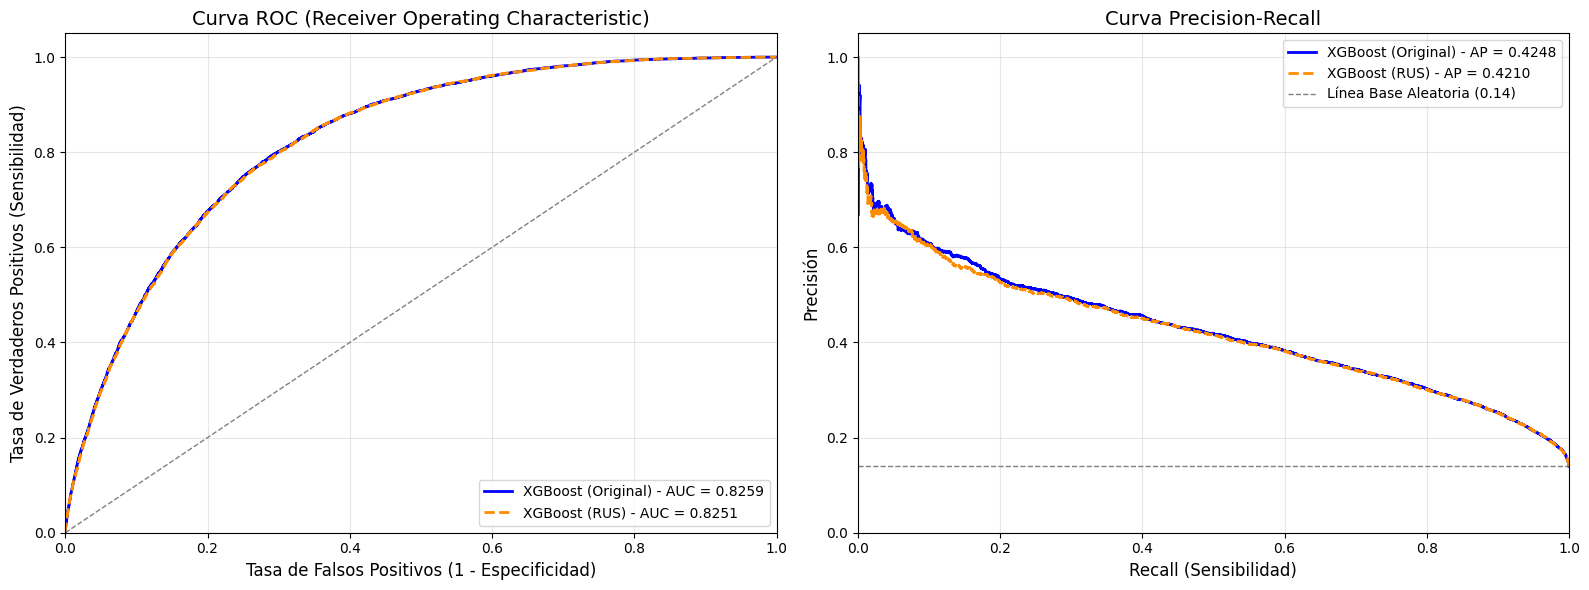

In [39]:
# Extraemos las probabilidades de ambos modelos sobre el X_test

modelo_xgb_original = next(res['Estimator'] for res in mejores_modelos_resultados 
                  if res['Modelo'] == 'XGBoost' and res['Dataset'] == 'Original (Desbalanceado)')
modelo_xgb_rus = next(res['Estimator'] for res in mejores_modelos_resultados 
                  if res['Modelo'] == 'XGBoost' and res['Dataset'] == 'RUS (Balanceado)')

# Volvemos a pasar el preprocesor para obtener los conjuntos de test preprocesados con cada preprocesor entrenadado con cada conjunto de datos.
preprocessor.fit(datasets_a_evaluar['Original (Desbalanceado)'][0]) 
X_test_procesado_ori = preprocessor.transform(X_test)
preprocessor.fit(datasets_a_evaluar['RUS (Balanceado)'][0]) 
X_test_procesado_rus = preprocessor.transform(X_test)

# Obtenemos las probabilidades con cada modelo de las predicciones de clase para cada instancia del conjunto de test para graficar las crubas
y_probs_ori = modelo_xgb_original.predict_proba(X_test_procesado_ori)[:, 1]
y_probs_rus = modelo_xgb_rus.predict_proba(X_test_procesado_rus)[:, 1]

# Cálculos para la Curva ROC
fpr_ori, tpr_ori, _ = roc_curve(y_test, y_probs_ori)
roc_auc_ori = auc(fpr_ori, tpr_ori)

fpr_rus, tpr_rus, _ = roc_curve(y_test, y_probs_rus)
roc_auc_rus = auc(fpr_rus, tpr_rus)

# Cálculos para la Curva Precision-Recall
precision_ori, recall_ori, _ = precision_recall_curve(y_test, y_probs_ori)
pr_auc_ori = average_precision_score(y_test, y_probs_ori)

precision_rus, recall_rus, _ = precision_recall_curve(y_test, y_probs_rus)
pr_auc_rus = average_precision_score(y_test, y_probs_rus)

# Graficamos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# GRÁFICO 1: Curva ROC
ax1.plot(fpr_ori, tpr_ori, color='blue', lw=2, label=f'XGBoost (Original) - AUC = {roc_auc_ori:.4f}')
ax1.plot(fpr_rus, tpr_rus, color='darkorange', lw=2, linestyle='--', label=f'XGBoost (RUS) - AUC = {roc_auc_rus:.4f}')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--') # Línea de modelo aleatorio
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
ax1.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
ax1.set_title('Curva ROC (Receiver Operating Characteristic)', fontsize=14)
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# GRÁFICO 2: Curva Precision-Recall
# La línea base de PR es el % de diabéticos en el dataset, en nuestro caso sería casi el 14%
# sum(y_test) --> Python suma todos los 1s, por lo que está contando cuántos diabéticos hay en el conjunto de test.
linea_base_pr = sum(y_test) / len(y_test)

ax2.plot(recall_ori, precision_ori, color='blue', lw=2, label=f'XGBoost (Original) - AP = {pr_auc_ori:.4f}')
ax2.plot(recall_rus, precision_rus, color='darkorange', lw=2, linestyle='--', label=f'XGBoost (RUS) - AP = {pr_auc_rus:.4f}')
ax2.axhline(y=linea_base_pr, color='gray', lw=1, linestyle='--', label=f'Línea Base Aleatoria ({linea_base_pr:.2f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Sensibilidad)', fontsize=12)
ax2.set_ylabel('Precisión', fontsize=12)
ax2.set_title('Curva Precision-Recall', fontsize=14)
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

En ambos modelos, ambas curvas son practicamente idénticas, la diferencia entre ambos es imperceptible:
* El AUC apenas varía un 0,0008.
* El Average Precision (AP) apenas varía un 0,0038.
Lo que nos confirma que aunque con RUS se han despreciado miles de datos de encuestados sanos, el modelo no ha perdido su capacidad de predicción, y lo ha hecho en mucho menos tiempo que lo que ha tardado con el dataset original.

La curva ROC con un AUC de 0,825, no puede llevarnos a pensar que el modelo es casi perfecto, pero en realidad, presenta un sesgo optimista en este dataset porque el eje de abscisas X (FPR) se calcula dividiendo los Falsos Positivos entre el total de la clase mayoritaria (encuestados sanos). Al existir una desproporción tan grande, el enorme volumen de Verdaderos Negativos diluye el impacto matemático de los Falsos Positivos, empujando la curva hacia la izquierda y simulando un rendimiento excelente. Por el contrario, la métrica de Precisión elimina los Verdaderos Negativos de su ecuación, revelando el verdadero coste de los Falsos Positivos en la práctica clínica.
$$FPR = \frac{FP}{FP + TN}$$
Donde:  
FP = Falsos Positivos (Sanos a los que se asusta diciendo que están enfermos).  
TN = Verdaderos Negativos (Sanos a los que se acierta diciendo que están sanos).  
El denominador es $(FP + TN)$ que representa el total de encuestados sanos del dataset

El análisis gráfico del rendimiento mediante las curvas ROC y Precision-Recall (PR) confirma de forma clara la viabilidad de la técnica de submuestreo aleatorio (RUS).

En la curva ROC, ambos modelos alcanzan un Área Bajo la Curva (AUC) superior a 0.82. Sin embargo, dada la alta prevalencia de la clase negativa (encuestados sanos) típica en problemas de cribado médico, la métrica clave para evaluar la robustez del diagnóstico es la curva Precision-Recall, que saca de la ecuación a los encuestados sanos y solo tiene en cuenta los encuestados enfermos:
$$Precision = \frac{TP}{TP + FP}$$

En este escenario, la línea base marcada en 0.14, correspondiente a la proporción real de diabéticos en el conjunto de test, muestra la dificultad que tieen el problema al tener un conjunto de datos tan desbalanceado.

Ambos modelos logran triplicar el rendimiento de un clasificador aleatorio, alcanzando un Average Precision (AP) en torno a 0.42. La práctica superposición de ambas curvas (AP Original: 0.4248 vs AP RUS: 0.4210) demuestra que la reducción del coste computacional que ofrece RUS no conlleva una penalización en la capacidad de generalización del algoritmo para distinguir la clase minoritaria. Por lo tanto, XGBoost combinado con pre-procesamiento RUS sería la arquitectura óptima para el despliegue en producción por el equilibrio entre coste computacional y robustez del modelo.

El siguiente paso es comparar la explicabilidad con SHAP de ambos modelos.

Calculando explicabilidad global con SHAP...


Calculando SHAP XGBoost con dataset original: 100%|██████████| 6/6 [01:12<00:00, 12.11s/it]


Matriz final de SHAP: (50736, 19)


Calculando SHAP XGBoost con dataset RUS: 100%|██████████| 6/6 [01:18<00:00, 13.07s/it]


Matriz final de SHAP: (50736, 19)


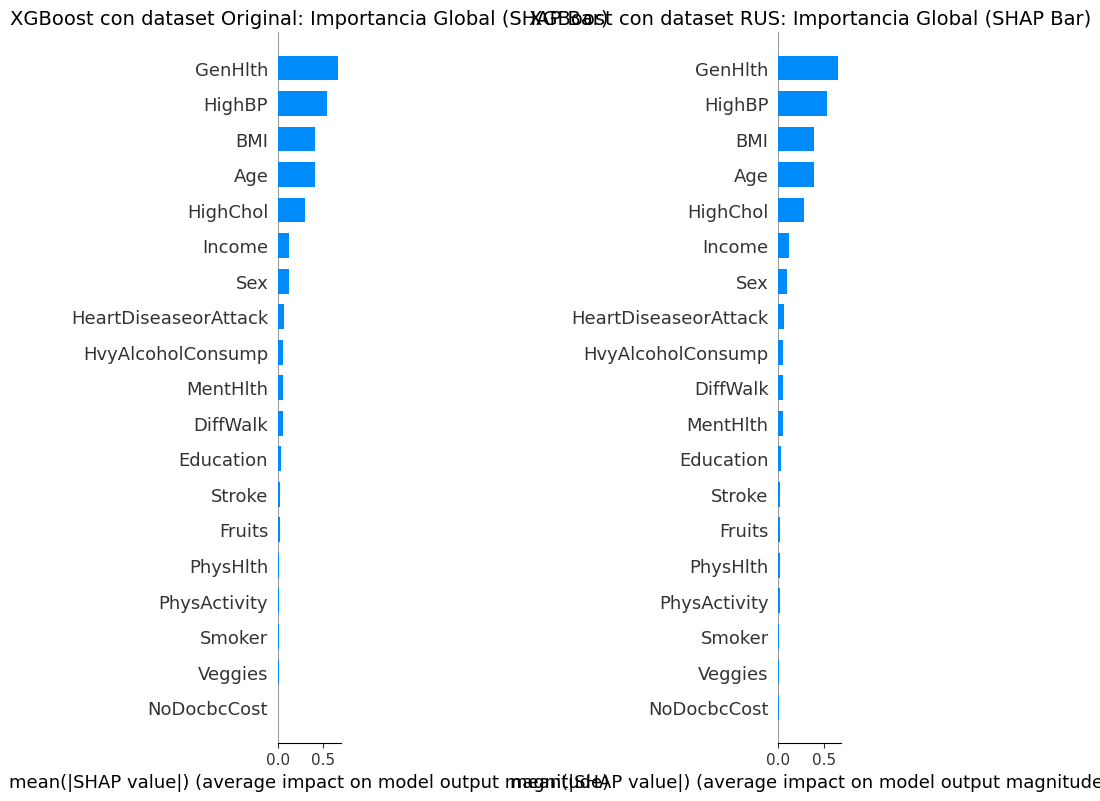

In [44]:
print("Calculando explicabilidad global con SHAP...")

# --- SHAP para XGBoost con original (Usa TreeExplainer) ---
explainer_xgb_original = shap.TreeExplainer(modelo_xgb_original)
# Definimos el tamaño del lote (ej: cada 10.000 filas)
batch_size = 10000
n_samples = len(X_test_procesado_ori)
all_shap_values = []

# Bucle con barra de progreso
# 'total' le dice a tqdm cuántas iteraciones esperar
for i in tqdm(range(0, n_samples, batch_size), desc="Calculando SHAP XGBoost con dataset original"):
    # Extraemos el lote actual
    batch = X_test_procesado_ori.iloc[i : i + batch_size]
    
    # Calculamos SHAP para este lote
    shap_batch = explainer_xgb_original.shap_values(batch, check_additivity=False)
    
    # Si el modelo es binario, LGBM devuelve una lista [clase0, clase1]
    # Guardamos solo la clase 1 (Diabetes) para ahorrar memoria
    if isinstance(shap_batch, list):
        all_shap_values.append(shap_batch[1])
    else:
        all_shap_values.append(shap_batch)

# Concatenamos todos los lotes en un solo array de Numpy
shap_values_xgb_ori = np.concatenate(all_shap_values, axis=0)

print(f"Matriz final de SHAP: {shap_values_xgb_ori.shape}")

# --- SHAP para XGBoost con RUS (Usa TreeExplainer) ---
explainer_xgb_rus = shap.TreeExplainer(modelo_xgb_rus)
# Definimos el tamaño del lote (ej: cada 10.000 filas)
batch_size = 10000
n_samples = len(X_test_procesado_rus)
all_shap_values = []

# Bucle con barra de progreso
# 'total' le dice a tqdm cuántas iteraciones esperar
for i in tqdm(range(0, n_samples, batch_size), desc="Calculando SHAP XGBoost con dataset RUS"):
    # Extraemos el lote actual
    batch = X_test_procesado_rus.iloc[i : i + batch_size]
    
    # Calculamos SHAP para este lote
    shap_batch = explainer_xgb_rus.shap_values(batch, check_additivity=False)
    
    # Si el modelo es binario, LGBM devuelve una lista [clase0, clase1]
    # Guardamos solo la clase 1 (Diabetes) para ahorrar memoria
    if isinstance(shap_batch, list):
        all_shap_values.append(shap_batch[1])
    else:
        all_shap_values.append(shap_batch)

# Concatenamos todos los lotes en un solo array de Numpy
shap_values_xgb_rus = np.concatenate(all_shap_values, axis=0)

print(f"Matriz final de SHAP: {shap_values_xgb_rus.shape}")


# --- VISUALIZACIÓN GLOBAL COMPARATIVA ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# LGBM Global
plt.sca(axes[0])
shap.summary_plot(shap_values_xgb_ori, X_test_procesado_ori, show=False, plot_type="bar")
axes[0].set_title("XGBoost con dataset Original: Importancia Global (SHAP Bar)", fontsize=14)

# Ridge Global
plt.sca(axes[1])
shap.summary_plot(shap_values_xgb_rus, X_test_procesado_rus, show=False, plot_type="bar")
axes[1].set_title("XGBoost con dataset RUS: Importancia Global (SHAP Bar)", fontsize=14)

plt.subplots_adjust(wspace=7, top=0.85)
plt.show()

#### CONCLUSIONES DE OTRO ENTRENAMIENTO!""""" COMPLETAR CON LOS DATOS DE LA NUEVA GRÁFICA

Las gráficas muestran que ambos modelos tienen el mismo top 5 de variables segçun importancia jerárquica, aunque la posición no sea exactamente igual. Este ranking nos explica que las variables predictoras con más peso son Salud General, Presión Arterias, Edad, BMI y Hipercolesterolemia, por lo que se puede indicar que el riesto de diabetes está impulstado mayormente por factores biológicos y de percepción de salud, con independencia del modelo elegido.
LGBM "amplifica" la importancia de las variables principales, llegando a 0.7, sugiriendo que el LGBM está capturando interacciones que hacen que el peso de una variable crezca exponencialmente en ciertos casos, mientras que Ridge, al ser lineal, reparte el peso de forma más conservadora entre ellas.

Factores como la alimentación (Fruits, Veggies) o el no acceso a una visita médica por temas económicos (NoDocbcCost) tienen un peso muy bajo en este dataset comparado con los marcadores biológicos, algo que indica que la diabetes en este grupo se predice por lo que el cuerpo ya manifiesta (tensión, peso, colesterol) más que por lo que el paciente declara comer.

Analizando posición 20 (ID real en dataset: 39980)
con XGBoost (Original)...
con XGBoost (RUS)...


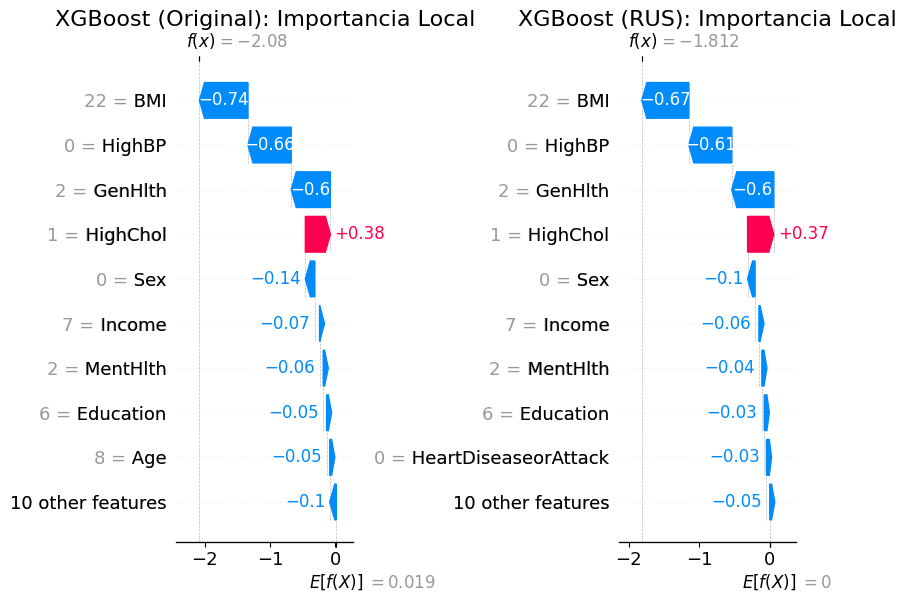

In [51]:
# Predicción local
# Al ahacer la prueba hemos visto que las etiquetas que devuelve en la eplicación local son con los valores transformados, por lo que tenemos que usar
# los valores reales del conjunto de test para que sea más fácilmente interpretable...
# COmo en el preprocesado hemos eliminado dos columnas, hay que tenerlo en cuenta a la hora de recuperar los valores reales del registro
posicion_encuestado = 20
columnas_preprocessor = X_test_procesado_ori.columns
posicion_real = X_test_procesado_ori.index[posicion_encuestado]
datos_reales_limpios = X_test.loc[posicion_real, columnas_preprocessor]
fig, axes = plt.subplots(1, 2, figsize=(50, 10))
plt.sca(axes[0])
print(f"Analizando posición {posicion_encuestado} (ID real en dataset: {posicion_real})")
print(f"con XGBoost (Original)...")
shap.plots.waterfall(shap.Explanation(values=shap_values_xgb_ori[posicion_encuestado], 
                                         base_values=explainer_xgb_original.expected_value, 
                                         data=datos_reales_limpios, 
                                         feature_names=columnas_preprocessor), show=False)
plt.title("XGBoost (Original): Importancia Local", fontsize=16, pad=25)
print(f"con XGBoost (RUS)...")
plt.sca(axes[1])
shap.plots.waterfall(shap.Explanation(values=shap_values_xgb_rus[posicion_encuestado], 
                                         base_values=explainer_xgb_rus.expected_value, 
                                         data=datos_reales_limpios, 
                                         feature_names=columnas_preprocessor), show=False)
plt.title("XGBoost (RUS): Importancia Local", fontsize=16, pad=25)
plt.subplots_adjust(wspace=1.5, top=0.85)
plt.show()

* Barras Rojas (Impacto Positivo): Características que aumentan la probabilidad de diabetes (ej: HighBP = 1, GenHlth = 3).
* Barras Azules (Impacto Negativo): Características que disminuyen la probabilidad de diabetes, actuando como factores protectores (ej: HvyAlcoholConsump = 1).
En esta comparativa podemos comfirmar como LGBM le da un peso más alto en general en la predicción a todas las variables en comparación con Ridge, lo que sugiere que LGMB puede estar infiriendo relaciones más complejas que las que detecta Ridge.

<Figure size 1200x800 with 0 Axes>

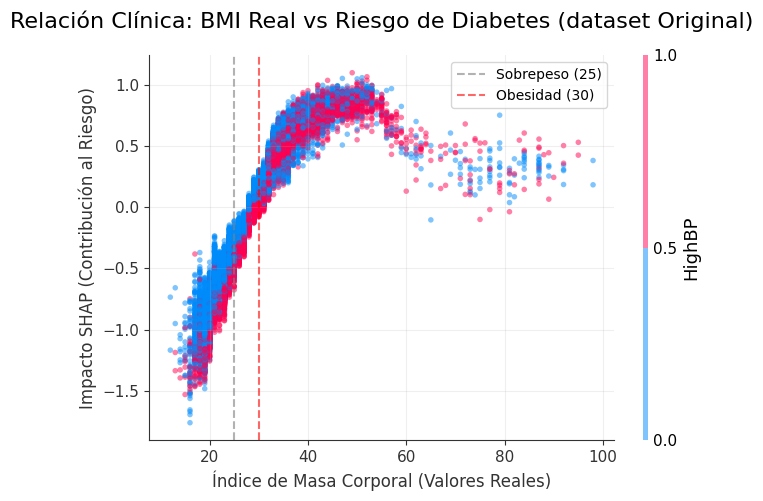

<Figure size 1200x800 with 0 Axes>

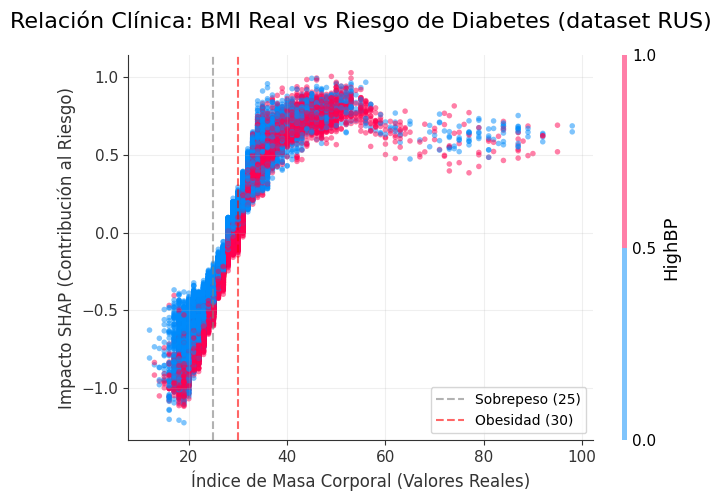

In [53]:
## GRAFICO DE SHAP que utiliza los valores de SHAP calculados para el modelo que se elija, en este caso es LGBM 
# porque fue el ganador de un entrenamiento anterior
## Con este gráfico lo que queremos es ver como el valor de BMI influye sobre el riesgo de diabetes, apoya además en otra variable que interactúe con BMI
# que vamos a dejar que el gráfico elija de forma automática.
# SHAP va a colorear los puntitos (de azul a rojo) basándose en otra variable que interactúe mucho con el BMI.
# Por ejemplo, si elije que la Edad combinada con el BMI es letal, pintará de rojo a los mayores y de azul a los jóvenes.
plt.figure(figsize=(12, 8))

# Generamos el dependence plot
# interaction_index='auto' hace que SHAP elija la variable que más interactúa con el BMI
# (Suele ser la Edad o la Presión Arterial)
# Le pasamos X_test filtrado solo por las columnas del X_te_procesado (recordamos que hemos eliminado dos en el preprocesado), pero con X_test
# tenemos los valores reales del cojunto de test, solo para las columnas que queremos.
X_test_real_plot = X_test[X_test_procesado_ori.columns]
shap.dependence_plot(
    "BMI", 
    shap_values_xgb_ori, 
    X_test_real_plot, 
    interaction_index="auto",  # Puede ponser "auto" o elegir una variable específica
    alpha=0.5,                 # Transparencia para ver mejor la densidad de 50k puntos
    show=False
)

# Añadimos líneas de referencia médica para que a simple vista en que nivel de IMC comienza el sobrepeso y en cuál la obesidad según la OMS:
#       Peso normal (Saludable): 18.5 a 24.9
#       Sobrepeso (Pre-obesidad): 25.0 a 29.9 
#       Obesidad: 30.0 o superior

plt.axvline(x=25, color='gray', linestyle='--', alpha=0.6, label='Sobrepeso (25)')
plt.axvline(x=30, color='red', linestyle='--', alpha=0.6, label='Obesidad (30)')

plt.title("Relación Clínica: BMI Real vs Riesgo de Diabetes (dataset Original)", fontsize=16, pad=20)
plt.xlabel("Índice de Masa Corporal (Valores Reales)", fontsize=12)
plt.ylabel("Impacto SHAP (Contribución al Riesgo)", fontsize=12)
plt.legend()
plt.grid(alpha=0.2)

plt.show()

plt.figure(figsize=(12, 8))

# Generamos el dependence plot
# interaction_index='auto' hace que SHAP elija la variable que más interactúa con el BMI
# (Suele ser la Edad o la Presión Arterial)
# Le pasamos X_test filtrado solo por las columnas del X_te_procesado (recordamos que hemos eliminado dos en el preprocesado), pero con X_test
# tenemos los valores reales del cojunto de test, solo para las columnas que queremos.
X_test_real_plot = X_test[X_test_procesado_rus.columns]
shap.dependence_plot(
    "BMI", 
    shap_values_xgb_rus, 
    X_test_real_plot, 
    interaction_index="auto",  # Puede ponser "auto" o elegir una variable específica
    alpha=0.5,                 # Transparencia para ver mejor la densidad de 50k puntos
    show=False
)

# Añadimos líneas de referencia médica para que a simple vista en que nivel de IMC comienza el sobrepeso y en cuál la obesidad según la OMS:
#       Peso normal (Saludable): 18.5 a 24.9
#       Sobrepeso (Pre-obesidad): 25.0 a 29.9 
#       Obesidad: 30.0 o superior

plt.axvline(x=25, color='gray', linestyle='--', alpha=0.6, label='Sobrepeso (25)')
plt.axvline(x=30, color='red', linestyle='--', alpha=0.6, label='Obesidad (30)')

plt.title("Relación Clínica: BMI Real vs Riesgo de Diabetes (dataset RUS)", fontsize=16, pad=20)
plt.xlabel("Índice de Masa Corporal (Valores Reales)", fontsize=12)
plt.ylabel("Impacto SHAP (Contribución al Riesgo)", fontsize=12)
plt.legend()
plt.grid(alpha=0.2)

plt.show()

SHAP ha decidido que la Presión Arterial Alta (HighBP) es la que tiene una interacción más fuerte con el Índice de Masa Corporal (BMI). Las conclusiones que podemos obtener de la gráfica son:

* BMI Por debajo de 25 (Peso normal): Todos los puntos que están a la izquiera de la linea gris, tienen un valor SHAP netativo, eje Y por debajo del 0. El modelo entiende perfectamente que tener un peso normal protege contra la diabetes (resta riesgo).
* BMI entre 25 y 30 (Sobrepeso): Justo al cruzar la línea gris de 25, la curva empieza a escalar drásticamente hacia arriba. El modelo detecta que el riesgo está creciendo rápidamente y el peso de los puntos comienza a ser positivo en algunos casos.
* BMI a partir de 30 (Obesidad): El impacto SHAP cruza la barrera del 0 y se vuelve positivo. A partir de aquí, el BMI empieza a sumar "puntos" de riesgo de forma agresiva, el modelo ha aprendido que la obesidad clínica es el punto de inflexión donde el peso pasa a ser un factor causante de la enfermedad. A partir de un BMI de 45-50, la curva se aplana ya que apenas se añade riesgo extra, lo que demuestra que a partir de cierto nivel de IMC, el daño metabólico ya está instaurado, y el riesgo ya es máximo.

A partir de un BMI de 50-60, la curva empieza a bajar un poco en lugar de seguir subiendo, y los puntos están mucho más dispersos. esto es debido a que en nuestro conjunto de test preprocesado no hay valores superiores a 60 por el clip que hicimos durante el preprocesamiento, pero en el conjunto de test original que es el que le hemos pasado a la gráfica de SHAP para que pinte los valores sin escalar en los ejes, si que los hay, por lo que a partir del valor 60, el impacto SHAP deja de crecer linealmente, ya que el modelo evalúa internamente a todos esos pacientes atípicos con el valor umbral máximo permitido (60), estabilizando su predicción de riesgo.

La interacción con HighBP en el reparto de los valores SHAP, si un paciente tiene Obesidad y además Presión Alta, el modelo le echa mucha culpa a la Presión Alta, pero si un paciente tiene Obesidad y no tiene Presión Alta (azul), el modelo infiere que toda la culpa del riesgo de diabetes se la lleva en exclusiva la obesidad de la persona, y por eso el punto azul sube más arriba en el eje Y.



<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id = "conclusion" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: #00b31bff; font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
           5. Creación pipeline producción
        </h3>
    </div>
</div>

Creamos un pipeline que inlcuya un paquete único entregable que pueda ser desplegado en un entorno productivo.
Antes de guardarlo, nos aseguramos de reentrenar el preprocesador y el modelo finalmente elegido con los datos del conjunto original para asegurar que no haya
interferencias derivadas de otras celdas ejecutadas durante todo el proceso realizado.

Una vez tengamos el pipeline definido y reentrenado, cuando haya que predecir el riesgo de una nueva persona, simplemente habrá que ejecutar:
pipeline_final.predict_proba(datos_nuevos)[:, 1]

donde "datos_nuevos" son los datos en crudo recogidos del formulario de la encuesta realizada que contiene un dataset con las variables que el modelo espera recibir, es decir, con la misma estructura de variables predictoras que tiene el dataset original.
Podríamos ejecutar predict() o predict_proba():
* predict(): nos devolvería un resultado binario: 0 (Sano) o 1 (Diabético).
* predict_proba(): nos devuelve la probabilidad de los datos de pertenecer a una clase un otra. El modelo generará un array con dos valores: [probabilidad_de_ser_0, probabilidad_de_ser_1], con [:, 1], extraemos solo la probabilidad de pertenecer a la clase positiva.

Tener un valor probabilístico, podría ayudar al personal sanitario a raelizar un triaje del paciente dependiendo de la probabilidad o no del riesgo diabético:
* Riesgo Bajo (0.0 - 0.3): el paciente tiene bajo riesgo de padecer diabetes.
* Riesgo Medio (0.3 - 0.7): el paciente parece tener factores de riesgo y debería tener un seguimiento preventivo por parte del facultativo.
* Riesgo Alto (0.7 - 1.0): el paciente tiene un alto riesgo de padecer diabetes y deberían realizarse las pruebas médicas necesarias para confirmar el diagnóstico.

Al final guardaremos el pipeline creado para poder utilizar el modelo paquetizado y listo para poder ser utilizado. Para cargarlo solo tendríamos que hacer:

modelo_DIRA = joblib.load('model/modelo_diabetes_DIRA.pkl')



Entrenando: XGBoost con dataset: Original (Desbalanceado)
Finalizado XGBoost | AP: 0.4361 | Train: 4m 0s | Pred: 0.1443s

Resumen de Average Precision (Validación Cruzada):
Dataset  Original (Desbalanceado)
Modelo                           
XGBoost                  0.436077

Generando matrices de confusión...


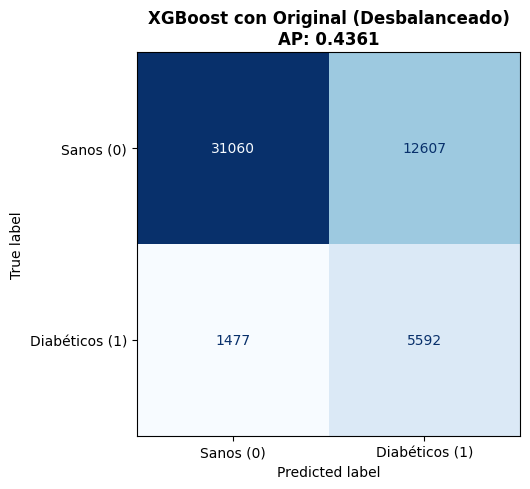

In [23]:
# Acabo de ver que he perdido todos las variables de la memoria, asi que solo entreno el modelo ganador de nuevo:
datasets_final = {
    "Original (Desbalanceado)": (X_train, y_train)
}
# Parametros para cada modelo
param_grids_final = {
    'XGBoost': {
        'model':  xgb.XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='logloss', objective="binary:logistic"),
        'params': {
            'n_estimators': randint(100, 401),
            'max_depth': randint(3, 9),
            'learning_rate': loguniform(0.01, 0.2),
            # uniform: Elige un decimal al azar en un rango lineal.
            'subsample': uniform(0.6, 0.4)      # uniform(loc, scale) -> de 0.6 a 1.0 (0.6 + 0.4)
        }
    }
}
# Validación cruzada estratificada con 5 folds (sobre el conjunto de entrenamiento)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Lista para almacenar los mejores modelos y sus métricas
mejores_modelos_resultados_final = []

for nombre_ds, (X_tr, y_tr) in datasets_final.items():
    # APLICAMOS PREPROCESSOR
    # Ajustamos el preprocesador al dataset de entrenamiento actual
    X_tr_procesado_final = preprocessor.fit_transform(X_tr)

    # aplicamos el transform del preprocesor al conjunto de test (usamos el X_test puro que separamos al principio)
    X_te_procesado_final = preprocessor.transform(X_test) 
    for nombre_modelo, config in param_grids_final.items():
        print(f"\n" + "="*50)
        print(f"\nEntrenando: {nombre_modelo} con dataset: {nombre_ds}")
        print("="*50)
        # Creamos el RandomizedSearchCV
        # 'n_iter=25' es un buen equilibrio entre tiempo y calidad
        # 'scoring' puede ser 'average_precision' o 'f1'
        randomSearch = RandomizedSearchCV(
            estimator=config['model'],
            param_distributions=config['params'],
            n_iter=25, 
            scoring='average_precision', 
            cv=cv,
            verbose=0,
            n_jobs=-1,
            random_state=random_state
        )
        if nombre_modelo == 'XGBoost' :
           # Calculamos el ratio de desbalanceo original
            ratio_peso = y_tr.value_counts()[0] / y_tr.value_counts()[1]    
            randomSearch.estimator.set_params(scale_pos_weight=ratio_peso)

        # vamos a calcular el tiempo que tarda en entrenar para tenerlo como una métrica de coste computacional
        inicio = time.time()
        # Ajustamos el modelo al dataset (X_tr_procesado, y_tr)
        randomSearch.fit(X_tr_procesado_final, y_tr)
        fin = time.time()
        training_time = fin - inicio   

        # Evaluamos al mejor modelo de cada algoritmo usando los datos de TEST que tenemos guardados
        mejor_modelo = randomSearch.best_estimator_

        # Extraemos los parámetros del modelo ganador para añdirle el ratio de peso usado en el caso de que se trate de XGBoost
        mejores_parametros = randomSearch.best_params_.copy()
        if nombre_modelo == 'XGBoost':
            # Sacamos el peso exacto que tiene el modelo final
            peso_usado = mejor_modelo.get_params().get('scale_pos_weight', 'No definido')
            mejores_parametros['scale_pos_weight (fijo)'] = peso_usado
        inicio = time.time()
        y_pred_best_model = mejor_modelo.predict(X_te_procesado_final)
        fin = time.time()
        predict_time = fin - inicio
        cm = confusion_matrix(y_test, y_pred_best_model)
        # Guardamos los resultados (incluyendo el ratio de peso para XGBoost)
        mejores_modelos_resultados_final.append({
            'Modelo': nombre_modelo,
            'Dataset': nombre_ds,
            'Mejor_Score_AP': randomSearch.best_score_,
            'Mejores_Params': mejores_parametros,
            'Estimator': randomSearch.best_estimator_,
            'ConfussionMatrix': cm,
            'Training_time': training_time,
            'predict_time': predict_time
        })
        training_minute = training_time // 60
        training_seconds = predict_time % 60
        print(f"Finalizado {nombre_modelo} | AP: {randomSearch.best_score_:.4f} | Train: {int(training_minute)}m {int(training_seconds)}s | Pred: {predict_time:.4f}s")
   

# Convertimos a DataFrame para comparar fácilmente
df_comparativa = pd.DataFrame(mejores_modelos_resultados_final).sort_values(by='Mejor_Score_AP', ascending=False)

tabla_resumen = df_comparativa.pivot(index='Modelo', columns='Dataset', values='Mejor_Score_AP')
print("\nResumen de Average Precision (Validación Cruzada):")
print(tabla_resumen.sort_values(by='Original (Desbalanceado)', ascending=False))

# Configuración del grid dinámica, depende del número de modelos, como hemos variado durante las pruebas,
# hemos visto como hacerlo dinámico con respecto a la lista de resultados.
# Obtenemos el tamaño de la lista de mejores modelos
n_modelos = len(mejores_modelos_resultados_final)
cols = 3  # Queremos 3 matrices por fila
rows = math.ceil(n_modelos / cols)  # Tantas filas como número de modelos entrenamos entre número de matrices por fila

# Definir la figura, le asignamos el alto a la figura de forma dinámica, dependiendo del número de filas que 
# necesitamos para pintar todas las cm de todos los modelos
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))    # 18 pulgadas de ancho y 5 pulgadas de altura por cada fila que vamos a pintar
axes = axes.flatten()  # Aplanamos para iterar con un solo índice [i]

print("\nGenerando matrices de confusión...")

# Bucle de dibujado
for i, res in enumerate(mejores_modelos_resultados_final):
    cm = res['ConfussionMatrix']
    nombre = res['Modelo']
    dataset = res['Dataset']
    ap_score = res['Mejor_Score_AP']
    
      
    # Dibujar en el subplot correspondiente
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=['Sanos (0)', 'Diabéticos (1)']
    )
    
    # Personalización del estilo
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"{nombre} con {dataset}\nAP: {ap_score:.4f}", fontsize=12, fontweight='bold')
    axes[i].grid(False) # Quitar líneas de grid sobre la matriz

# Limpieza: si sobran huecos en el grid, los borramos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar espaciado para que no se pisen los títulos
plt.tight_layout()
plt.show()

Hiperparámetros del mejor modelo: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': np.float64(0.020586445222604645), 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 363, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': np.float64(6.176998974431517), 'subsample': np.float64(0.6137554084460873), 'tree_method': None, 'validate_p

In [41]:
# Agrupamos en un único pipeline el preprocesor y el mejor modelo
# Usamos el objeto preprocesador que tenemos definido anteriormente
# y el modelo limpio que se ha creado con los mejores hiperparámetros obtenidos del RandomSearchCV, en este caso hemos elegido el XGboost entrenado 
# con el dataset original, porque tienen un mayor diversidad de muestras para encuestados sanos, lo que puede hacerlo más robusto en producción, y el coste
# computacional aunque es más alto que con un dataset tratado con RUS, es perfectamente asumible por un proceso en un entorno productivo que se reentrene de
# forma batch, que debería ser lo habitual.
# Obtenemos el mejor modelo y con sus  hiperparámetros creamos un modelo nuevo que pasaremos al pipeline final de procesado
modelo_xgb_original = next(res['Estimator'] for res in mejores_modelos_resultados_final
                   if res['Modelo'] == 'XGBoost' and res['Dataset'] == 'Original (Desbalanceado)')
mejores_hiperparametros = modelo_xgb_original.get_params()
print (f"Hiperparámetros del mejor modelo: {mejores_hiperparametros}")

# Definimos el modelo limpio con los hiperparámetros del modelo ganador
modelo_xgb_final = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.020586445222604645,
    max_depth=6,
    n_estimators=363,
    subsample=0.6137554084460873,
    scale_pos_weight=6.176998974431517,
    random_state=random_state,
    eval_metric='logloss',
    use_label_encoder=False
)

# Creamos el pipeline
pipeline_final_DIRA = make_pipeline(preprocessor, modelo_xgb_final)

# Nos aseguramos que el preprocessor y el modelo creado se entrenan con el dataset original:
pipeline_final_DIRA.fit(X_train, y_train)

# Predicimos sobre test para comprobar que todo va bien
y_probs_test = pipeline_final_DIRA.predict_proba(X_test)[:, 1]
ap_test = average_precision_score(y_test, y_probs_test)
print(f"Métricas del modelo de 6 segundos:")
print(f"Average Precision (AP): {ap_test:.4f}")

print("Pipeline para el sistema DIRA entrenado y sincronizado con el dataset Original.")

# Guardamos el objeto completo: Preprocesador + XGBoost
joblib.dump(pipeline_final_DIRA, 'model/modelo_diabetes_DIRA.pkl')

print("Pipeline guardado con éxito como 'modelo_diabetes_DIRA.pkl'")

Hiperparámetros del mejor modelo: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': np.float64(0.020586445222604645), 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 363, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': np.float64(6.176998974431517), 'subsample': np.float64(0.6137554084460873), 'tree_method': None, 'validate_p

Para comprobar el correcto funcionamiento de nuestro modelo, DIRA, vamos a crear dos pacientes ficticios con los datos que el modelo necesita para inferir el riesgo de diabetes de cada uno de ellos.
Como hemos comentado, el principal objetivo del sistema DIRA es el cribado poblacional, por lo que hemos diseñado un triaje basado en umbrales de probabilidad inferida por el modelo. El umbral inferior (0.30) se ha fijado para maximizar la sensibilidad, asegurando que los pacientes en estadios iniciales de riesgo entren en programas de seguimiento preventivo. Por otro lado, el umbral de alto riesgo (0.70) identifica a aquellos individuos con una combinación crítica de factores (BMI elevado, hipertensión y edad avanzada), permitiendo priorizar los recursos diagnósticos del hospital hacia quienes presentan una probabilidad de patología confirmada superior al 70%."

In [44]:

# Simulamos ahora la predicción de dos pacientes nuevos que contienen datos que el modelo no ha visto anteriormente
datos_pacientes = pd.DataFrame([
    {
        'HighBP': 1.0,              # Tiene presión alta
        'HighChol': 1.0,            # Tiene colesterol alto
        'CholCheck': 1.0,
        'BMI': 35.0,                # Obesidad (Clase II)
        'Smoker': 1.0,
        'Stroke': 0.0,
        'HeartDiseaseorAttack': 1.0,
        'PhysActivity': 0.0,        # No hace ejercicio
        'Fruits': 0.0,
        'Veggies': 1.0,
        'HvyAlcoholConsump': 1.0,   # Bebedor habitual
        'AnyHealthcare': 1.0,
        'NoDocbcCost': 0.0,
        'GenHlth': 4.0,             # Salud percibida: Mala
        'MentHlth': 10.0,
        'PhysHlth': 15.0,
        'DiffWalk': 1.0,            # Dificultad para caminar
        'Sex': 1.0,
        'Age': 9.0,                 # Rango de edad avanzado (e.g., 60-64 años)
        'Education': 4.0,
        'Income': 3.0
    },
    {
        'HighBP': 0.0,              # Presión normal
        'HighChol': 0.0,            # Colesterol normal
        'CholCheck': 1.0,
        'BMI': 22.0,                # Peso saludable
        'Smoker': 0.0,
        'Stroke': 0.0,
        'HeartDiseaseorAttack': 0.0,
        'PhysActivity': 1.0,        # Deportista
        'Fruits': 1.0,
        'Veggies': 1.0,
        'HvyAlcoholConsump': 1.0,   # Bebedor habitual
        'AnyHealthcare': 1.0,
        'NoDocbcCost': 0.0,
        'GenHlth': 1.0,             # Salud percibida: Excelente
        'MentHlth': 0.0,
        'PhysHlth': 0.0,
        'DiffWalk': 0.0,
        'Sex': 0.0,
        'Age': 3.0,                 # Joven (e.g., 30-34 años)
        'Education': 6.0,
        'Income': 8.0
    }
])

# Cargamos el pipeline del modelo que hemos guardado en la celda anterior
modelo_DIRA = joblib.load('model/modelo_diabetes_DIRA.pkl')

# Usar el Pipeline cargado para predecir
probabilidades = modelo_DIRA.predict_proba(datos_pacientes)[:, 1]

# Definimos los umbrales de riesgo:
umbral_sin_riesgo = 0.3
umbral_seguimiento = 0.7

# Mostramos el resultado de la predicción realizada
for i, p in enumerate(probabilidades):
    print(f"Paciente {i+1}: Probabilidad de riesgo de Diabetes = {p:.2%}")
    if p < umbral_sin_riesgo:
        nivel = "BAJO RIESGO (Verde)"
        accion = "Mantener hábitos saludables. Revisión preventiva en 2 años."
    elif 0.30 <= p < 0.70:
        nivel = "RIESGO MODERADO / SEGUIMIENTO (Amarillo)"
        accion = "Recomendación de seguimiento en 6 meses y recomendar plan de hábitos saludables."
    else:
        nivel = "ALTO RIESGO / PRIORITARIO (Rojo)"
        accion = "Derivación inmediata para pruebas diagnósticas de confirmación."
    
    print(f"Categoría: {nivel}")
    print(f"Acción sugerida: {accion}")
    print("-" * 35)

Paciente 1: Probabilidad de riesgo de Diabetes = 78.27%
Categoría: ALTO RIESGO / PRIORITARIO (Rojo)
Acción sugerida: Derivación inmediata para pruebas diagnósticas de confirmación.
-----------------------------------
Paciente 2: Probabilidad de riesgo de Diabetes = 1.49%
Categoría: BAJO RIESGO (Verde)
Acción sugerida: Mantener hábitos saludables. Revisión preventiva en 2 años.
-----------------------------------


In [58]:
# vamos a guardar el X_train original preprocesado para tenerlo de referencia por si lo perdemos de nuevo
X_train_preprocesado = preprocessor.transform(X_train)
df_procesado = pd.DataFrame(X_train_preprocesado)

# ñadimos la etiqueta (Diabetes_binary)
df_procesado['Diabetes_binary'] = y_train.values
df_procesado.to_csv('data/data_processed/dataset_original_preprocesado.csv', index=False)
print("Guardado: 'data/data_processed/dataset_original_preprocesado.csv'")

Guardado: 'data/data_processed/dataset_original_preprocesado.csv'


<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div id = "conclusion" style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: #00b31bff; font-size: 1em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1em; font-weight: bold">
           6. Conclusión final (DEL HITO 2) HAY QUE AÑADIR LO NUEVO DEL HITO 3
        </h3>
    </div>
</div>


Una de las primeras deciones tomadas, fue separar el dataset original en un conjunto de entrenamiento y test, estratificado por la variable objetivo, los que nos permite mantener la representación proporcional de las clases entre ambos conjuntos. El dataset de test no se ha tocado en ninguna de las fases del EDA o del preprocesado de los datos, garantizando de esta manera la ausencia de Data Leakage, que es la fuga de información. 

El trabajo desarrollado durante la fase de Analisis Exploratorio de Datos (EDA) y preprocesamiento nos ha permitido transforma el dataset original con una desbalanceo entre clases muy fuerte y con variables heterogéneas, en un conjunto balanceado y con variables en un rango escalar similar.

Se ha aplicado cada variable el escalado más conveniente, como ha sido el caso del escalado RobustScaler para BMI al haber observado en su gráfica una cantidad elevada de valores extremos, este escalado ha sido muy efectivo, centrando la distribución de los valores de esta variable en un rango de -3 y 3. Para el resto de variables ordinales sin valores extremos, se ha considerado aplicar un escalado estandard para que el peso de los valores estuviera en un rango similar.

Una vez obtenido el conjunto de entrenamiento preprocesado, se ha optado por aplicar distintas técnicas parar tratar el desbalanceo de las clases, obteniendo conjuntos de datos de cada una de ellas, que nos permitirán comparar en fases posteriores de este trabajo el comportamiento de los modelos que se decida utilizar y elegir el que mejor rendimiento produzca.

Dado el contexto médico del problema, en el que el coste de un Falso Negativo, es decir que no se diagnostique correctamente a un paciente realmente diábetico, es muy alto y que puede poner en peligro la vida de la persona, deberemos aplicar no solo **métricas** de precisión global como es el `Accuracy`, si no que deberemos optimizar métricas como:
* `Recall` (sensibilidad) asegurando que el Recall de la clase de los encuestados diabéticos sea lo más alto posible,
* `F1-Score` que es la media entre Precisión y Recall, 
* `AUC-ROC` (Área bajo la curva), que evalúa la capacidad del modelo para separar las dos clases con distintos umbrales de decisión y que nos permitirá comparar la probabilidad que asigna cada modelo a que la instancia pertenezca a una clase.
* `Matriz de Confusión` nos permitirá inspeccionar de forma visual las predicciones realizadas agrupadas por Falso Negativo, Falso Positivo, Verdadero Negativo y Verdadero Positivo, lo que nos ayudará a ver el número total de diagnósticos erroneos que se estén realizando.

Además de estas métricas y debido a que el sistema que se quiere desarrollar en esta práctica sería clasificado como de alto riesgo por la AI Act, se incluirán tecnicas de interpretabilidad y explicabilidad sobre el modelo como SHAP o LIME para facilitar la auditoría del mismo y que los usuarios del mismo puedan realizar la supervisión necesaria sobre las decisiones tomadas por el mismo, algo también clave en sistemas con esta clasificación de riesgo para la AI Act.

En la siguiente fase de esta práctica académica, podremos comparar distintos modelos lineales como Logistic Regression o SVM con kernel lineal, basados en instancias como K-Neighbors, probabilísticos como Naive Bayes y ensamblados de alto rendimiento como Random Forest, XGBoost o AdaBoost, en los que se utilizará para su evalución el conjunto de test original (claramente desbalanceado) como el juez final que evaluará la capacidad de generalización de cada uno de ellos.